# JAX DLGN With `take_datasets`

This notebook rewrites the DLGN training flow into a DLCA-style JAX setup while keeping the older difflogic dataset conventions:

- JAX logic-gate layers with soft, gumbel, or dirichlet gate decoding
- Flax-style immutable train state
- Optax optimizer updates
- difflogic-style `GroupSum` class head
- dataset names and loading branches aligned with the earlier PyTorch notebook

The default demo uses a tiny synthetic XOR dataset so the notebook is runnable even when the external datasets are not downloaded. To switch to the repo datasets, change `config['dataset']` in the training cell.


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
from typing import Literal
import importlib
import itertools
import math

import flax
import jax
import jax.numpy as jnp
import numpy as np
import optax

jax.clear_caches()
print('jax', jax.__version__)
print('flax', flax.__version__)
print('optax', optax.__version__)


jax 0.9.0.1
flax 0.12.4
optax 0.2.6


In [2]:
PASS_THROUGH_GATE = 3
DEFAULT_PASS_VALUE = 10.0
NUMBER_OF_GATES = 16
LIGHT_TRUTH_TABLE_SIZE = 4
TRUTH_TABLE_BIT_WEIGHTS = jnp.asarray([8, 4, 2, 1], dtype=jnp.int32)

GATE_NAMES = [
    'FALSE',
    'AND',
    'A_AND_NOT_B',
    'A',
    'NOT_A_AND_B',
    'B',
    'XOR',
    'OR',
    'NOR',
    'XNOR',
    'NOT_B',
    'A_OR_NOT_B',
    'NOT_A',
    'NOT_A_OR_B',
    'NAND',
    'TRUE',
]

LIGHT_TRUTH_TABLE_NAMES = ['00', '01', '10', '11']

ConnectionType = Literal['random', 'unique']
LogicFamily = Literal['full', 'light']
WirePair = tuple[jax.Array, jax.Array]


def get_unique_connections(in_dim: int, out_dim: int, key: jax.Array) -> WirePair:
    if out_dim * 2 < in_dim:
        raise ValueError(
            'unique connections require out_dim * 2 >= in_dim: '
            f'{out_dim=} {in_dim=}'
        )

    x = jnp.arange(in_dim)
    a = x[::2]
    b = x[1::2]
    m = min(a.shape[0], b.shape[0])
    a = a[:m]
    b = b[:m]

    if a.shape[0] < out_dim:
        a_ = x[1::2]
        b_ = x[2::2]
        m = min(a_.shape[0], b_.shape[0])
        a = jnp.concatenate([a, a_[:m]])
        b = jnp.concatenate([b, b_[:m]])

    offset = 2
    while out_dim > a.shape[0] and offset < in_dim:
        a = jnp.concatenate([a, x[:-offset]])
        b = jnp.concatenate([b, x[offset:]])
        offset += 1

    if a.shape[0] < out_dim:
        raise ValueError(
            f'Could not generate enough unique connections: {a.shape[0]} < {out_dim}'
        )

    a = a[:out_dim]
    b = b[:out_dim]
    perm = jax.random.permutation(key, out_dim)
    return a[perm], b[perm]


def logic_family_of_logits(logits: jax.Array) -> LogicFamily:
    if logits.shape[-1] == LIGHT_TRUTH_TABLE_SIZE:
        return 'light'
    if logits.shape[-1] == NUMBER_OF_GATES:
        return 'full'
    raise ValueError(f'Unsupported gate parameter size: {logits.shape[-1]}')


def truth_table_bits_to_gate_id(bits: jax.Array) -> jax.Array:
    bits = bits.astype(jnp.int32)
    return jnp.sum(bits * TRUTH_TABLE_BIT_WEIGHTS, axis=-1).astype(jnp.int32)


def hard_gate_ids_from_logits(logits: jax.Array) -> jax.Array:
    logic_family = logic_family_of_logits(logits)
    if logic_family == 'light':
        return truth_table_bits_to_gate_id(decode_light_hard(logits))
    return jnp.argmax(logits, axis=-1).astype(jnp.int32)


def bin_op_all_combinations(a: jax.Array, b: jax.Array) -> jax.Array:
    return jnp.stack(
        [
            jnp.zeros_like(a),
            a * b,
            a - a * b,
            a,
            b - a * b,
            b,
            a + b - 2 * a * b,
            a + b - a * b,
            1 - (a + b - a * b),
            1 - (a + b - 2 * a * b),
            1 - b,
            1 - b + a * b,
            1 - a,
            1 - a + a * b,
            1 - a * b,
            jnp.ones_like(a),
        ],
        axis=-1,
    )


def bin_op_s(a: jax.Array, b: jax.Array, gate_weights: jax.Array) -> jax.Array:
    return jnp.sum(bin_op_all_combinations(a, b) * gate_weights, axis=-1)


def light_truth_table_basis(a: jax.Array, b: jax.Array) -> jax.Array:
    return jnp.stack(
        [
            (1.0 - a) * (1.0 - b),
            (1.0 - a) * b,
            a * (1.0 - b),
            a * b,
        ],
        axis=-1,
    )


def bin_op_light(a: jax.Array, b: jax.Array, truth_table_weights: jax.Array) -> jax.Array:
    return jnp.sum(light_truth_table_basis(a, b) * truth_table_weights, axis=-1)




def decode_soft(logits: jax.Array) -> jax.Array:
    return jax.nn.softmax(logits, axis=-1)


def decode_gumbel_soft(
    logits: jax.Array,
    key: jax.Array,
    temperature: float = 1.0,
) -> jax.Array:
    temperature = jnp.maximum(temperature, 1e-6)
    noise = jax.random.gumbel(key, logits.shape)
    return jax.nn.softmax((logits + noise) / temperature, axis=-1)


def decode_gumbel_st(
    logits: jax.Array,
    key: jax.Array,
    temperature: float = 1.0,
) -> jax.Array:
    # PyTorch parity for full-gate gumbel: gumbel_softmax(..., hard=True).
    y_soft = decode_gumbel_soft(logits, key, temperature)
    y_hard = jax.nn.one_hot(jnp.argmax(y_soft, axis=-1), logits.shape[-1], dtype=y_soft.dtype)
    return y_soft + jax.lax.stop_gradient(y_hard - y_soft)


def decode_dirichlet_sample(
    logits: jax.Array,
    key: jax.Array,
    eps: float = 1e-6,
) -> jax.Array:
    # PyTorch parity for full-gate dirichlet: alpha = softplus(weights), then sample.
    alpha = jax.nn.softplus(logits) + eps
    return jax.random.dirichlet(key, alpha)

def decode_full_hard(logits: jax.Array) -> jax.Array:
    return jax.nn.one_hot(jnp.argmax(logits, axis=-1), logits.shape[-1])


def decode_light_soft(logits: jax.Array) -> jax.Array:
    return jax.nn.sigmoid(logits)


def decode_light_st(logits: jax.Array) -> jax.Array:
    truth_table_soft = decode_light_soft(logits)
    truth_table_hard = (truth_table_soft >= 0.5).astype(truth_table_soft.dtype)
    return truth_table_soft + jax.lax.stop_gradient(truth_table_hard - truth_table_soft)


def decode_light_hard(logits: jax.Array) -> jax.Array:
    return (decode_light_soft(logits) >= 0.5).astype(logits.dtype)


def init_full_gates(
    n: int,
    num_gates: int = NUMBER_OF_GATES,
    pass_through_gate: int = PASS_THROUGH_GATE,
    default_pass_value: float = DEFAULT_PASS_VALUE,
) -> jax.Array:
    gates = jnp.zeros((n, num_gates))
    return gates.at[:, pass_through_gate].set(default_pass_value)


def init_light_gates(
    n: int,
    default_pass_value: float = DEFAULT_PASS_VALUE,
) -> jax.Array:
    gates = jnp.full((n, LIGHT_TRUTH_TABLE_SIZE), -default_pass_value)
    return gates.at[:, 2:].set(default_pass_value)


def init_gate_layer(
    key: jax.Array,
    in_dim: int,
    out_dim: int,
    connection_type: ConnectionType,
    logic_family: LogicFamily,
) -> tuple[jax.Array, WirePair]:
    if connection_type == 'random':
        key1, key2 = jax.random.split(key)
        c = jax.random.permutation(key2, 2 * out_dim) % in_dim
        c = jax.random.permutation(key1, in_dim)[c]
        c = c.reshape(2, out_dim)
        wires = (c[0], c[1])
    elif connection_type == 'unique':
        wires = get_unique_connections(in_dim, out_dim, key)
    else:
        raise ValueError(f'Unknown connection type: {connection_type!r}')

    if logic_family == 'full':
        gate_params = init_full_gates(out_dim)
    elif logic_family == 'light':
        gate_params = init_light_gates(out_dim)
    else:
        raise ValueError(f'Unknown logic family: {logic_family!r}')

    return gate_params, wires


def build_layer_sizes(input_dim: int, num_neurons: int, num_layers: int) -> list[int]:
    if num_layers < 1:
        raise ValueError('num_layers must be at least 1')
    return [input_dim] + [num_neurons] * num_layers


def init_logic_gate_network(
    input_dim: int,
    num_neurons: int,
    num_layers: int,
    connections: ConnectionType,
    key: jax.Array,
    logic_family: LogicFamily,
) -> tuple[list[jax.Array], list[WirePair]]:
    layer_sizes = build_layer_sizes(input_dim, num_neurons, num_layers)
    params = []
    wires = []

    for in_dim, out_dim in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, subkey = jax.random.split(key)
        gate_logits, gate_wires = init_gate_layer(
            subkey,
            int(in_dim),
            int(out_dim),
            connections,
            logic_family,
        )
        params.append(gate_logits)
        wires.append(gate_wires)

    return params, wires




def decode_training_gates(
    logits: jax.Array,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    logic_family: LogicFamily,
) -> jax.Array:
    del dirichlet_concentration

    if logic_family == 'full':
        if architecture == 'softmax':
            return decode_soft(logits)
        if architecture == 'gumbel':
            return decode_gumbel_st(logits, key, gumb_tau)
        if architecture == 'dirichlet':
            return decode_dirichlet_sample(logits, key)
        raise ValueError(f'Unknown full-DLGN architecture: {architecture!r}')

    if logic_family == 'light':
        if architecture in ('light_sigmoid', 'sigmoid'):
            return decode_light_soft(logits)
        if architecture in ('light_st', 'light_sigmoid_st', 'sigmoid_st'):
            return decode_light_st(logits)
        raise ValueError(f'Unknown light-DLGN architecture: {architecture!r}')

    raise ValueError(f'Unknown logic family: {logic_family!r}')

def decode_hard(logits: jax.Array, logic_family: LogicFamily) -> jax.Array:
    if logic_family == 'full':
        return decode_full_hard(logits)
    if logic_family == 'light':
        return decode_light_hard(logits)
    raise ValueError(f'Unknown logic family: {logic_family!r}')


def run_layer(
    logits: jax.Array,
    wires: WirePair,
    x: jax.Array,
    training: bool,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    logic_family: LogicFamily,
) -> jax.Array:
    a = x[..., wires[0]]
    b = x[..., wires[1]]
    gate_weights = (
        decode_training_gates(
            logits,
            key,
            architecture,
            gumb_tau,
            dirichlet_concentration,
            logic_family,
        )
        if training
        else decode_hard(logits, logic_family)
    )

    if logic_family == 'full':
        return bin_op_s(a, b, gate_weights)
    if logic_family == 'light':
        return bin_op_light(a, b, gate_weights)
    raise ValueError(f'Unknown logic family: {logic_family!r}')


def run_logic_gate_network(
    params: list[jax.Array],
    wires: list[WirePair],
    x: jax.Array,
    training: bool,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    logic_family: LogicFamily,
) -> jax.Array:
    layer_keys = jax.random.split(key, len(params))
    for logits, layer_wires, layer_key in zip(params, wires, layer_keys):
        x = run_layer(
            logits,
            layer_wires,
            x,
            training,
            layer_key,
            architecture,
            gumb_tau,
            dirichlet_concentration,
            logic_family,
        )
    return x


def group_sum_head(x: jax.Array, class_count: int, sum_tau: float) -> jax.Array:
    if x.shape[-1] % class_count != 0:
        raise ValueError(
            'num_neurons must be divisible by class_count for GroupSum: '
            f'{x.shape[-1]=} {class_count=}'
        )
    group_size = x.shape[-1] // class_count
    x = x.reshape(x.shape[0], class_count, group_size)
    return x.sum(axis=-1) / jnp.maximum(sum_tau, 1e-6)


def forward_logits(
    params: list[jax.Array],
    wires: list[WirePair],
    x: jax.Array,
    training: bool,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    class_count: int,
    sum_tau: float,
    logic_family: LogicFamily,
) -> jax.Array:
    features = run_logic_gate_network(
        params,
        wires,
        x,
        training,
        key,
        architecture,
        gumb_tau,
        dirichlet_concentration,
        logic_family,
    )
    return group_sum_head(features, class_count, sum_tau)


In [3]:
def input_dim_of_dataset(dataset: str) -> int:
    return {
        'toy_xor': 2,
        'toy_parity': 6,
        'block': 16,
        'adult': 116,
        'breast_cancer': 51,
        'monk1': 17,
        'monk2': 17,
        'monk3': 17,
        'mnist': 784,
        'mnist20x20': 400,
        'mnist_bin': 784,
        'mnist20x20_bin': 400,
        'cifar-10-real-input': 3 * 32 * 32,
        'cifar-10-3-thresholds': 3 * 32 * 32 * 3,
        'cifar-10-31-thresholds': 3 * 32 * 32 * 31,
    }[dataset]


def num_classes_of_dataset(dataset: str) -> int:
    return {
        'toy_xor': 2,
        'toy_parity': 2,
        'block': 16,
        'adult': 2,
        'breast_cancer': 2,
        'monk1': 2,
        'monk2': 2,
        'monk3': 2,
        'mnist': 10,
        'mnist20x20': 10,
        'mnist_bin': 2,
        'mnist20x20_bin': 2,
        'cifar-10-real-input': 10,
        'cifar-10-3-thresholds': 10,
        'cifar-10-31-thresholds': 10,
    }[dataset]


class ArrayDataLoader:
    def __init__(
        self,
        x: np.ndarray,
        y: np.ndarray,
        batch_size: int,
        shuffle: bool = True,
        drop_last: bool = False,
        seed: int = 0,
    ):
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.rng = np.random.default_rng(seed)

    def __iter__(self):
        indices = np.arange(len(self.x))
        if self.shuffle:
            self.rng.shuffle(indices)
        step = self.batch_size
        stop = len(indices) if not self.drop_last else len(indices) - (len(indices) % step)
        for start in range(0, stop, step):
            batch_idx = indices[start:start + step]
            if len(batch_idx) < step and self.drop_last:
                continue
            yield self.x[batch_idx], self.y[batch_idx]

    def __len__(self):
        n = len(self.x)
        if self.drop_last:
            return n // self.batch_size
        return (n + self.batch_size - 1) // self.batch_size


def cycle_loader(loader):
    while True:
        for batch in loader:
            yield batch


def make_xor_arrays(repeats: int = 1024) -> tuple[np.ndarray, np.ndarray]:
    x = np.array(
        [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]],
        dtype=np.float32,
    )
    y = np.array([0, 1, 1, 0], dtype=np.int32)
    return np.tile(x, (repeats, 1)), np.tile(y, repeats)


def make_parity_arrays(
    num_samples: int,
    num_bits: int,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    x = rng.integers(0, 2, size=(num_samples, num_bits), dtype=np.int32).astype(np.float32)
    y = (x.sum(axis=-1) % 2).astype(np.int32)
    return x, y


def _require_module(module_name: str, package_hint: str | None = None):
    try:
        return importlib.import_module(module_name)
    except ModuleNotFoundError as exc:
        hint = '' if package_hint is None else f' Install or enable {package_hint} first.'
        raise ModuleNotFoundError(f'Could not import {module_name}.{hint}') from exc


def _make_torch_loaders_from_split(
    train_set,
    test_set,
    batch_size: int,
    valid_set_size: float,
    seed: int,
    num_workers: int,
):
    torch = _require_module('torch', 'torch')

    validation_loader = None
    if valid_set_size > 0:
        train_set_size = math.ceil((1 - valid_set_size) * len(train_set))
        valid_size = len(train_set) - train_set_size
        generator = torch.Generator().manual_seed(seed)
        train_set, validation_set = torch.utils.data.random_split(
            train_set,
            [train_set_size, valid_size],
            generator=generator,
        )
        validation_loader = torch.utils.data.DataLoader(
            validation_set,
            batch_size=batch_size,
            shuffle=False,
            pin_memory=True,
            drop_last=False,
            num_workers=num_workers,
        )

    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True,
        drop_last=True,
        num_workers=num_workers,
    )
    test_loader = torch.utils.data.DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True,
        drop_last=False,
        num_workers=num_workers,
    )
    return train_loader, validation_loader, test_loader


def load_dataset(config: dict):
    dataset = config['dataset']
    batch_size = config['batch_size']
    valid_set_size = config.get('valid_set_size', 0.0)
    seed = config['seed']
    num_workers = config.get('num_workers', 0)
    data_roots = config.get(
        'data_roots',
        {
            'block': './blocks_dataset',
            'uci': './data-uci',
            'mnist': './data-mnist',
            'cifar': './data-cifar',
        },
    )

    if dataset == 'toy_xor':
        train_x, train_y = make_xor_arrays(repeats=1024)
        test_x, test_y = make_xor_arrays(repeats=64)
        train_loader = ArrayDataLoader(train_x, train_y, batch_size=batch_size, shuffle=True, drop_last=True, seed=seed)
        test_loader = ArrayDataLoader(test_x, test_y, batch_size=batch_size, shuffle=False, drop_last=False, seed=seed + 1)
        return train_loader, None, test_loader

    if dataset == 'toy_parity':
        num_bits = config.get('toy_num_bits', 6)
        train_x, train_y = make_parity_arrays(num_samples=4096, num_bits=num_bits, seed=seed)
        test_x, test_y = make_parity_arrays(num_samples=1024, num_bits=num_bits, seed=seed + 1)
        train_loader = ArrayDataLoader(train_x, train_y, batch_size=batch_size, shuffle=True, drop_last=True, seed=seed)
        test_loader = ArrayDataLoader(test_x, test_y, batch_size=batch_size, shuffle=False, drop_last=False, seed=seed + 1)
        return train_loader, None, test_loader

    if dataset == 'block':
        block_datasets = _require_module('take_datasets.block_datasets', 'torch')
        train_set = block_datasets.BlocksDataset(data_roots['block'], split='train')
        test_set = block_datasets.BlocksDataset(data_roots['block'], split='test')
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset == 'adult':
        uci_datasets = _require_module('take_datasets.uci_datasets', 'torch and torchvision')
        train_set = uci_datasets.AdultDataset(data_roots['uci'], split='train', download=True, with_val=False)
        test_set = uci_datasets.AdultDataset(data_roots['uci'], split='test', with_val=False)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset == 'breast_cancer':
        uci_datasets = _require_module('take_datasets.uci_datasets', 'torch and torchvision')
        train_set = uci_datasets.BreastCancerDataset(data_roots['uci'], split='train', download=True, with_val=False)
        test_set = uci_datasets.BreastCancerDataset(data_roots['uci'], split='test', with_val=False)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset.startswith('monk'):
        uci_datasets = _require_module('take_datasets.uci_datasets', 'torch and torchvision')
        style = int(dataset[4])
        train_set = uci_datasets.MONKsDataset(data_roots['uci'], style, split='train', download=True, with_val=False)
        test_set = uci_datasets.MONKsDataset(data_roots['uci'], style, split='test', download=True, with_val=False)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset in ['mnist', 'mnist20x20']:
        mnist_dataset = _require_module('take_datasets.mnist_dataset', 'torchvision')
        remove_border = dataset == 'mnist20x20'
        train_set = mnist_dataset.MNIST(data_roots['mnist'], train=True, download=True, remove_border=remove_border)
        test_set = mnist_dataset.MNIST(data_roots['mnist'], train=False, download=True, remove_border=remove_border)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset in ['mnist_bin', 'mnist20x20_bin']:
        torch = _require_module('torch', 'torch')
        mnist_dataset = _require_module('take_datasets.mnist_dataset', 'torchvision')
        remove_border = dataset == 'mnist20x20_bin'
        train_set = mnist_dataset.MNIST(data_roots['mnist'], train=True, download=True, remove_border=remove_border)
        test_set = mnist_dataset.MNIST(data_roots['mnist'], train=False, download=True, remove_border=remove_border)

        keep = torch.tensor([0, 1])

        def keep_only(ds, keep_labels):
            mask = torch.isin(ds.targets, keep_labels)
            ds.data = ds.data[mask]
            ds.targets = ds.targets[mask]
            ds.classes = [ds.classes[k] for k in keep_labels.tolist()]
            return ds

        train_set = keep_only(train_set, keep)
        test_set = keep_only(test_set, keep)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset.startswith('cifar-10'):
        if dataset == 'cifar-10-real-input':
            raise ValueError('cifar-10-real-input is not supported in this notebook because the DLGN expects thresholded/binary-style inputs.')

        torchvision = _require_module('torchvision', 'torchvision')

        transform = {
            'cifar-10-3-thresholds': lambda x: np.concatenate([(x > (i + 1) / 4).astype(np.float32) for i in range(3)], axis=0),
            'cifar-10-31-thresholds': lambda x: np.concatenate([(x > (i + 1) / 32).astype(np.float32) for i in range(31)], axis=0),
        }[dataset]

        transforms = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Lambda(lambda x: transform(x.numpy())),
        ])
        train_set = torchvision.datasets.CIFAR10(data_roots['cifar'], train=True, download=True, transform=transforms)
        test_set = torchvision.datasets.CIFAR10(data_roots['cifar'], train=False, download=True, transform=transforms)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    raise NotImplementedError(f'The dataset {dataset!r} is not supported.')


def batch_to_jax(batch) -> tuple[jax.Array, jax.Array]:
    x, y = batch

    if hasattr(x, 'detach'):
        x = x.detach().cpu().numpy()
    else:
        x = np.asarray(x)

    if hasattr(y, 'detach'):
        y = y.detach().cpu().numpy()
    else:
        y = np.asarray(y)

    x = x.reshape(x.shape[0], -1).astype(np.float32)
    y = y.reshape(-1).astype(np.int32)
    return jnp.asarray(x), jnp.asarray(y)


In [4]:
@flax.struct.dataclass
class TrainState:
    params: list[jax.Array]
    opt_state: optax.OptState
    key: jax.Array


def validate_logic_config(config: dict) -> None:
    logic_family = config['logic_family']
    architecture = config['architecture']

    valid_architectures = {
        'full': {'softmax', 'gumbel', 'dirichlet'},
        'light': {'light_sigmoid', 'light_st', 'light_sigmoid_st', 'sigmoid', 'sigmoid_st'},
    }

    if logic_family not in valid_architectures:
        raise ValueError(f"Unknown logic_family: {logic_family!r}")
    if architecture not in valid_architectures[logic_family]:
        raise ValueError(
            f"architecture={architecture!r} is not valid for logic_family={logic_family!r}. "
            f"Expected one of {sorted(valid_architectures[logic_family])}."
        )


def create_optimizer(config: dict) -> optax.GradientTransformation:
    return optax.chain(
        optax.clip(config['clip_value']),
        optax.adamw(
            learning_rate=config['learning_rate'],
            b1=0.9,
            b2=0.99,
            weight_decay=config['weight_decay'],
        ),
    )


def loss_f(
    params: list[jax.Array],
    wires: list[WirePair],
    batch_x: jax.Array,
    batch_y: jax.Array,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    class_count: int,
    sum_tau: float,
    logic_family: LogicFamily,
) -> tuple[jax.Array, dict[str, jax.Array]]:
    logits_soft = forward_logits(
        params,
        wires,
        batch_x,
        True,
        key,
        architecture,
        gumb_tau,
        dirichlet_concentration,
        class_count,
        sum_tau,
        logic_family,
    )
    logits_hard = forward_logits(
        params,
        wires,
        batch_x,
        False,
        key,
        architecture,
        gumb_tau,
        dirichlet_concentration,
        class_count,
        sum_tau,
        logic_family,
    )
    soft_loss = optax.softmax_cross_entropy_with_integer_labels(logits_soft, batch_y).mean()
    hard_loss = optax.softmax_cross_entropy_with_integer_labels(logits_hard, batch_y).mean()
    return soft_loss, {'hard': hard_loss}


def make_train_step(tx: optax.GradientTransformation):
    @partial(jax.jit, static_argnames=('architecture', 'class_count', 'logic_family'))
    def train_step(
        state: TrainState,
        batch_x: jax.Array,
        batch_y: jax.Array,
        wires: list[WirePair],
        architecture: str,
        gumb_tau: float,
        dirichlet_concentration: float,
        class_count: int,
        sum_tau: float,
        logic_family: LogicFamily,
    ) -> tuple[TrainState, jax.Array, dict[str, jax.Array]]:
        key, subkey = jax.random.split(state.key)

        def apply_loss(params):
            return loss_f(
                params,
                wires,
                batch_x,
                batch_y,
                subkey,
                architecture,
                gumb_tau,
                dirichlet_concentration,
                class_count,
                sum_tau,
                logic_family,
            )

        (loss, aux), grads = jax.value_and_grad(apply_loss, has_aux=True)(state.params)
        updates, opt_state = tx.update(grads, state.opt_state, state.params)
        params = optax.apply_updates(state.params, updates)
        state = state.replace(params=params, opt_state=opt_state, key=key)
        return state, loss, aux

    return train_step


@partial(jax.jit, static_argnames=('architecture', 'class_count', 'logic_family'))
def eval_batch(
    params: list[jax.Array],
    wires: list[WirePair],
    batch_x: jax.Array,
    batch_y: jax.Array,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    class_count: int,
    sum_tau: float,
    logic_family: LogicFamily,
) -> dict[str, jax.Array]:
    logits_soft = forward_logits(
        params,
        wires,
        batch_x,
        True,
        key,
        architecture,
        gumb_tau,
        dirichlet_concentration,
        class_count,
        sum_tau,
        logic_family,
    )
    logits_hard = forward_logits(
        params,
        wires,
        batch_x,
        False,
        key,
        architecture,
        gumb_tau,
        dirichlet_concentration,
        class_count,
        sum_tau,
        logic_family,
    )
    return {
        'soft_loss_sum': optax.softmax_cross_entropy_with_integer_labels(logits_soft, batch_y).sum(),
        'hard_loss_sum': optax.softmax_cross_entropy_with_integer_labels(logits_hard, batch_y).sum(),
        'soft_correct': (jnp.argmax(logits_soft, axis=-1) == batch_y).sum(),
        'hard_correct': (jnp.argmax(logits_hard, axis=-1) == batch_y).sum(),
        'count': batch_y.shape[0],
    }


def evaluate_loader(
    params: list[jax.Array],
    wires: list[WirePair],
    loader,
    config: dict,
    class_count: int,
) -> dict[str, float] | None:
    if loader is None:
        return None

    totals = {
        'soft_loss_sum': 0.0,
        'hard_loss_sum': 0.0,
        'soft_correct': 0.0,
        'hard_correct': 0.0,
        'count': 0.0,
    }

    for batch_index, batch in enumerate(loader):
        batch_x, batch_y = batch_to_jax(batch)
        metrics = eval_batch(
            params,
            wires,
            batch_x,
            batch_y,
            jax.random.PRNGKey(config['seed'] + 50_000 + batch_index),
            config['architecture'],
            config['gumb_tau'],
            config['dirichlet_concentration'],
            class_count,
            config['sum_tau'],
            config['logic_family'],
        )
        for key, value in metrics.items():
            totals[key] += float(value)

    count = max(totals['count'], 1.0)
    return {
        'soft_loss': totals['soft_loss_sum'] / count,
        'hard_loss': totals['hard_loss_sum'] / count,
        'soft_acc': totals['soft_correct'] / count,
        'hard_acc': totals['hard_correct'] / count,
    }


def _empty_history() -> dict[str, list]:
    return {
        'steps': [],
        'train_soft_loss': [],
        'train_hard_loss': [],
        'valid_hard_acc': [],
        'test_hard_acc': [],
    }


def train_model(
    config: dict,
    initial_state: TrainState | None = None,
    initial_wires: list[WirePair] | None = None,
    history: dict | None = None,
    start_step: int | None = None,
):
    validate_logic_config(config)
    train_loader, validation_loader, test_loader = load_dataset(config)
    input_dim = input_dim_of_dataset(config['dataset'])
    class_count = num_classes_of_dataset(config['dataset'])

    if config['num_neurons'] % class_count != 0:
        raise ValueError(
            'num_neurons must be divisible by the number of classes for GroupSum: '
            f"{config['num_neurons']=} {class_count=}"
        )

    tx = create_optimizer(config)
    train_step = make_train_step(tx)

    if initial_state is None:
        key = jax.random.PRNGKey(config['seed'])
        key, init_key = jax.random.split(key)
        params, wires = init_logic_gate_network(
            input_dim=input_dim,
            num_neurons=config['num_neurons'],
            num_layers=config['num_layers'],
            connections=config['connections'],
            key=init_key,
            logic_family=config['logic_family'],
        )
        state = TrainState(params=params, opt_state=tx.init(params), key=key)
    else:
        if initial_wires is None:
            raise ValueError('initial_wires must be provided when resuming from an existing state')
        state = initial_state
        wires = initial_wires

    if history is None:
        history = _empty_history()
    else:
        history = {k: list(v) for k, v in history.items()}
        for key in _empty_history():
            history.setdefault(key, [])

    if start_step is None:
        start_step = 0 if not history['steps'] else int(history['steps'][-1]) + 1

    loader_iter = cycle_loader(train_loader)
    for step in range(start_step, config['num_steps']):
        batch = next(loader_iter)
        batch_x, batch_y = batch_to_jax(batch)
        state, soft_loss, aux = train_step(
            state,
            batch_x,
            batch_y,
            wires,
            config['architecture'],
            config['gumb_tau'],
            config['dirichlet_concentration'],
            class_count,
            config['sum_tau'],
            config['logic_family'],
        )

        history['steps'].append(step)
        history['train_soft_loss'].append(float(soft_loss))
        history['train_hard_loss'].append(float(aux['hard']))

        should_eval = step % config['eval_every'] == 0 or step == config['num_steps'] - 1
        if should_eval:
            valid_metrics = evaluate_loader(state.params, wires, validation_loader, config, class_count)
            test_metrics = evaluate_loader(state.params, wires, test_loader, config, class_count)

            history['valid_hard_acc'].append(None if valid_metrics is None else valid_metrics['hard_acc'])
            history['test_hard_acc'].append(None if test_metrics is None else test_metrics['hard_acc'])

            valid_msg = 'n/a' if valid_metrics is None else f"{valid_metrics['hard_acc']:.4f}"
            test_msg = 'n/a' if test_metrics is None else f"{test_metrics['hard_acc']:.4f}"
            print(
                f'step={step:05d} '
                f'soft_loss={float(soft_loss):.6f} '
                f'hard_loss={float(aux["hard"]):.6f} '
                f'valid_hard_acc={valid_msg} '
                f'test_hard_acc={test_msg}'
            )

    dataset_info = {
        'dataset': config['dataset'],
        'input_dim': input_dim,
        'class_count': class_count,
        'logic_family': config['logic_family'],
    }
    return state, wires, history, dataset_info, validation_loader, test_loader


def gate_usage_summary(params: list[jax.Array]) -> list[tuple[str, int]]:
    gate_ids = jnp.concatenate([hard_gate_ids_from_logits(layer).reshape(-1) for layer in params])
    counts = jnp.bincount(gate_ids, length=NUMBER_OF_GATES)
    return [(GATE_NAMES[i], int(counts[i])) for i in range(NUMBER_OF_GATES) if int(counts[i]) > 0]


def print_gate_usage(params: list[jax.Array]) -> None:
    print('Gate usage after hard decoding:')
    for gate_name, count in gate_usage_summary(params):
        print(f'  {gate_name:>14}: {count}')


In [5]:
import pickle


def logic_argmax_row(layer_logits: jax.Array) -> np.ndarray:
    return np.asarray(jax.device_get(hard_gate_ids_from_logits(layer_logits)), dtype=np.int32)


def show_logiclayer_info(
    layer,
    wires: WirePair | None = None,
    n: int | None = None,
    topk: int = 1,
    layer_name: str | None = None,
):
    if wires is None:
        if not isinstance(layer, (tuple, list)) or len(layer) != 2:
            raise ValueError('Pass either (layer_logits, layer_wires) as a tuple or supply wires explicitly')
        layer_logits, layer_wires = layer
    else:
        layer_logits, layer_wires = layer, wires

    W = np.asarray(jax.device_get(layer_logits))
    out_dim = W.shape[0]
    rows = out_dim if n is None else min(n, out_dim)
    prefix = '' if layer_name is None else f'{layer_name} '

    a_idx = np.asarray(jax.device_get(layer_wires[0]))
    b_idx = np.asarray(jax.device_get(layer_wires[1]))

    if logic_family_of_logits(layer_logits) == 'light':
        soft_table = np.asarray(jax.device_get(decode_light_soft(layer_logits)))
        hard_table = np.asarray(jax.device_get(decode_light_hard(layer_logits))).astype(np.int32)
        gate_ids = np.asarray(jax.device_get(hard_gate_ids_from_logits(layer_logits))).astype(np.int32)
        vals, counts = np.unique(gate_ids, return_counts=True)
        print(f"{prefix}op histogram:", ' '.join(f"{GATE_NAMES[int(v)]}:{int(c)}" for v, c in zip(vals, counts)))

        for i in range(rows):
            pair_str = f' pair=({int(a_idx[i])},{int(b_idx[i])})'
            gate_id = int(gate_ids[i])
            print(
                f'  neuron {i:3d}:{pair_str} '
                f'gate={gate_id}:{GATE_NAMES[gate_id]} '
                f'truth_table={hard_table[i].tolist()} '
                f'probs={[float(x) for x in soft_table[i].tolist()]}'
            )
        return

    topk = max(1, min(topk, W.shape[1]))
    topi = np.argsort(W, axis=1)[:, -topk:][:, ::-1]
    topv = np.take_along_axis(W, topi, axis=1)

    vals, counts = np.unique(W.argmax(axis=1), return_counts=True)
    print(f"{prefix}op histogram:", ' '.join(f"{int(v)}:{int(c)}" for v, c in zip(vals, counts)))

    for i in range(rows):
        pair_str = f' pair=({int(a_idx[i])},{int(b_idx[i])})'
        print(
            f'  neuron {i:3d}:{pair_str} '
            f'ops={topi[i].tolist()} '
            f'logits={[float(x) for x in topv[i].tolist()]}'
        )


def plot_hist_gates(net, save_path=None, title='Distribution of Gates (Sorted)'):
    try:
        import matplotlib.pyplot as plt
        from matplotlib.ticker import MaxNLocator
    except Exception as exc:
        raise RuntimeError('matplotlib is required for plotting gate histograms') from exc

    gate_types = [
        'FALSE',
        'AND',
        'A AND (NOT B)',
        'A',
        '(NOT A) AND B',
        'B',
        'XOR',
        'OR',
        'NOR',
        'XNOR',
        'NOT B',
        'A OR (NOT B)',
        'NOT A',
        '(NOT A) OR B',
        'NAND',
        'TRUE',
    ]

    net = np.asarray(net).reshape(-1)
    gate_counts = np.bincount(net, minlength=len(gate_types))
    sorted_indices = np.argsort(gate_counts)
    sorted_counts = gate_counts[sorted_indices]
    sorted_gate_types = [gate_types[i] for i in sorted_indices]

    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
    ax.barh(
        sorted_gate_types,
        sorted_counts,
        alpha=0.7,
        edgecolor='white',
        linewidth=1,
    )

    ax.set_xlabel('# Gates', fontsize=12, fontweight='bold')
    ax.set_ylabel('Type of gate', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, linestyle='--', alpha=0.7, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_facecolor('#f8f9fa')
    fig.set_facecolor('white')
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        plt.savefig(save_path)
        print(f'Saved histogram to {save_path.resolve()}')
        plt.close(fig)
    else:
        plt.show()


def plot_training_progress(loss_train, loss_test, compute_every, save_path=None, title='Training Progress - Soft vs Hard Gates'):
    try:
        import matplotlib.pyplot as plt
    except Exception as exc:
        raise RuntimeError('matplotlib is required for plotting training curves') from exc

    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    ax.grid(True, linestyle='--', alpha=0.7)

    ax.plot(loss_train, linewidth=2, label='Soft Gates Loss', alpha=0.9)

    test_x = np.arange(0, compute_every * len(loss_test), compute_every)
    ax.plot(
        test_x,
        loss_test,
        linestyle='--',
        linewidth=2,
        label='Hard Gates Loss',
        alpha=0.9,
    )

    ax.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right')
    plt.tight_layout()

    if save_path:
        save_path = Path(save_path)
        plt.savefig(save_path)
        print(f'Saved training curve to {save_path.resolve()}')
        plt.close(fig)
    else:
        plt.show()


def gate_analysis(
    train_state: TrainState,
    wires: list[WirePair],
    name: str = 'model',
    topk: int = 1,
    exclude_passthrough: bool = False,
):
    params = train_state.params
    all_gate_ids = []

    for layer_idx, (layer_logits, layer_wires) in enumerate(zip(params, wires)):
        gate_ids = logic_argmax_row(layer_logits)
        all_gate_ids.append(gate_ids)

        show_logiclayer_info(
            layer_logits,
            layer_wires,
            topk=topk,
            layer_name=f'layer {layer_idx}',
        )

        plot_ids = gate_ids
        if exclude_passthrough:
            plot_ids = plot_ids[(plot_ids != 3) & (plot_ids != 5)]

        if plot_ids.size > 0:
            save_path = None if not name else f'{name}_layer_{layer_idx}_gates.svg'
            plot_hist_gates(
                plot_ids,
                save_path=save_path,
                title=f'{name} Layer {layer_idx} Gate Distribution',
            )

    flat_gates = np.concatenate(all_gate_ids, axis=0)
    if exclude_passthrough:
        flat_gates = flat_gates[(flat_gates != 3) & (flat_gates != 5)]

    if flat_gates.size > 0:
        save_path = None if not name else f'{name}_all_gates.svg'
        plot_hist_gates(flat_gates, save_path=save_path, title=f'{name} All Layers Gate Distribution')




def stochastic_decoder_diagnostics(
    logits: jax.Array | None = None,
    key: jax.Array | None = None,
    gumbel_tau: float = 1.0,
):
    if logits is None:
        logits = jnp.asarray(
            np.tile(np.linspace(-1.5, 1.5, NUMBER_OF_GATES, dtype=np.float32), (2, 1))
        )
    else:
        logits = jnp.asarray(logits, dtype=jnp.float32)

    if logits.ndim == 1:
        logits = logits[None, :]
    if logits.shape[-1] != NUMBER_OF_GATES:
        raise ValueError(
            f'Expected logits.shape[-1] == {NUMBER_OF_GATES}, got {logits.shape[-1]}'
        )

    if key is None:
        key = jax.random.PRNGKey(0)
    gumbel_key, dirichlet_key = jax.random.split(key)

    softmax_weights = decode_soft(logits)
    gumbel_weights = decode_gumbel_st(logits, gumbel_key, gumbel_tau)
    dirichlet_alpha = jax.nn.softplus(logits) + 1e-6
    dirichlet_weights = decode_dirichlet_sample(logits, dirichlet_key)

    gumbel_grad = jax.grad(
        lambda z: decode_gumbel_st(z, gumbel_key, gumbel_tau)[0, 0]
    )(logits)

    return {
        'softmax_weights': softmax_weights,
        'softmax_row_sums': softmax_weights.sum(axis=-1),
        'gumbel_forward_weights': gumbel_weights,
        'gumbel_row_sums': gumbel_weights.sum(axis=-1),
        'gumbel_forward_is_one_hot': jnp.all(
            ((gumbel_weights == 0.0) | (gumbel_weights == 1.0)), axis=-1
        ) & jnp.isclose(gumbel_weights.sum(axis=-1), 1.0),
        'gumbel_backward_grad': gumbel_grad,
        'gumbel_backward_has_soft_grad': jnp.any(jnp.abs(gumbel_grad) > 1e-8),
        'dirichlet_alpha': dirichlet_alpha,
        'dirichlet_weights': dirichlet_weights,
        'dirichlet_row_sums': dirichlet_weights.sum(axis=-1),
    }

def _tree_to_numpy(tree):
    return jax.tree_util.tree_map(
        lambda x: None if x is None else np.asarray(jax.device_get(x)),
        tree,
    )


def _tree_to_jax(tree):
    return jax.tree_util.tree_map(
        lambda x: None if x is None else jnp.asarray(x),
        tree,
    )


def save_checkpoint(
    path,
    state: TrainState,
    wires: list[WirePair],
    config: dict,
    history: dict | None = None,
    dataset_info: dict | None = None,
    step: int | None = None,
    extra: dict | None = None,
):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if step is None:
        if history is not None and history.get('steps'):
            step = int(history['steps'][-1])
        else:
            step = 0

    payload = {
        'step': step,
        'params': _tree_to_numpy(state.params),
        'opt_state': _tree_to_numpy(state.opt_state),
        'key': np.asarray(jax.device_get(state.key)),
        'wires': _tree_to_numpy(wires),
        'config': config,
        'history': history,
        'dataset_info': dataset_info,
        'extra': {} if extra is None else extra,
    }

    with path.open('wb') as f:
        pickle.dump(payload, f)

    print(f'Saved checkpoint to {path.resolve()}')


def load_checkpoint(path):
    path = Path(path)
    with path.open('rb') as f:
        payload = pickle.load(f)

    state = TrainState(
        params=_tree_to_jax(payload['params']),
        opt_state=_tree_to_jax(payload['opt_state']),
        key=jnp.asarray(payload['key']),
    )
    wires = _tree_to_jax(payload['wires'])

    payload['state'] = state
    payload['wires'] = wires
    return payload


def resume_training_from_checkpoint(path, config_override: dict | None = None):
    checkpoint = load_checkpoint(path)
    merged_config = dict(checkpoint['config'])
    if config_override is not None:
        merged_config.update(config_override)

    return train_model(
        merged_config,
        initial_state=checkpoint['state'],
        initial_wires=checkpoint['wires'],
        history=checkpoint.get('history'),
        start_step=int(checkpoint.get('step', -1)) + 1,
    )


## Demo Configuration

The default config uses `toy_xor` so the notebook stays runnable in a clean environment. To train on the repo datasets instead, swap `config['dataset']` to one of:

- `block`
- `adult`
- `breast_cancer`
- `monk1`, `monk2`, `monk3`
- `mnist`, `mnist20x20`
- `mnist_bin`, `mnist20x20_bin`
- `cifar-10-3-thresholds`, `cifar-10-31-thresholds`

For real datasets you will also need the matching Torch or torchvision dependencies plus local dataset directories or download access.


## Full vs Light DLGN

- Use `logic_family = "full"` when you want the original 16-gate DLGN. Each neuron learns a distribution over the full Boolean gate set, so this is the more expressive option and matches the standard differentiable logic-gate setup.
- Use `logic_family = "light"` when you want the lighter 4-entry truth-table parameterization. Each neuron learns the outputs for `00`, `01`, `10`, and `11` directly, which is cheaper and closer to the ETH light / input-wise parameterization style.
- For light DLGN training, `architecture = "light_st"` is usually the best default because it trains with straight-through hard thresholding and gives much better hard-gate behavior than plain `light_sigmoid`.
- For full DLGN training, keep using `softmax`, `gumbel`, or `dirichlet` depending on how much stochasticity you want in gate selection.
- A practical rule of thumb: start with `full` if you care most about expressivity or exact gate-type analysis, and start with `light` if you care most about a compact, fast logic parameterization.


In [6]:
config = {
    'dataset': 'toy_xor',
    'seed': 0,
    'batch_size': 128,
    'valid_set_size': 0.1,
    'num_workers': 0,
    'num_steps': 1200,
    'eval_every': 100,
    'learning_rate': 0.03,
    'weight_decay': 1e-4,
    'clip_value': 100.0,
    'connections': 'random',
    'logic_family': 'full',  # 'full' or 'light'
    'architecture': 'softmax',  # full: plain softmax / gumbel ST / dirichlet(softplus(logits)); light: 'light_st' (recommended) or 'light_sigmoid'
    'gumb_tau': 1.0,
    'dirichlet_concentration': 12.0,
    'sum_tau': 10.0,
    'num_neurons': 8,
    'num_layers': 3,
    'toy_num_bits': 6,
    'data_roots': {
        'block': './blocks_dataset',
        'uci': './data-uci',
        'mnist': './data-mnist',
        'cifar': './data-cifar',
    },
}
jax.clear_caches()
# Example real-dataset settings:
config.update({
    'dataset': 'cifar-10-3-thresholds',
    'batch_size': 1024,
    'num_steps': 1000,
    'num_neurons': 19500, #9216
    'num_layers': 16,
    'connections': 'random',
})

# Example light-DLGN settings:
# config.update({
#     'logic_family': 'light',
#     'architecture': 'light_st',
#     'num_neurons': 16,
#     'num_layers': 3,
# })

state, wires, history, dataset_info, validation_loader, test_loader = train_model(config)
print(dataset_info)
jax.clear_caches()

step=00000 soft_loss=4.019442 hard_loss=4.051745 valid_hard_acc=0.0910 test_hard_acc=0.0868
step=00100 soft_loss=2.068773 hard_loss=3.845893 valid_hard_acc=0.0910 test_hard_acc=0.0868
step=00200 soft_loss=1.625973 hard_loss=3.442911 valid_hard_acc=0.1324 test_hard_acc=0.1340
step=00300 soft_loss=1.539814 hard_loss=2.769665 valid_hard_acc=0.2090 test_hard_acc=0.2003
step=00400 soft_loss=1.288224 hard_loss=2.359855 valid_hard_acc=0.2706 test_hard_acc=0.2618
step=00500 soft_loss=1.308352 hard_loss=2.092775 valid_hard_acc=0.3088 test_hard_acc=0.3023
step=00600 soft_loss=1.281916 hard_loss=2.052836 valid_hard_acc=0.3360 test_hard_acc=0.3368
step=00700 soft_loss=1.071500 hard_loss=1.737043 valid_hard_acc=0.3428 test_hard_acc=0.3508
step=00800 soft_loss=1.127577 hard_loss=1.765783 valid_hard_acc=0.3674 test_hard_acc=0.3662
step=00900 soft_loss=1.076449 hard_loss=1.587543 valid_hard_acc=0.3840 test_hard_acc=0.3913
step=00999 soft_loss=0.976448 hard_loss=1.424492 valid_hard_acc=0.3924 test_hard

In [7]:
test_metrics = evaluate_loader(
    state.params,
    wires,
    test_loader,
    config,
    dataset_info['class_count'],
)
print(test_metrics)
print_gate_usage(state.params)

if config['dataset'] == 'toy_xor':
    xor_x = jnp.asarray(np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]], dtype=np.float32))
    xor_logits = forward_logits(
        state.params,
        wires,
        xor_x,
        False,
        jax.random.PRNGKey(999),
        config['architecture'],
        config['gumb_tau'],
        config['dirichlet_concentration'],
        dataset_info['class_count'],
        config['sum_tau'],
        config['logic_family'],
    )
    xor_pred = jnp.argmax(xor_logits, axis=-1)
    print('xor predictions:')
    for x_row, pred in zip(np.asarray(xor_x), np.asarray(xor_pred)):
        print(f'  x={x_row.tolist()} pred={int(pred)}')

# Example checkpoint usage:
# save_checkpoint('checkpoints/jax_dlgn_toy_xor.pkl', state, wires, config, history, dataset_info)
# ckpt = load_checkpoint('checkpoints/jax_dlgn_toy_xor.pkl')
# resumed = resume_training_from_checkpoint('checkpoints/jax_dlgn_toy_xor.pkl', {'num_steps': 1600})


# Example stochastic-decoder diagnostic:
# diag = stochastic_decoder_diagnostics(gumbel_tau=config['gumb_tau'])
# for name, value in diag.items():
#     print(name, np.asarray(value))


{'soft_loss': 0.5130231380462646, 'hard_loss': 0.5130152702331543, 'soft_acc': 1.0, 'hard_acc': 1.0}
Gate usage after hard decoding:
             AND: 1
               A: 13
               B: 1
             XOR: 3
             NOR: 1
            XNOR: 3
           NOT_B: 2
xor predictions:
  x=[0.0, 0.0] pred=0
  x=[0.0, 1.0] pred=1
  x=[1.0, 0.0] pred=1
  x=[1.0, 1.0] pred=0


## Monkey-Patch Sweep

This cell builds a fresh config per run, patches `cifar-10-real-input` support into the notebook loader, runs the 25 requested configs sequentially, saves per-run checkpoints and summary records, and clears JAX caches after every run.


In [ ]:
import copy
import json as pyjson
import math
import time
import traceback
from pathlib import Path


MONKEY_BASE_CONFIG = {
    'dataset': 'toy_xor',
    'seed': 0,
    'batch_size': 128,
    'valid_set_size': 0.1,
    'num_workers': 0,
    'num_steps': 1200,
    'eval_every': 100,
    'learning_rate': 0.03,
    'weight_decay': 1e-4,
    'clip_value': 100.0,
    'connections': 'random',
    'logic_family': 'full',
    'architecture': 'softmax',
    'gumb_tau': 1.0,
    'dirichlet_concentration': 12.0,
    'sum_tau': 10.0,
    'num_neurons': 8,
    'num_layers': 3,
    'toy_num_bits': 6,
    'data_roots': {
        'block': './blocks_dataset',
        'uci': './data-uci',
        'mnist': './data-mnist',
        'cifar': './data-cifar',
    },
}


def _install_real_input_cifar_monkey_patch():
    base_loader = globals().get('_base_load_dataset_for_monkey_patch', load_dataset)
    globals()['_base_load_dataset_for_monkey_patch'] = base_loader

    def load_dataset_monkey_patched(config: dict):
        dataset = config['dataset']
        if dataset != 'cifar-10-real-input':
            return base_loader(config)

        batch_size = config['batch_size']
        valid_set_size = config.get('valid_set_size', 0.0)
        seed = config['seed']
        num_workers = config.get('num_workers', 0)
        data_roots = config.get(
            'data_roots',
            {
                'block': './blocks_dataset',
                'uci': './data-uci',
                'mnist': './data-mnist',
                'cifar': './data-cifar',
            },
        )

        torchvision = _require_module('torchvision', 'torchvision')
        transforms = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Lambda(lambda x: x.numpy().astype(np.float32)),
        ])
        train_set = torchvision.datasets.CIFAR10(
            data_roots['cifar'],
            train=True,
            download=True,
            transform=transforms,
        )
        test_set = torchvision.datasets.CIFAR10(
            data_roots['cifar'],
            train=False,
            download=True,
            transform=transforms,
        )
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    globals()['load_dataset'] = load_dataset_monkey_patched


def _dataset_neurons(dataset: str) -> int:
    return 400 if dataset == 'mnist20x20' else 800


def _logic_architectures(logic_family: str) -> list[str]:
    if logic_family == 'full':
        return ['softmax', 'gumbel', 'dirichlet']
    if logic_family == 'light':
        return ['light_sigmoid', 'light_st']
    raise ValueError(f'Unknown logic_family: {logic_family!r}')


def build_monkey_sweep_configs(base_config: dict) -> list[dict]:
    datasets = [
        'mnist20x20',
        'mnist',
        'cifar-10-3-thresholds',
        'cifar-10-31-thresholds',
        'cifar-10-real-input',
    ]

    configs = []
    for dataset in datasets:
        for logic_family in ['full', 'light']:
            for architecture in _logic_architectures(logic_family):
                run_config = copy.deepcopy(base_config)
                run_config.update({
                    'dataset': dataset,
                    'batch_size': 256,
                    'num_steps': 1000,
                    'logic_family': logic_family,
                    'architecture': architecture,
                    'num_neurons': _dataset_neurons(dataset),
                    'num_layers': 8,
                    'connections': 'random',
                })
                configs.append(run_config)
    return configs


def make_monkey_run_name(run_config: dict) -> str:
    return (
        f"{run_config['dataset']}"
        f"__{run_config['logic_family']}"
        f"__{run_config['architecture']}"
        f"__L{run_config['num_layers']}"
        f"__N{run_config['num_neurons']}"
        f"__BS{run_config['batch_size']}"
        f"__steps{run_config['num_steps']}"
        f"__seed{run_config['seed']}"
    )


def run_monkey_patch_sweep(
    base_config: dict | None = None,
    checkpoint_dir: str | Path = 'model_checkpoints',
    save_failures: bool = True,
):
    if base_config is None:
        base_config = MONKEY_BASE_CONFIG

    _install_real_input_cifar_monkey_patch()

    all_configs = build_monkey_sweep_configs(base_config)
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    summary_path = checkpoint_dir / 'monkey_patch_sweep_results.jsonl'
    results = []

    for run_index, run_config in enumerate(all_configs, start=1):
        run_name = make_monkey_run_name(run_config)
        run_header = f'[{run_index:02d}/{len(all_configs):02d}] {run_name}'
        print(f"\n=== {run_header} ===")
        print({
            'dataset': run_config['dataset'],
            'logic_family': run_config['logic_family'],
            'architecture': run_config['architecture'],
            'batch_size': run_config['batch_size'],
            'num_steps': run_config['num_steps'],
            'num_neurons': run_config['num_neurons'],
            'num_layers': run_config['num_layers'],
            'valid_set_size': run_config['valid_set_size'],
            'gumb_tau': run_config['gumb_tau'],
            'sum_tau': run_config['sum_tau'],
            'learning_rate': run_config['learning_rate'],
            'seed': run_config['seed'],
        })

        start_time = time.perf_counter()
        result_record = {
            'run_name': run_name,
            'status': 'started',
            'config': copy.deepcopy(run_config),
        }

        try:
            state, wires, history, dataset_info, validation_loader, test_loader = train_model(run_config)
            elapsed_seconds = time.perf_counter() - start_time

            test_metrics = evaluate_loader(
                state.params,
                wires,
                test_loader,
                run_config,
                dataset_info['class_count'],
            )
            valid_metrics = evaluate_loader(
                state.params,
                wires,
                validation_loader,
                run_config,
                dataset_info['class_count'],
            )

            ckpt_path = checkpoint_dir / f'{run_name}.pkl'
            save_checkpoint(
                ckpt_path,
                state,
                wires,
                run_config,
                history,
                dataset_info,
                extra={
                    'elapsed_seconds': elapsed_seconds,
                    'test_metrics': test_metrics,
                    'valid_metrics': valid_metrics,
                },
            )

            result_record.update({
                'status': 'ok',
                'elapsed_seconds': elapsed_seconds,
                'dataset_info': dataset_info,
                'valid_metrics': valid_metrics,
                'test_metrics': test_metrics,
                'checkpoint': str(ckpt_path),
                'last_train_soft_loss': None if not history['train_soft_loss'] else history['train_soft_loss'][-1],
                'last_train_hard_loss': None if not history['train_hard_loss'] else history['train_hard_loss'][-1],
            })
            print(
                f"completed elapsed={elapsed_seconds:.2f}s "
                f"valid={valid_metrics} test={test_metrics}"
            )
        except Exception as exc:
            elapsed_seconds = time.perf_counter() - start_time
            result_record.update({
                'status': 'error',
                'elapsed_seconds': elapsed_seconds,
                'error_type': type(exc).__name__,
                'error_message': str(exc),
                'traceback': traceback.format_exc(),
            })
            print(f'run failed after {elapsed_seconds:.2f}s: {type(exc).__name__}: {exc}')

            if save_failures:
                failure_path = checkpoint_dir / f'{run_name}__FAILED.json'
                failure_path.write_text(pyjson.dumps(result_record, indent=2))
                result_record['failure_record'] = str(failure_path)
        finally:
            results.append(result_record)
            with summary_path.open('a', encoding='utf-8') as f:
                f.write(pyjson.dumps(result_record) + '\n')
            jax.clear_caches()
            print('jax caches cleared')

    return results


# Execute when ready:
monkey_results = run_monkey_patch_sweep()


In [34]:
from pathlib import Path 
checkpoint_dir = Path('model_checkpoints')


    
results = {}
file_names = [p.name for p in checkpoint_dir.iterdir() if p.is_file()]
for name in file_names:
    if name == 'monkey_patch_sweep_results.jsonl':
        continue
    file_path = checkpoint_dir / name
    checkpoint_payload = load_checkpoint(file_path)
    print(name)
    # print(len(checkpoint_payload['history']['steps']))
    # print(len(checkpoint_payload['history']['train_soft_loss']))
    # print(len(checkpoint_payload['history']['train_hard_loss']))
    # print(len(checkpoint_payload['history']['valid_hard_acc']), checkpoint_payload['history']['valid_hard_acc'][-2], checkpoint_payload['history']['valid_hard_acc'][-1])
    # print(len(checkpoint_payload['history']['test_hard_acc']), checkpoint_payload['history']['test_hard_acc'][-2], checkpoint_payload['history']['valid_hard_acc'][-1])
    # print(checkpoint_payload['history']['valid_hard_acc'])
    print(checkpoint_payload['history']['valid_hard_acc'])
    print(checkpoint_payload['dataset_info'], '\n')
    

                # state,
                # wires,
                # run_config,
                # history,
                # dataset_info,
                # extra

    
# def load_checkpoint(path):
#     path = Path(path)
#     with path.open('rb') as f:
#         payload = pickle.load(f)

#     state = TrainState(
#         params=_tree_to_jax(payload['params']),
#         opt_state=_tree_to_jax(payload['opt_state']),
#         key=jnp.asarray(payload['key']),
#     )
#     wires = _tree_to_jax(payload['wires'])

#     payload['state'] = state
#     payload['wires'] = wires
#     return payload

cifar-10-3-thresholds__full__softmax__L8__N800__BS256__steps1000__seed0.pkl
[0.0928, 0.0928, 0.2672, 0.3098, 0.3304, 0.336, 0.3376, 0.3498, 0.3466, 0.345, 0.3496]
{'dataset': 'cifar-10-3-thresholds', 'input_dim': 9216, 'class_count': 10, 'logic_family': 'full'} 

cifar-10-3-thresholds__full__gumbel__L8__N800__BS256__steps1000__seed0.pkl
[0.0928, 0.0928, 0.0928, 0.182, 0.225, 0.2524, 0.275, 0.285, 0.297, 0.3038, 0.31]
{'dataset': 'cifar-10-3-thresholds', 'input_dim': 9216, 'class_count': 10, 'logic_family': 'full'} 

cifar-10-real-input__full__dirichlet__L8__N800__BS256__steps1000__seed0.pkl
[0.0986, 0.0986, 0.15, 0.2096, 0.2288, 0.246, 0.2668, 0.2732, 0.282, 0.2874, 0.2876]
{'dataset': 'cifar-10-real-input', 'input_dim': 3072, 'class_count': 10, 'logic_family': 'full'} 

mnist__full__dirichlet__L8__N800__BS256__steps1000__seed0.pkl
[0.1235, 0.1235, 0.36816666666666664, 0.6101666666666666, 0.715, 0.7613333333333333, 0.7858333333333334, 0.8063333333333333, 0.8153333333333334, 0.826166666

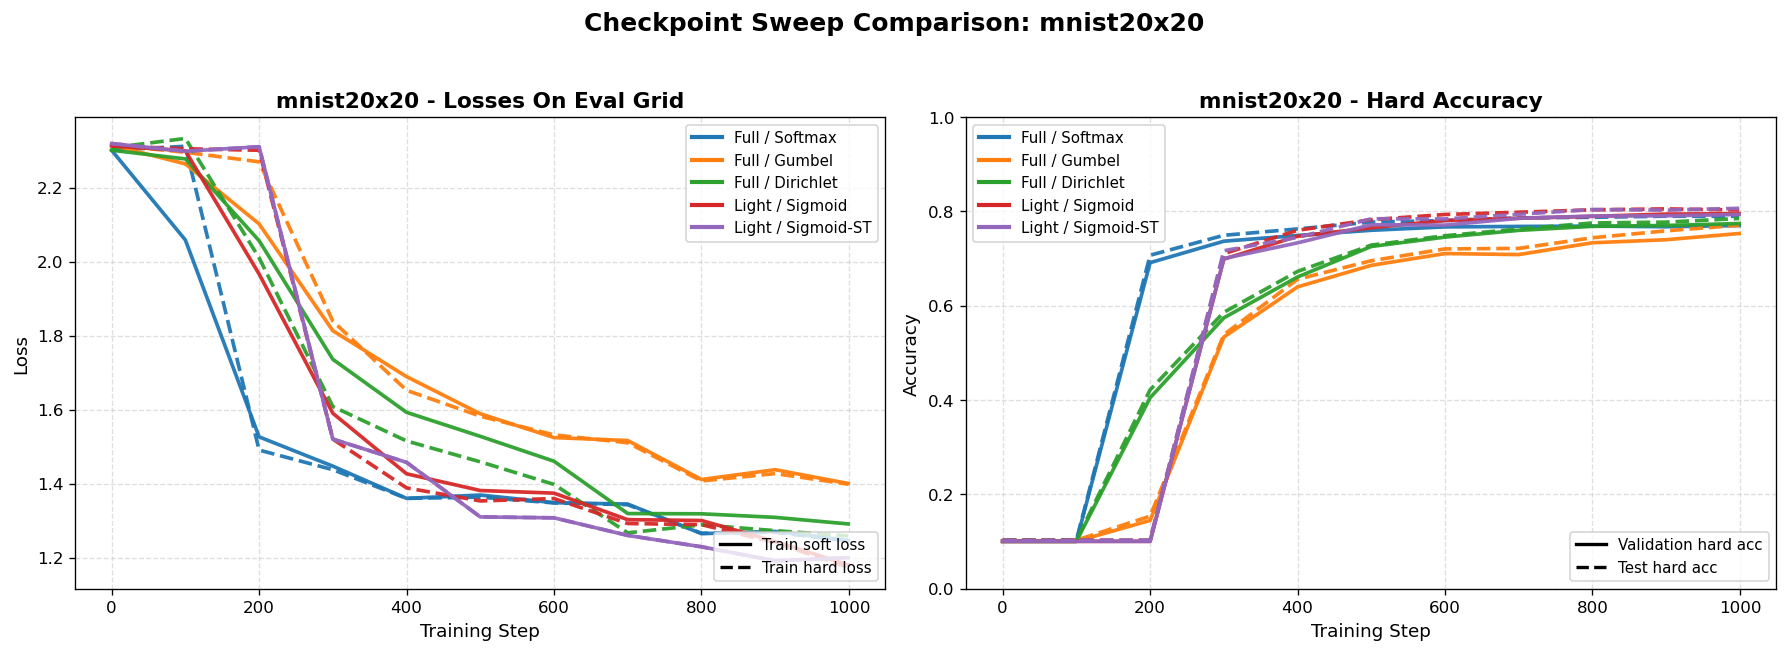

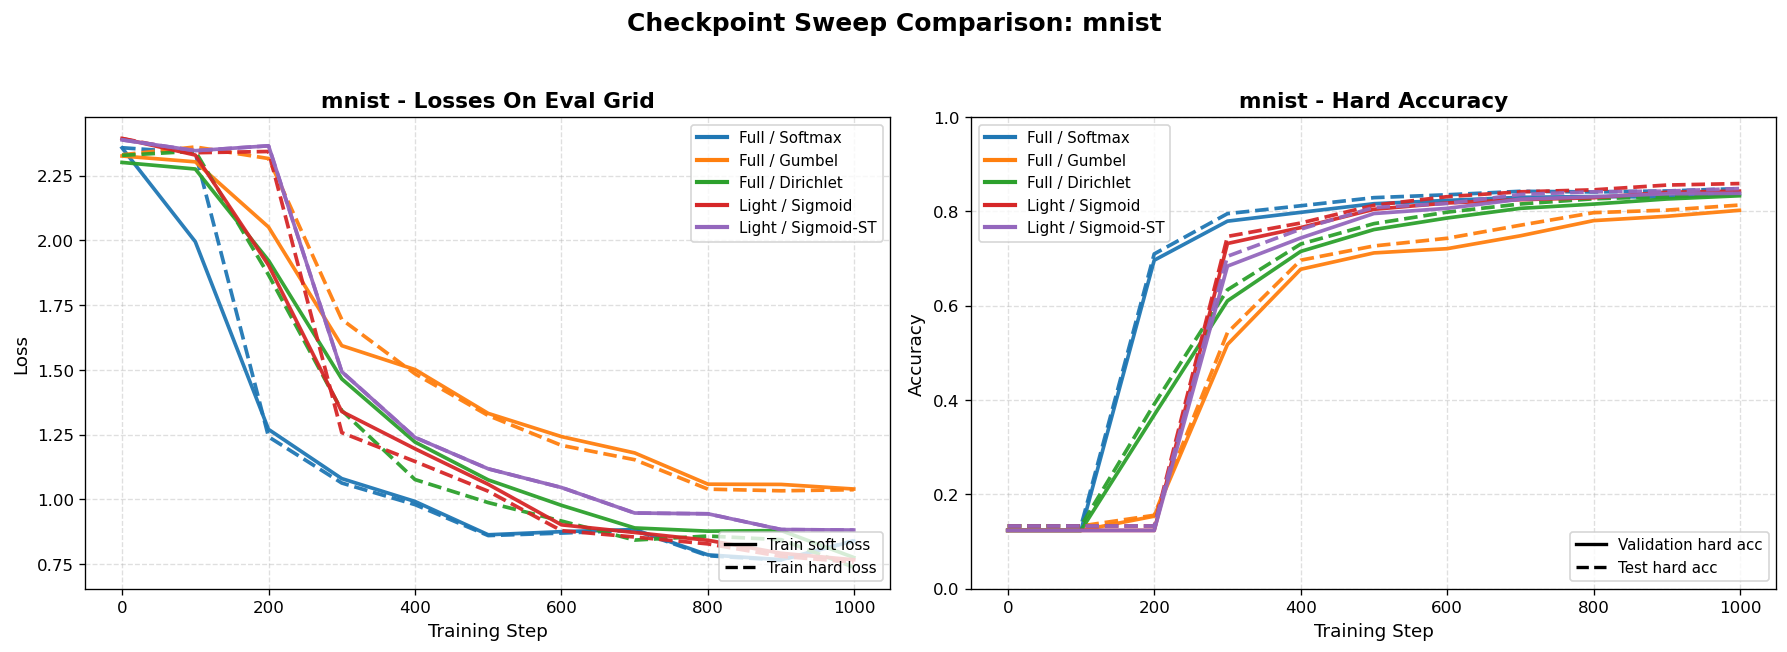

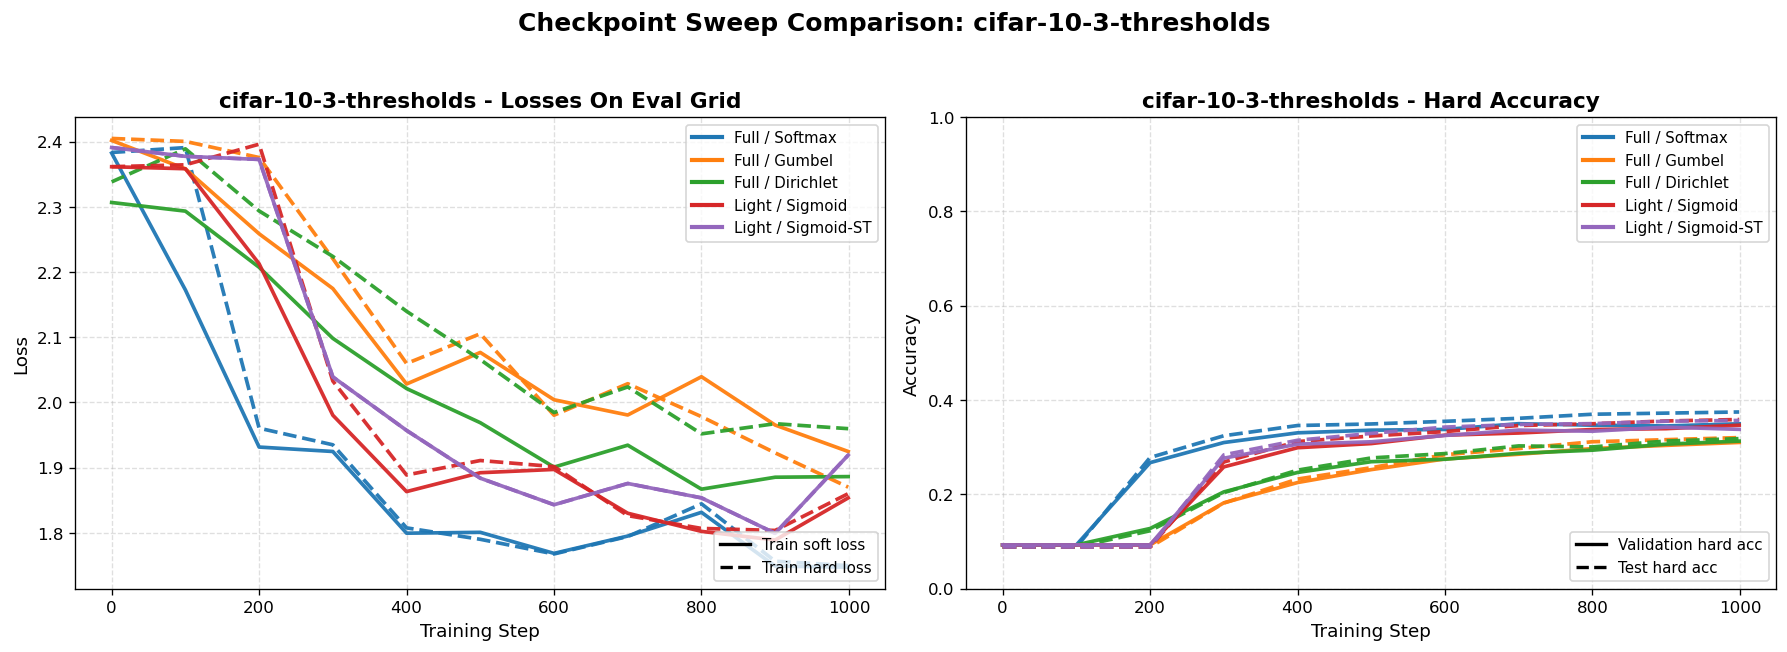

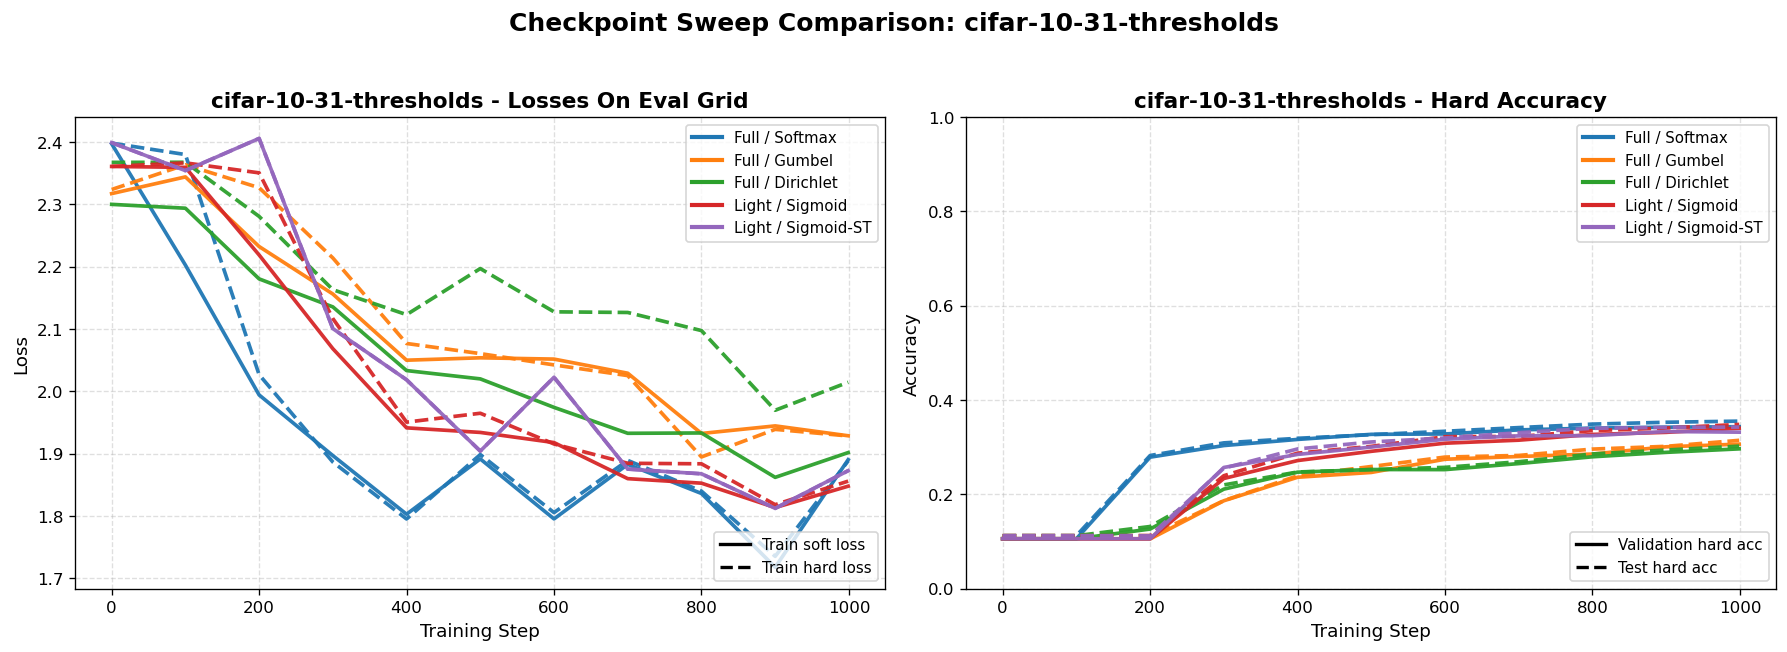

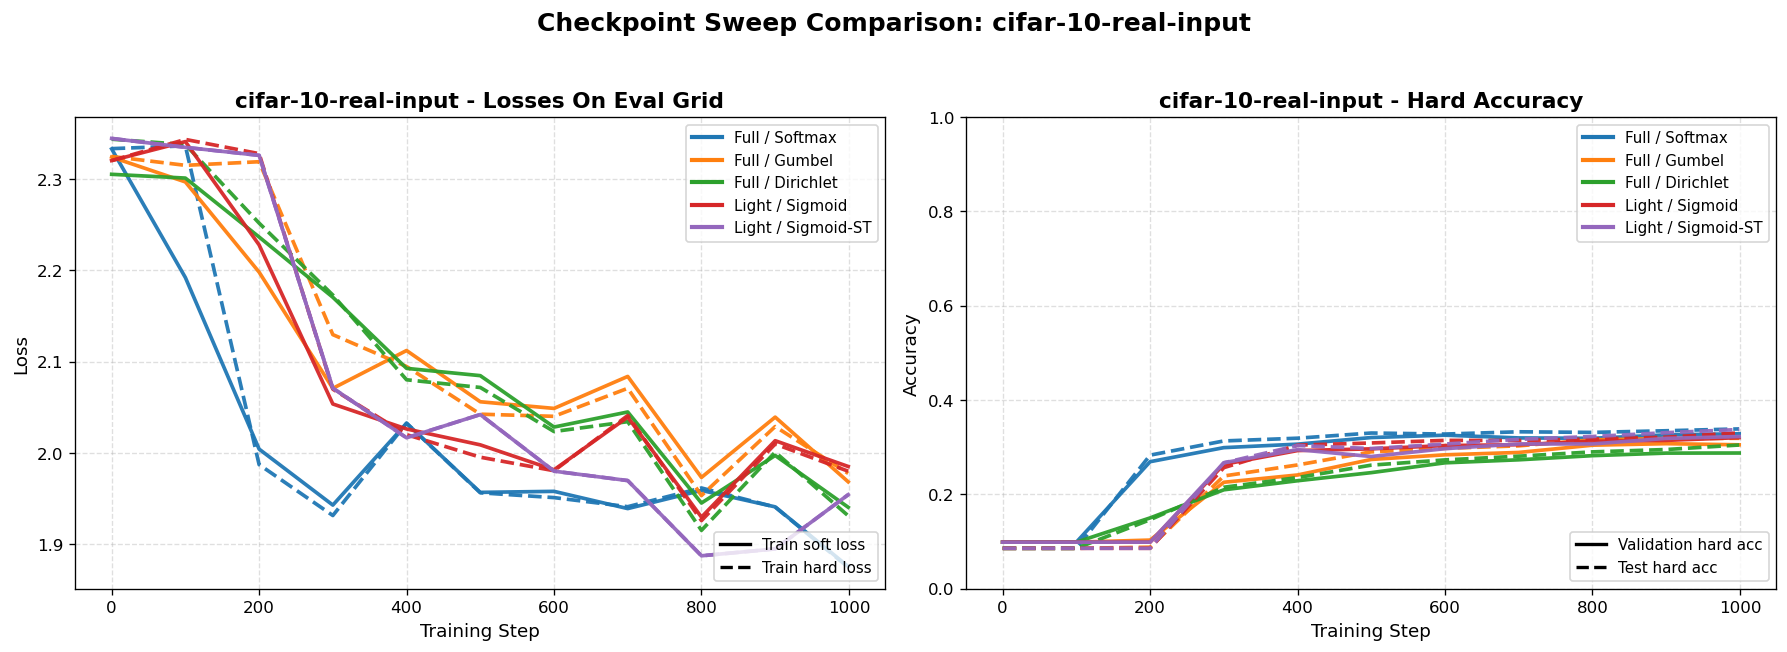

([('mnist20x20',
   <Figure size 1800x660 with 2 Axes>,
   array([<Axes: title={'center': 'mnist20x20 - Losses On Eval Grid'}, xlabel='Training Step', ylabel='Loss'>,
          <Axes: title={'center': 'mnist20x20 - Hard Accuracy'}, xlabel='Training Step', ylabel='Accuracy'>],
         dtype=object)),
  ('mnist',
   <Figure size 1800x660 with 2 Axes>,
   array([<Axes: title={'center': 'mnist - Losses On Eval Grid'}, xlabel='Training Step', ylabel='Loss'>,
          <Axes: title={'center': 'mnist - Hard Accuracy'}, xlabel='Training Step', ylabel='Accuracy'>],
         dtype=object)),
  ('cifar-10-3-thresholds',
   <Figure size 1800x660 with 2 Axes>,
   array([<Axes: title={'center': 'cifar-10-3-thresholds - Losses On Eval Grid'}, xlabel='Training Step', ylabel='Loss'>,
          <Axes: title={'center': 'cifar-10-3-thresholds - Hard Accuracy'}, xlabel='Training Step', ylabel='Accuracy'>],
         dtype=object)),
  ('cifar-10-31-thresholds',
   <Figure size 1800x660 with 2 Axes>,
   array

In [35]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import pickle

import numpy as np


DATASET_ORDER = [
    "mnist20x20",
    "mnist",
    "cifar-10-3-thresholds",
    "cifar-10-31-thresholds",
    "cifar-10-real-input",
]

MODEL_ORDER = [
    ("full", "softmax"),
    ("full", "gumbel"),
    ("full", "dirichlet"),
    ("light", "light_sigmoid"),
    ("light", "light_st"),
]

MODEL_LABELS = {
    ("full", "softmax"): "Full / Softmax",
    ("full", "gumbel"): "Full / Gumbel",
    ("full", "dirichlet"): "Full / Dirichlet",
    ("light", "light_sigmoid"): "Light / Sigmoid",
    ("light", "light_st"): "Light / Sigmoid-ST",
}

MODEL_COLORS = {
    ("full", "softmax"): "#1f77b4",
    ("full", "gumbel"): "#ff7f0e",
    ("full", "dirichlet"): "#2ca02c",
    ("light", "light_sigmoid"): "#d62728",
    ("light", "light_st"): "#9467bd",
}


def load_pickle_checkpoint(path: str | Path) -> dict:
    path = Path(path)
    with path.open("rb") as f:
        return pickle.load(f)


def _nan_array(values, length: int) -> np.ndarray:
    arr = np.full(length, np.nan, dtype=float)
    for idx, value in enumerate(values[:length]):
        if value is not None:
            arr[idx] = float(value)
    return arr


def _sample_history_on_eval_grid(payload: dict) -> dict:
    history = payload["history"]
    config = payload["config"]
    dataset_info = payload["dataset_info"]

    steps = list(history["steps"])
    train_soft = list(history["train_soft_loss"])
    train_hard = list(history["train_hard_loss"])
    valid_hard = list(history["valid_hard_acc"])
    test_hard = list(history["test_hard_acc"])

    if not steps:
        raise ValueError("Checkpoint history is empty")

    eval_every = int(config.get("eval_every", 100))
    last_step = int(steps[-1])
    eval_indices = [
        idx
        for idx, step in enumerate(steps)
        if (int(step) % eval_every == 0) or (int(step) == last_step)
    ]

    aligned_len = min(
        len(eval_indices),
        len(valid_hard),
        len(test_hard),
    )
    if aligned_len == 0:
        raise ValueError("Could not align train/eval history for plotting")

    eval_indices = eval_indices[:aligned_len]
    eval_steps = np.asarray([int(steps[idx]) for idx in eval_indices], dtype=int)

    sampled_soft = np.asarray([float(train_soft[idx]) for idx in eval_indices], dtype=float)
    sampled_hard = np.asarray([float(train_hard[idx]) for idx in eval_indices], dtype=float)
    valid_hard = _nan_array(valid_hard, aligned_len)
    test_hard = _nan_array(test_hard, aligned_len)

    logic_family = str(dataset_info["logic_family"])
    architecture = str(config["architecture"])

    return {
        "dataset": str(dataset_info["dataset"]),
        "logic_family": logic_family,
        "architecture": architecture,
        "model_key": (logic_family, architecture),
        "label": MODEL_LABELS.get((logic_family, architecture), f"{logic_family} / {architecture}"),
        "color": MODEL_COLORS.get((logic_family, architecture), None),
        "eval_steps": eval_steps,
        "sampled_train_soft_loss": sampled_soft,
        "sampled_train_hard_loss": sampled_hard,
        "valid_hard_acc": valid_hard,
        "test_hard_acc": test_hard,
        "path": str(payload.get("_source_path", "")),
    }


def collect_runs(checkpoint_dir: str | Path = "model_checkpoints") -> dict[str, list[dict]]:
    checkpoint_dir = Path(checkpoint_dir)
    if not checkpoint_dir.exists():
        raise FileNotFoundError(f"Checkpoint directory does not exist: {checkpoint_dir}")

    runs_by_dataset: dict[str, list[dict]] = defaultdict(list)

    for path in sorted(checkpoint_dir.glob("*.pkl")):
        if path.name == "monkey_patch_sweep_results.jsonl":
            continue

        payload = load_pickle_checkpoint(path)
        payload["_source_path"] = str(path)
        run = _sample_history_on_eval_grid(payload)
        runs_by_dataset[run["dataset"]].append(run)

    for dataset, runs in runs_by_dataset.items():
        runs.sort(key=lambda run: MODEL_ORDER.index(run["model_key"]) if run["model_key"] in MODEL_ORDER else 999)

    return runs_by_dataset


def _add_model_and_style_legends(ax, handles_for_models, primary_label: str, secondary_label: str):
    from matplotlib.lines import Line2D

    metric_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label=primary_label),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label=secondary_label),
    ]
    legend_models = ax.legend(
        handles=handles_for_models,
        loc="best",
        fontsize=9,
        frameon=True,
    )
    ax.add_artist(legend_models)
    ax.legend(handles=metric_handles, loc="lower right", fontsize=9, frameon=True)


def plot_dataset_results(dataset: str, runs: list[dict], output_dir: str | Path | None = None):
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=120)
    ax_loss, ax_acc = axes

    model_handles = []
    for run in runs:
        color = run["color"]
        label = run["label"]
        steps = run["eval_steps"]

        ax_loss.plot(
            steps,
            run["sampled_train_soft_loss"],
            color=color,
            linestyle="-",
            linewidth=2.2,
            alpha=0.95,
        )
        ax_loss.plot(
            steps,
            run["sampled_train_hard_loss"],
            color=color,
            linestyle="--",
            linewidth=2.2,
            alpha=0.95,
        )

        ax_acc.plot(
            steps,
            run["valid_hard_acc"],
            color=color,
            linestyle="-",
            linewidth=2.2,
            alpha=0.95,
        )
        ax_acc.plot(
            steps,
            run["test_hard_acc"],
            color=color,
            linestyle="--",
            linewidth=2.2,
            alpha=0.95,
        )

        model_handles.append(Line2D([0], [0], color=color, linewidth=2.5, label=label))

    ax_loss.set_title(f"{dataset} - Losses On Eval Grid", fontsize=13, fontweight="bold")
    ax_loss.set_xlabel("Training Step", fontsize=11)
    ax_loss.set_ylabel("Loss", fontsize=11)
    ax_loss.grid(True, linestyle="--", alpha=0.4)

    ax_acc.set_title(f"{dataset} - Hard Accuracy", fontsize=13, fontweight="bold")
    ax_acc.set_xlabel("Training Step", fontsize=11)
    ax_acc.set_ylabel("Accuracy", fontsize=11)
    ax_acc.set_ylim(0.0, 1.0)
    ax_acc.grid(True, linestyle="--", alpha=0.4)

    _add_model_and_style_legends(
        ax_loss,
        model_handles,
        primary_label="Train soft loss",
        secondary_label="Train hard loss",
    )

    acc_style_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="Validation hard acc"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Test hard acc"),
    ]
    legend_models = ax_acc.legend(
        handles=model_handles,
        loc="best",
        fontsize=9,
        frameon=True,
    )
    ax_acc.add_artist(legend_models)
    ax_acc.legend(handles=acc_style_handles, loc="lower right", fontsize=9, frameon=True)

    fig.suptitle(f"Checkpoint Sweep Comparison: {dataset}", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        out_path = output_dir / f"{dataset.replace('/', '_')}__comparison.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    return fig, axes


def plot_all_datasets(
    checkpoint_dir: str | Path = "model_checkpoints",
    output_dir: str | Path | None = None,
    show: bool = True,
):
    import matplotlib.pyplot as plt

    runs_by_dataset = collect_runs(checkpoint_dir)
    figures = []

    dataset_names = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
    dataset_names.extend(sorted(set(runs_by_dataset) - set(dataset_names)))

    for dataset in dataset_names:
        fig, axes = plot_dataset_results(dataset, runs_by_dataset[dataset], output_dir=output_dir)
        figures.append((dataset, fig, axes))

    if show:
        plt.show()

    return figures, runs_by_dataset


plot_all_datasets(checkpoint_dir="model_checkpoints", output_dir=None, show=True,)

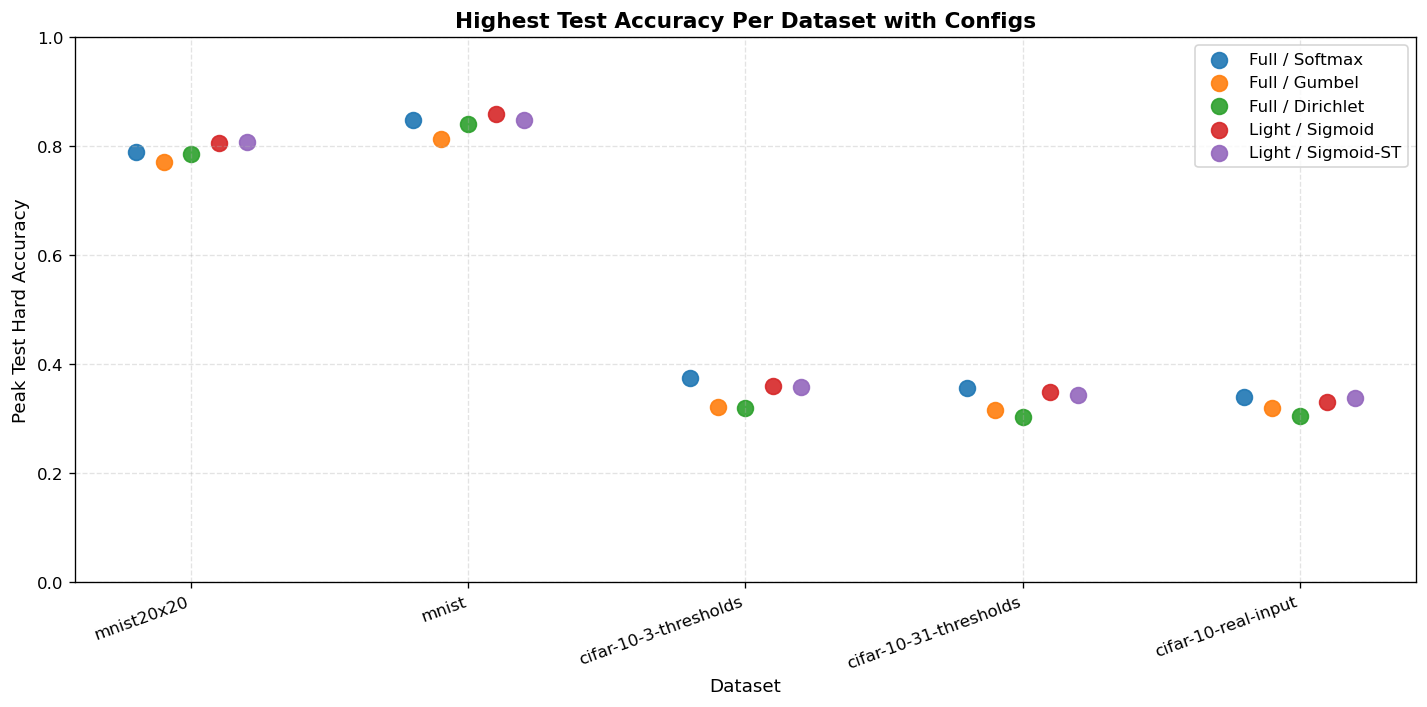

[{'dataset': 'cifar-10-3-thresholds',
  'logic_family': 'full',
  'architecture': 'dirichlet',
  'model_key': ('full', 'dirichlet'),
  'label': 'Full / Dirichlet',
  'peak_test_hard_acc': 0.3181,
  'checkpoint': 'model_checkpoints/cifar-10-3-thresholds__full__dirichlet__L8__N800__BS256__steps1000__seed0.pkl'},
 {'dataset': 'cifar-10-3-thresholds',
  'logic_family': 'full',
  'architecture': 'gumbel',
  'model_key': ('full', 'gumbel'),
  'label': 'Full / Gumbel',
  'peak_test_hard_acc': 0.3203,
  'checkpoint': 'model_checkpoints/cifar-10-3-thresholds__full__gumbel__L8__N800__BS256__steps1000__seed0.pkl'},
 {'dataset': 'cifar-10-3-thresholds',
  'logic_family': 'full',
  'architecture': 'softmax',
  'model_key': ('full', 'softmax'),
  'label': 'Full / Softmax',
  'peak_test_hard_acc': 0.3746,
  'checkpoint': 'model_checkpoints/cifar-10-3-thresholds__full__softmax__L8__N800__BS256__steps1000__seed0.pkl'},
 {'dataset': 'cifar-10-3-thresholds',
  'logic_family': 'light',
  'architecture': '

In [38]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

DATASET_ORDER = [
    "mnist20x20",
    "mnist",
    "cifar-10-3-thresholds",
    "cifar-10-31-thresholds",
    "cifar-10-real-input",
]

MODEL_ORDER = [
    ("full", "softmax"),
    ("full", "gumbel"),
    ("full", "dirichlet"),
    ("light", "light_sigmoid"),
    ("light", "light_st"),
]

MODEL_LABELS = {
    ("full", "softmax"): "Full / Softmax",
    ("full", "gumbel"): "Full / Gumbel",
    ("full", "dirichlet"): "Full / Dirichlet",
    ("light", "light_sigmoid"): "Light / Sigmoid",
    ("light", "light_st"): "Light / Sigmoid-ST",
}

MODEL_COLORS = {
    ("full", "softmax"): "#1f77b4",
    ("full", "gumbel"): "#ff7f0e",
    ("full", "dirichlet"): "#2ca02c",
    ("light", "light_sigmoid"): "#d62728",
    ("light", "light_st"): "#9467bd",
}


def load_checkpoint(path):
    with Path(path).open("rb") as f:
        return pickle.load(f)


def collect_peak_test_acc(checkpoint_dir="model_checkpoints"):
    checkpoint_dir = Path(checkpoint_dir)
    rows = []

    for path in sorted(checkpoint_dir.glob("*.pkl")):
        payload = load_checkpoint(path)
        history = payload["history"]
        config = payload["config"]
        dataset_info = payload["dataset_info"]

        test_hard_acc = [x for x in history["test_hard_acc"] if x is not None]
        if not test_hard_acc:
            continue

        logic_family = str(dataset_info["logic_family"])
        architecture = str(config["architecture"])
        model_key = (logic_family, architecture)

        rows.append({
            "dataset": str(dataset_info["dataset"]),
            "logic_family": logic_family,
            "architecture": architecture,
            "model_key": model_key,
            "label": MODEL_LABELS.get(model_key, f"{logic_family} / {architecture}"),
            "peak_test_hard_acc": float(max(test_hard_acc)),
            "checkpoint": str(path),
        })

    return rows


def plot_peak_test_acc_scatter(checkpoint_dir="model_checkpoints"):
    rows = collect_peak_test_acc(checkpoint_dir)

    fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

    x_positions = np.arange(len(DATASET_ORDER))
    dataset_to_x = {dataset: i for i, dataset in enumerate(DATASET_ORDER)}

    jitter_offsets = {
        ("full", "softmax"): -0.20,
        ("full", "gumbel"): -0.10,
        ("full", "dirichlet"): 0.00,
        ("light", "light_sigmoid"): 0.10,
        ("light", "light_st"): 0.20,
    }

    for model_key in MODEL_ORDER:
        model_rows = [r for r in rows if r["model_key"] == model_key]
        if not model_rows:
            continue

        xs = [dataset_to_x[r["dataset"]] + jitter_offsets[model_key] for r in model_rows]
        ys = [r["peak_test_hard_acc"] for r in model_rows]

        ax.scatter(
            xs,
            ys,
            s=90,
            color=MODEL_COLORS[model_key],
            alpha=0.9,
            label=MODEL_LABELS[model_key],
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(DATASET_ORDER, rotation=20, ha="right")
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("Peak Test Hard Accuracy", fontsize=11)
    ax.set_xlabel("Dataset", fontsize=11)
    ax.set_title("Highest Test Accuracy Per Dataset with Configs", fontsize=13, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()

    return rows

plot_peak_test_acc_scatter()

saved /home/jared/git_local/Research/JAX_DLGN/checkpoint_plots/stacked_gate_histograms__fractional__no_passthrough.png


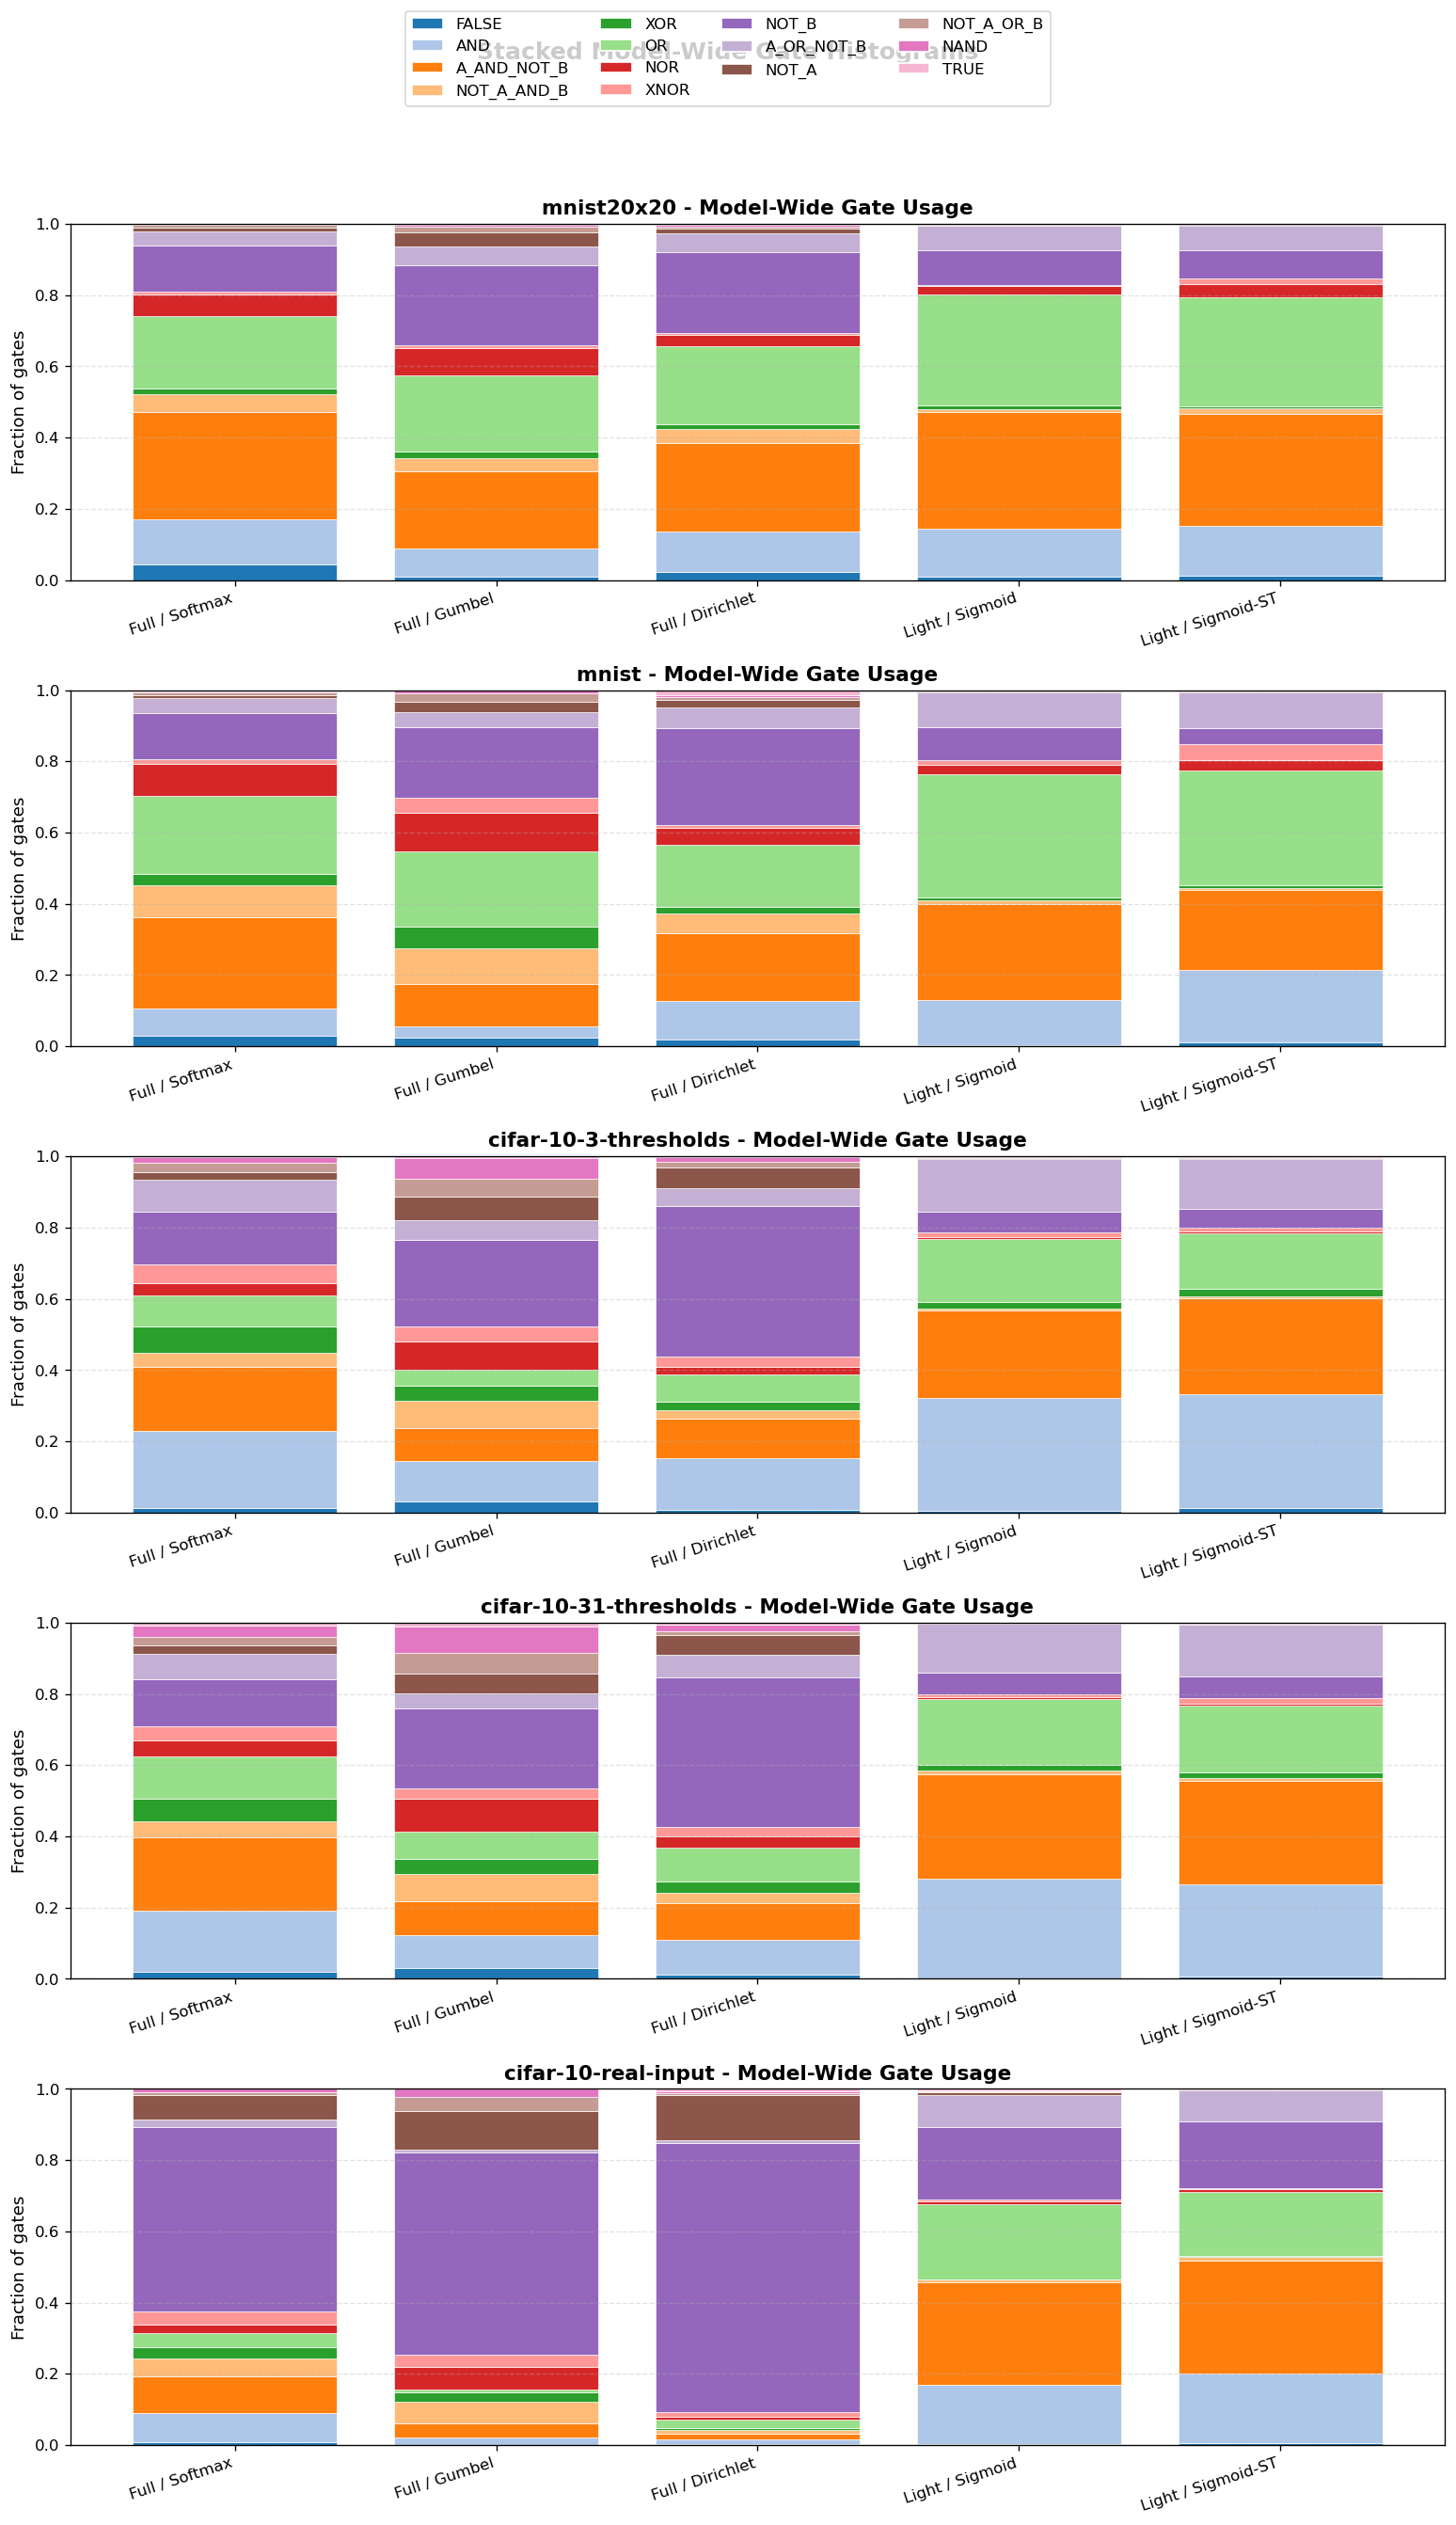

In [42]:
def plot_stacked_gate_histograms(
    checkpoint_dir: str | Path = "model_checkpoints",
    datasets: list[str] | None = None,
    normalize: bool = False,
    exclude_passthrough: bool = False,
    output_dir: str | Path | None = None,
    show: bool = True,
):
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    runs_by_dataset = collect_model_wide_gate_counts(
        checkpoint_dir=checkpoint_dir,
        exclude_passthrough=exclude_passthrough,
    )

    if datasets is None:
        datasets = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
        datasets.extend(sorted(set(runs_by_dataset) - set(datasets)))

    gate_indices = list(range(len(GATE_NAMES)))
    if exclude_passthrough:
        gate_indices = [idx for idx in gate_indices if idx not in (3, 5)]

    n = len(datasets)
    fig, axes = plt.subplots(n, 1, figsize=(13, 4.5 * n), dpi=120, squeeze=False)
    axes = axes[:, 0]

    cmap = plt.get_cmap("tab20")
    gate_colors = {
        gate_idx: cmap(i % 20)
        for i, gate_idx in enumerate(gate_indices)
    }

    for ax, dataset in zip(axes, datasets):
        runs = {run["model_key"]: run for run in runs_by_dataset.get(dataset, [])}
        x = np.arange(len(MODEL_ORDER))

        matrix = np.zeros((len(MODEL_ORDER), len(gate_indices)), dtype=float)
        for model_idx, model_key in enumerate(MODEL_ORDER):
            run = runs.get(model_key)
            if run is None:
                continue
            values = run["gate_fractions"] if normalize else run["gate_counts"]
            matrix[model_idx, :] = values[gate_indices]

        bottom = np.zeros(len(MODEL_ORDER), dtype=float)
        for gate_column, gate_idx in enumerate(gate_indices):
            heights = matrix[:, gate_column]
            ax.bar(
                x,
                heights,
                bottom=bottom,
                width=0.78,
                color=gate_colors[gate_idx],
                edgecolor="white",
                linewidth=0.4,
                label=GATE_NAMES[gate_idx],
            )
            bottom += heights

        ax.set_xticks(x)
        ax.set_xticklabels(
            [MODEL_LABELS[model_key] for model_key in MODEL_ORDER],
            rotation=18,
            ha="right",
        )
        ax.set_title(f"{dataset} - Model-Wide Gate Usage", fontsize=13, fontweight="bold")
        ax.set_ylabel("Fraction of gates" if normalize else "Gate count", fontsize=11)
        ax.grid(True, axis="y", linestyle="--", alpha=0.35)
        if normalize:
            ax.set_ylim(0.0, 1.0)

    legend_handles = [
        Patch(facecolor=gate_colors[gate_idx], edgecolor="white", label=GATE_NAMES[gate_idx])
        for gate_idx in gate_indices
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=4,
        frameon=True,
        bbox_to_anchor=(0.5, 0.995),
    )
    fig.suptitle("Stacked Model-Wide Gate Histograms", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.94))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        suffix = "fractional" if normalize else "counts"
        if exclude_passthrough:
            suffix += "__no_passthrough"
        out_path = output_dir / f"stacked_gate_histograms__{suffix}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    if show:
        plt.show()

    return fig, axes, runs_by_dataset

fig, axes, gate_runs = plot_stacked_gate_histograms(
    checkpoint_dir="model_checkpoints",
    normalize=True,
    exclude_passthrough=True,
    output_dir="checkpoint_plots",
    show=True,
)

saved /home/jared/git_local/Research/JAX_DLGN/checkpoint_plots/stacked_gate_histograms__fractional__no_passthrough.png


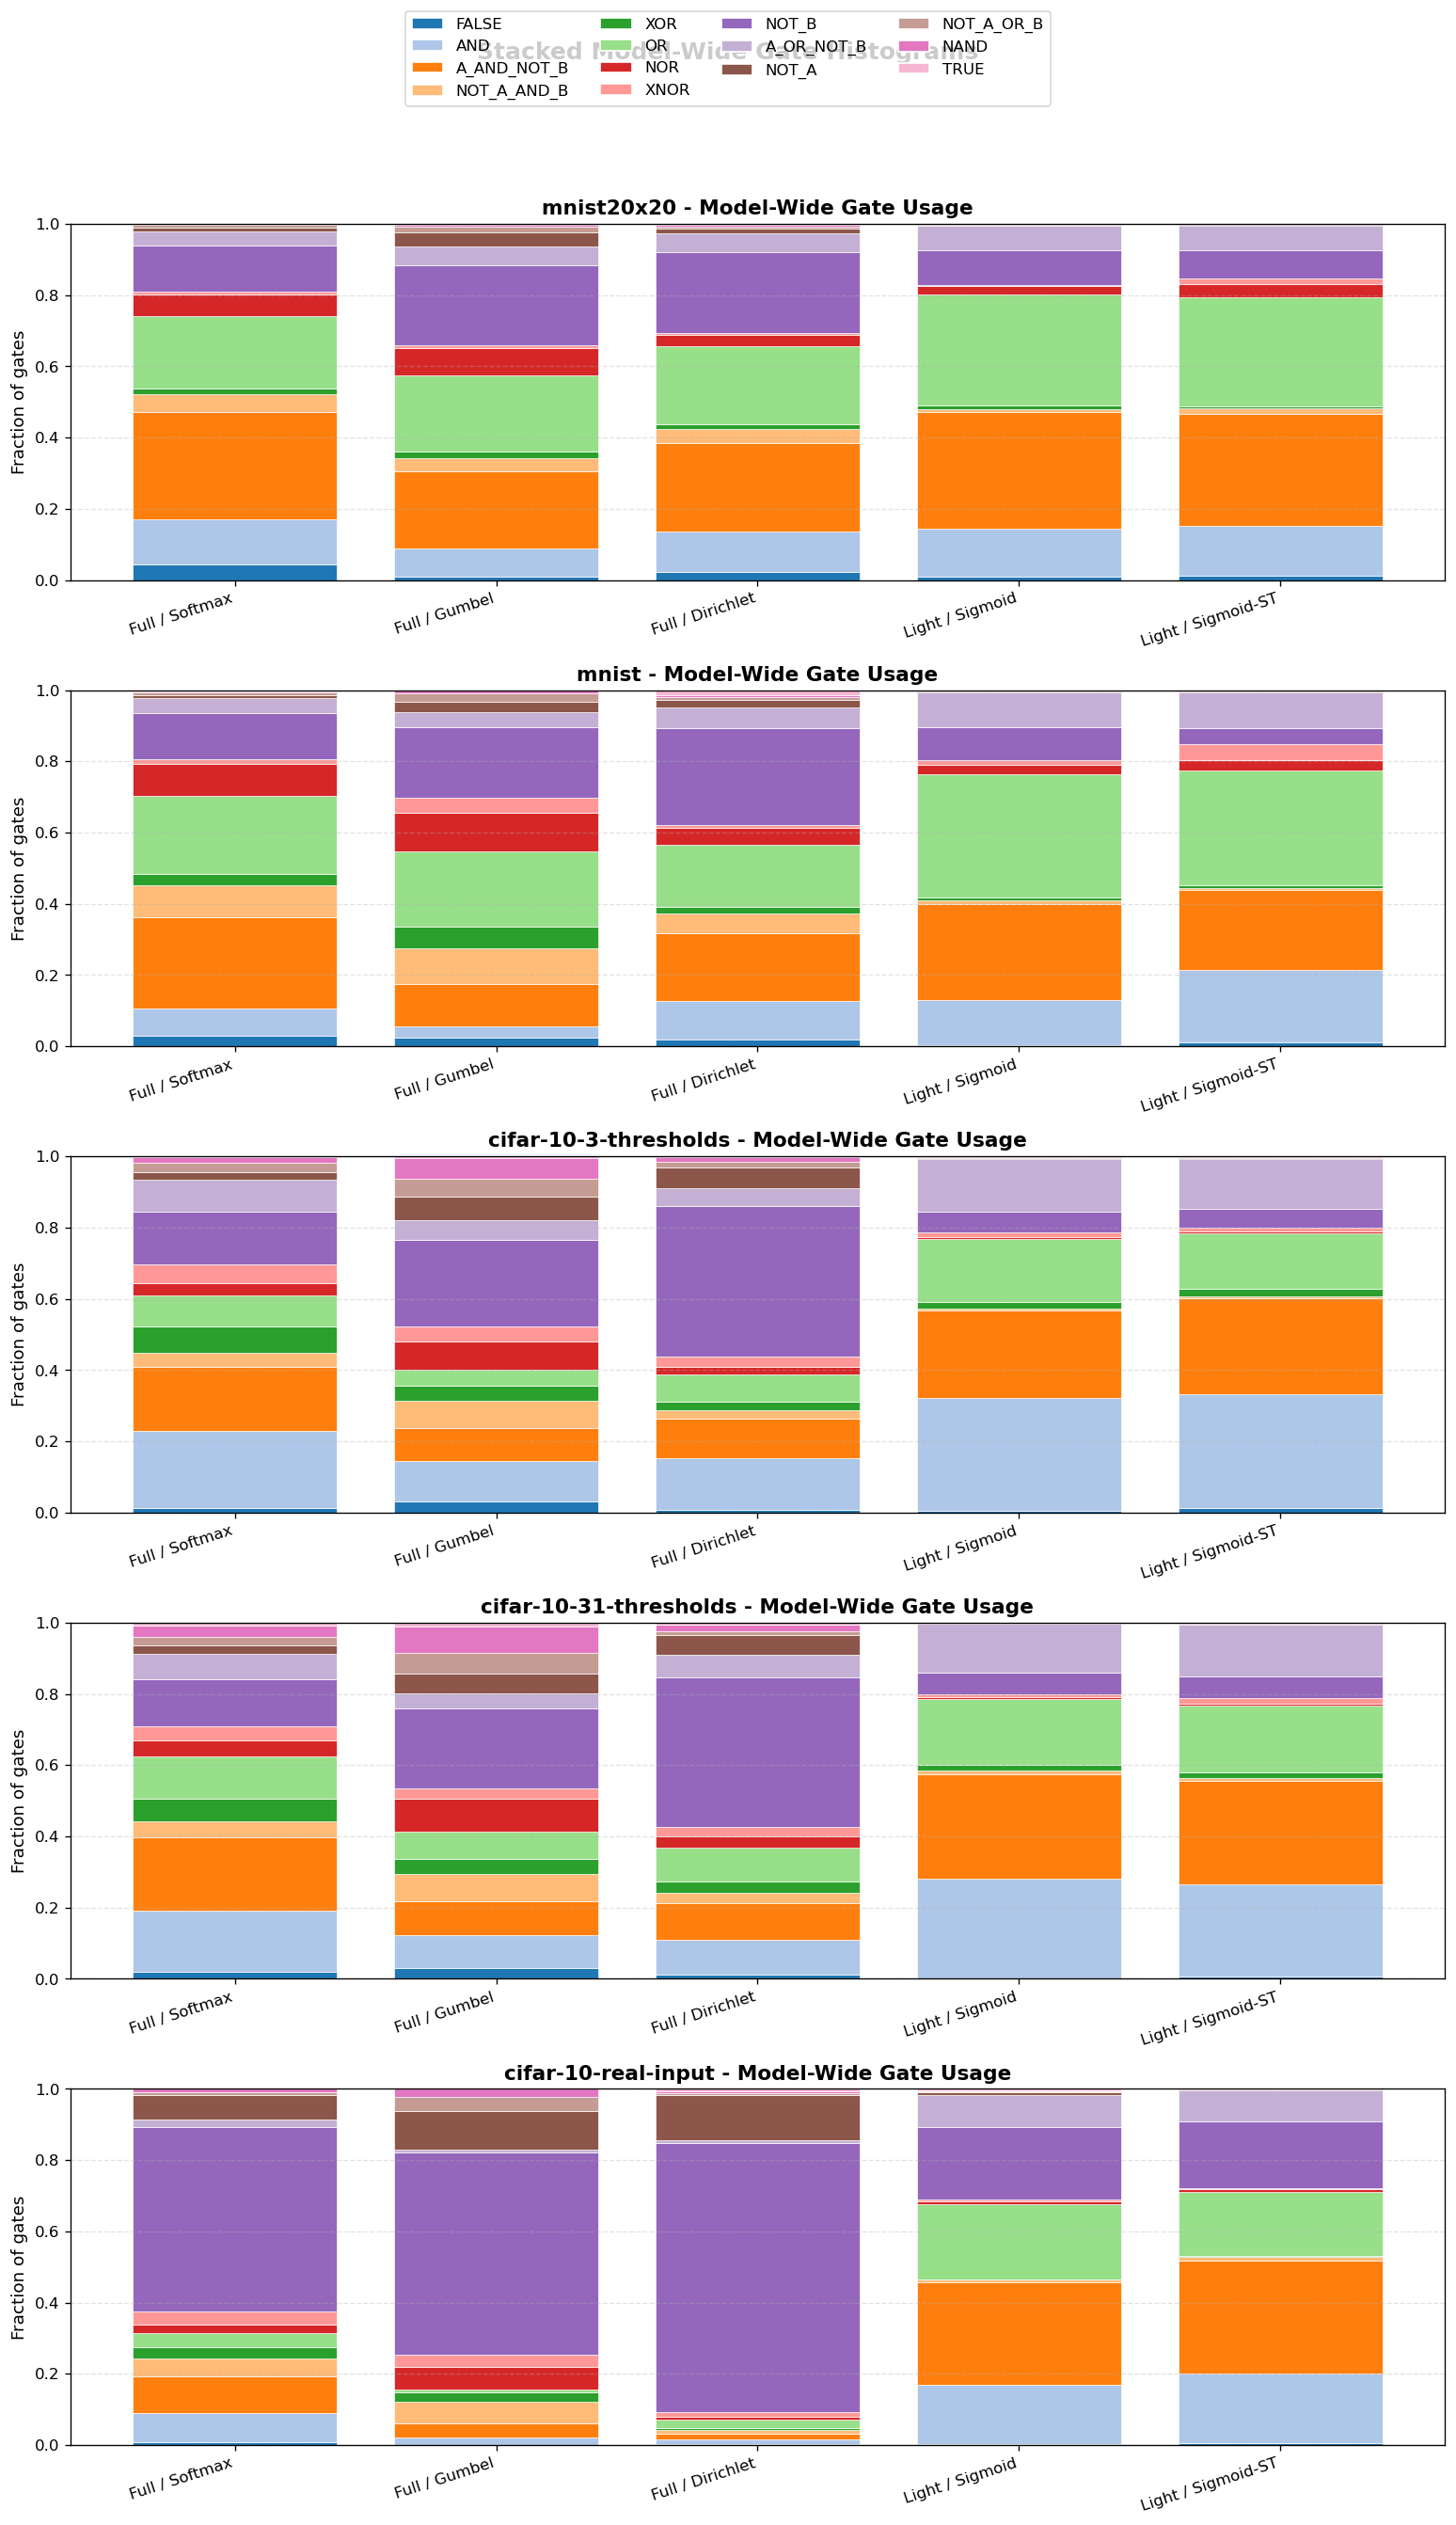

In [43]:
def plot_staggered_gate_histograms(
    checkpoint_dir: str | Path = "model_checkpoints",
    datasets: list[str] | None = None,
    normalize: bool = False,
    exclude_passthrough: bool = False,
    output_dir: str | Path | None = None,
    show: bool = True,
):
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    runs_by_dataset = collect_model_wide_gate_counts(
        checkpoint_dir=checkpoint_dir,
        exclude_passthrough=exclude_passthrough,
    )

    if datasets is None:
        datasets = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
        datasets.extend(sorted(set(runs_by_dataset) - set(datasets)))

    gate_indices = list(range(len(GATE_NAMES)))
    if exclude_passthrough:
        gate_indices = [idx for idx in gate_indices if idx not in (3, 5)]

    n = len(datasets)
    fig, axes = plt.subplots(n, 1, figsize=(16, 4.8 * n), dpi=120, squeeze=False)
    axes = axes[:, 0]

    x = np.arange(len(gate_indices), dtype=float)
    bar_width = 0.16
    offsets = np.linspace(
        -bar_width * (len(MODEL_ORDER) - 1) / 2,
        bar_width * (len(MODEL_ORDER) - 1) / 2,
        len(MODEL_ORDER),
    )

    for ax, dataset in zip(axes, datasets):
        runs = {run["model_key"]: run for run in runs_by_dataset.get(dataset, [])}

        for model_idx, model_key in enumerate(MODEL_ORDER):
            run = runs.get(model_key)
            if run is None:
                continue

            values = run["gate_fractions"] if normalize else run["gate_counts"]
            heights = values[gate_indices]

            ax.bar(
                x + offsets[model_idx],
                heights,
                width=bar_width,
                color=MODEL_COLORS[model_key],
                alpha=0.9,
                edgecolor="white",
                linewidth=0.5,
                label=MODEL_LABELS[model_key],
            )

        ax.set_xticks(x)
        ax.set_xticklabels(
            [GATE_NAMES[idx] for idx in gate_indices],
            rotation=35,
            ha="right",
        )
        ax.set_title(f"{dataset} - Staggered Model-Wide Gate Histogram", fontsize=13, fontweight="bold")
        ax.set_ylabel("Fraction of gates" if normalize else "Gate count", fontsize=11)
        ax.grid(True, axis="y", linestyle="--", alpha=0.35)
        if normalize:
            ax.set_ylim(0.0, 1.0)

    legend_handles = [
        Patch(facecolor=MODEL_COLORS[model_key], edgecolor="white", label=MODEL_LABELS[model_key])
        for model_key in MODEL_ORDER
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, 0.995),
    )
    fig.suptitle("Grouped/Staggered Gate Histograms By Dataset", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        suffix = "fractional" if normalize else "counts"
        if exclude_passthrough:
            suffix += "__no_passthrough"
        out_path = output_dir / f"staggered_gate_histograms__{suffix}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    if show:
        plt.show()

    return fig, axes, runs_by_dataset

fig, axes, gate_runs = plot_stacked_gate_histograms(
    checkpoint_dir="model_checkpoints",
    normalize=True,
    exclude_passthrough=True,
    output_dir="checkpoint_plots",
    show=True,
)

saved /home/jared/git_local/Research/JAX_DLGN/checkpoint_plots/staggered_gate_histograms__fractional__no_passthrough.png


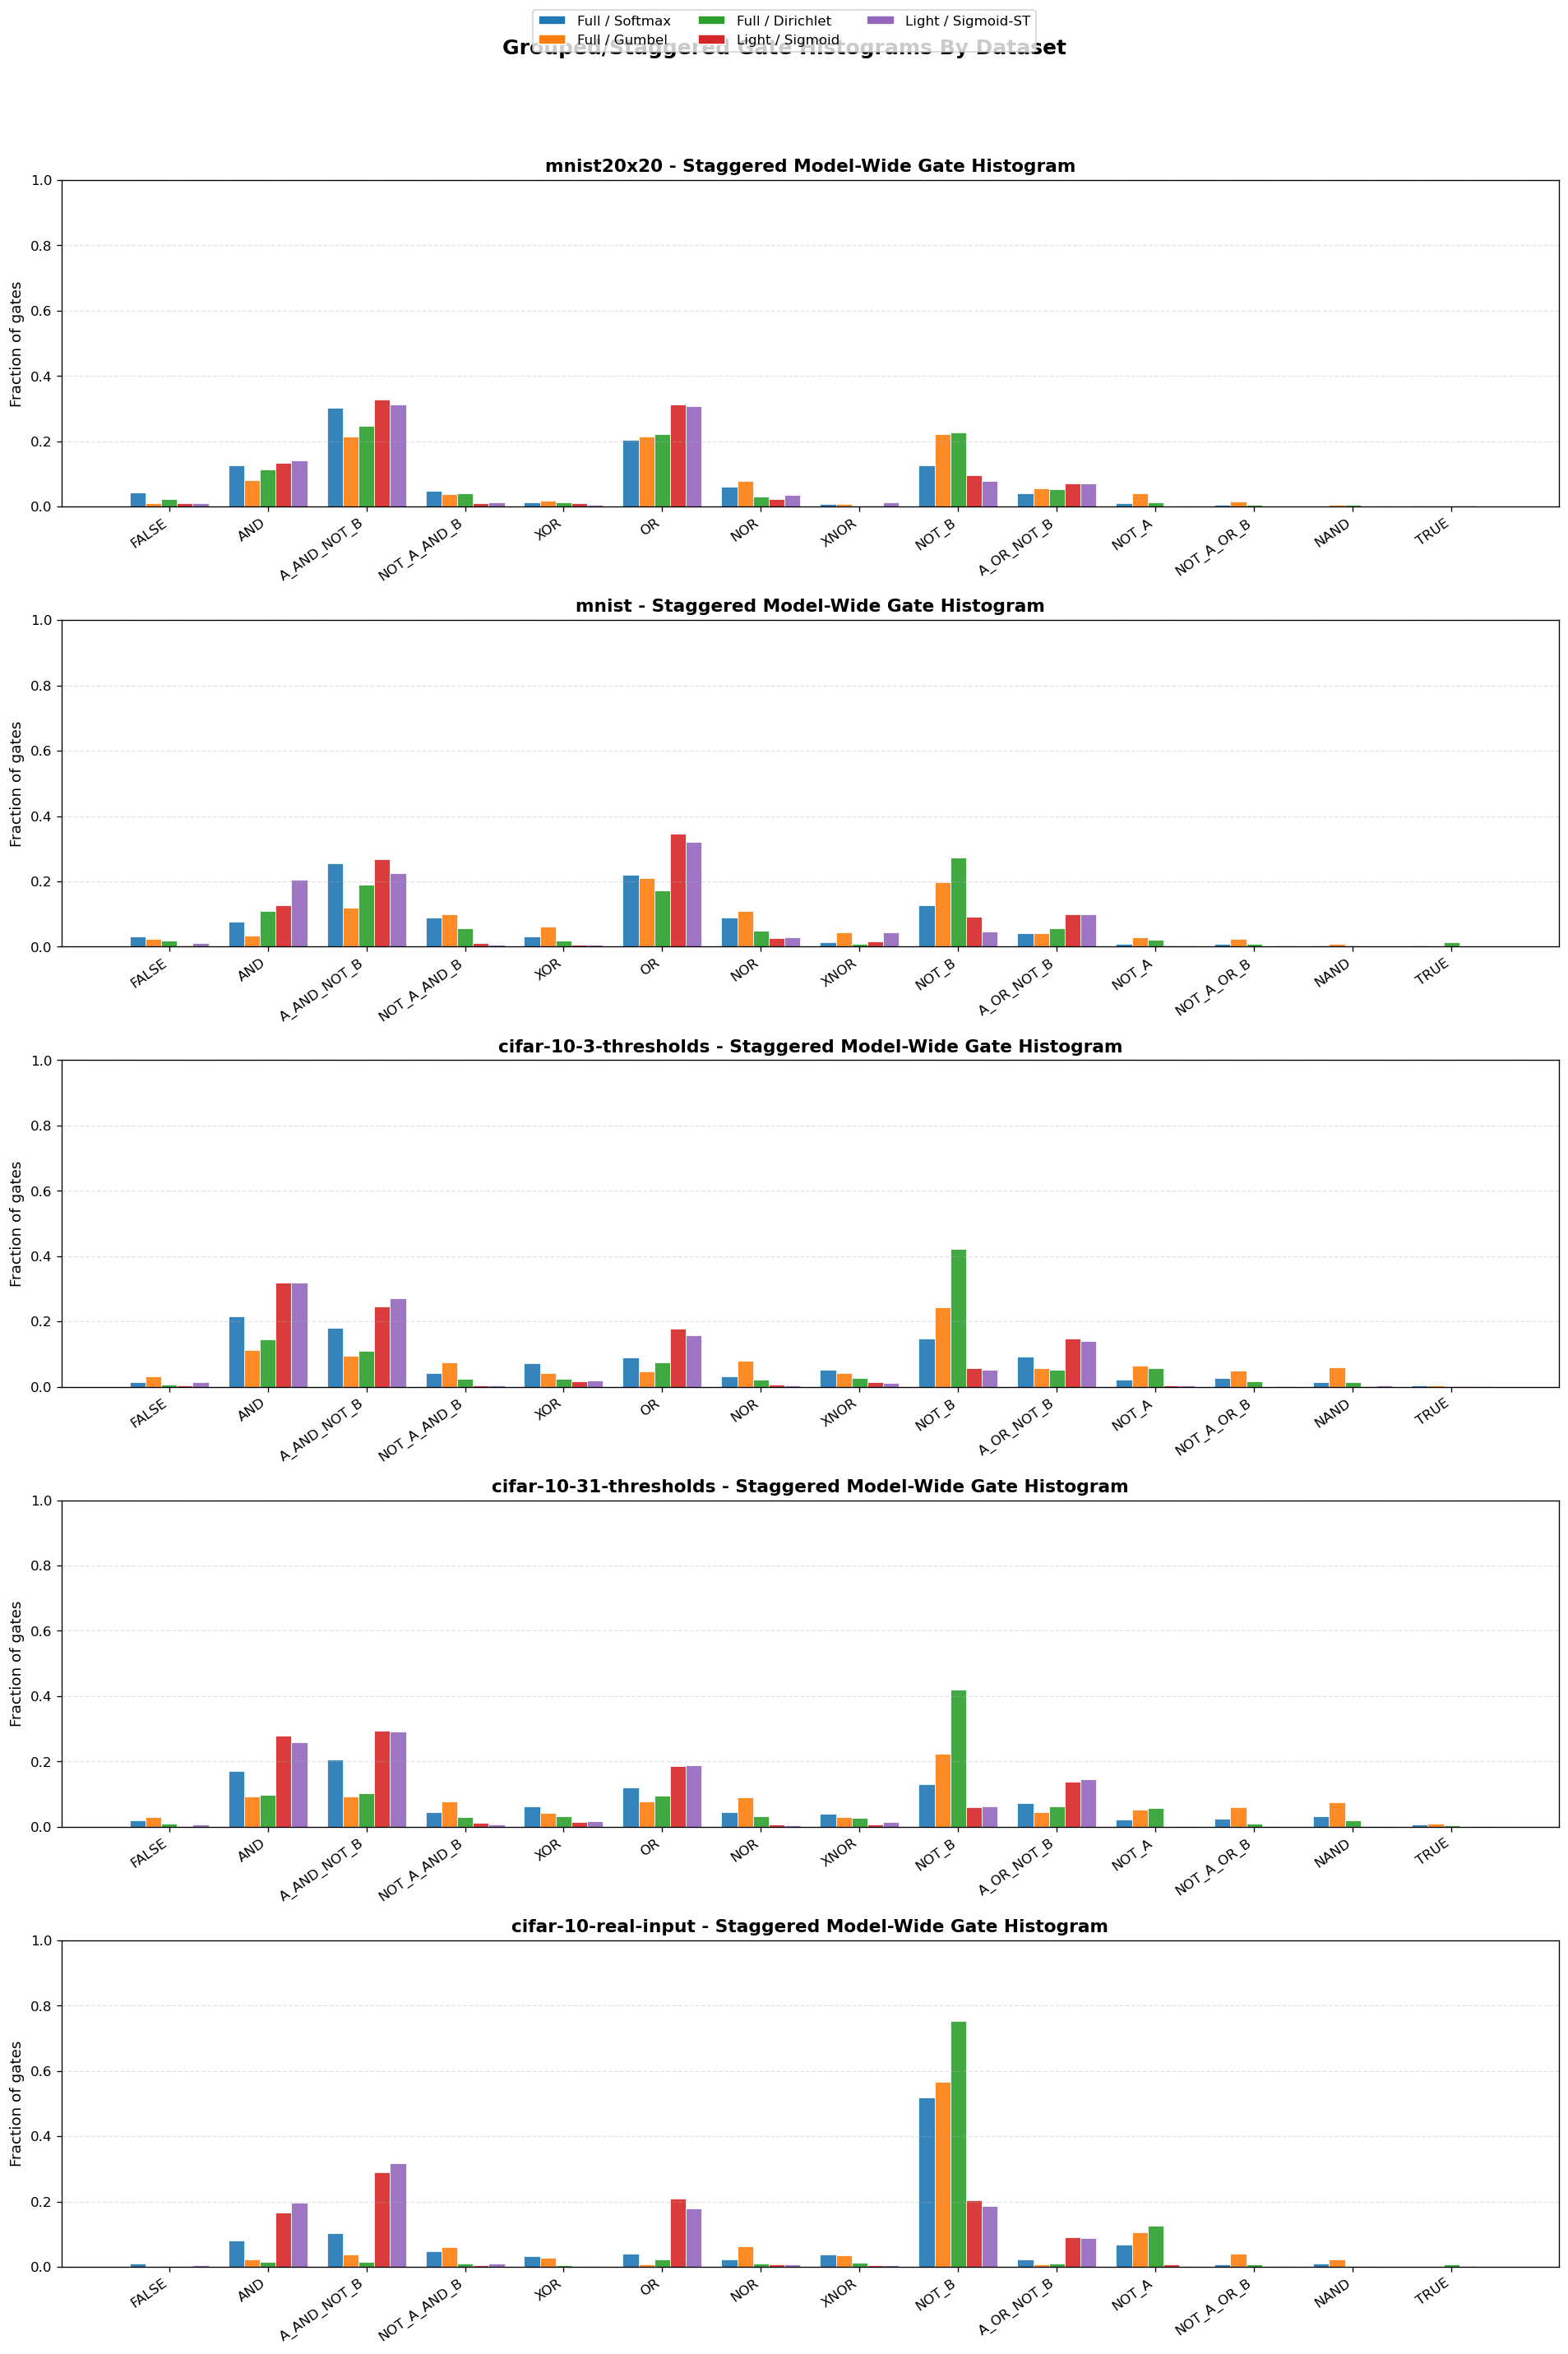

In [46]:
def plot_staggered_gate_histograms(
    checkpoint_dir: str | Path = "model_checkpoints",
    datasets: list[str] | None = None,
    normalize: bool = False,
    exclude_passthrough: bool = False,
    output_dir: str | Path | None = None,
    show: bool = True,
):
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    runs_by_dataset = collect_model_wide_gate_counts(
        checkpoint_dir=checkpoint_dir,
        exclude_passthrough=exclude_passthrough,
    )

    if datasets is None:
        datasets = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
        datasets.extend(sorted(set(runs_by_dataset) - set(datasets)))

    gate_indices = list(range(len(GATE_NAMES)))
    if exclude_passthrough:
        gate_indices = [idx for idx in gate_indices if idx not in (3, 5)]

    n = len(datasets)
    fig, axes = plt.subplots(n, 1, figsize=(16, 4.8 * n), dpi=120, squeeze=False)
    axes = axes[:, 0]

    x = np.arange(len(gate_indices), dtype=float)
    bar_width = 0.16
    offsets = np.linspace(
        -bar_width * (len(MODEL_ORDER) - 1) / 2,
        bar_width * (len(MODEL_ORDER) - 1) / 2,
        len(MODEL_ORDER),
    )

    for ax, dataset in zip(axes, datasets):
        runs = {run["model_key"]: run for run in runs_by_dataset.get(dataset, [])}

        for model_idx, model_key in enumerate(MODEL_ORDER):
            run = runs.get(model_key)
            if run is None:
                continue

            values = run["gate_fractions"] if normalize else run["gate_counts"]
            heights = values[gate_indices]

            ax.bar(
                x + offsets[model_idx],
                heights,
                width=bar_width,
                color=MODEL_COLORS[model_key],
                alpha=0.9,
                edgecolor="white",
                linewidth=0.5,
                label=MODEL_LABELS[model_key],
            )

        ax.set_xticks(x)
        ax.set_xticklabels(
            [GATE_NAMES[idx] for idx in gate_indices],
            rotation=35,
            ha="right",
        )
        ax.set_title(f"{dataset} - Staggered Model-Wide Gate Histogram", fontsize=13, fontweight="bold")
        ax.set_ylabel("Fraction of gates" if normalize else "Gate count", fontsize=11)
        ax.grid(True, axis="y", linestyle="--", alpha=0.35)
        if normalize:
            ax.set_ylim(0.0, 1.0)

    legend_handles = [
        Patch(facecolor=MODEL_COLORS[model_key], edgecolor="white", label=MODEL_LABELS[model_key])
        for model_key in MODEL_ORDER
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, 0.995),
    )
    fig.suptitle("Grouped/Staggered Gate Histograms By Dataset", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        suffix = "fractional" if normalize else "counts"
        if exclude_passthrough:
            suffix += "__no_passthrough"
        out_path = output_dir / f"staggered_gate_histograms__{suffix}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    if show:
        plt.show()

    return fig, axes, runs_by_dataset

fig, axes, gate_runs = plot_staggered_gate_histograms(
    checkpoint_dir="model_checkpoints",
    normalize=True,
    exclude_passthrough=True,
    output_dir="checkpoint_plots",
    show=True,
)

saved /home/jared/git_local/Research/JAX_DLGN/checkpoint_plots/staggered_gate_histograms__fractional__no_passthrough.png


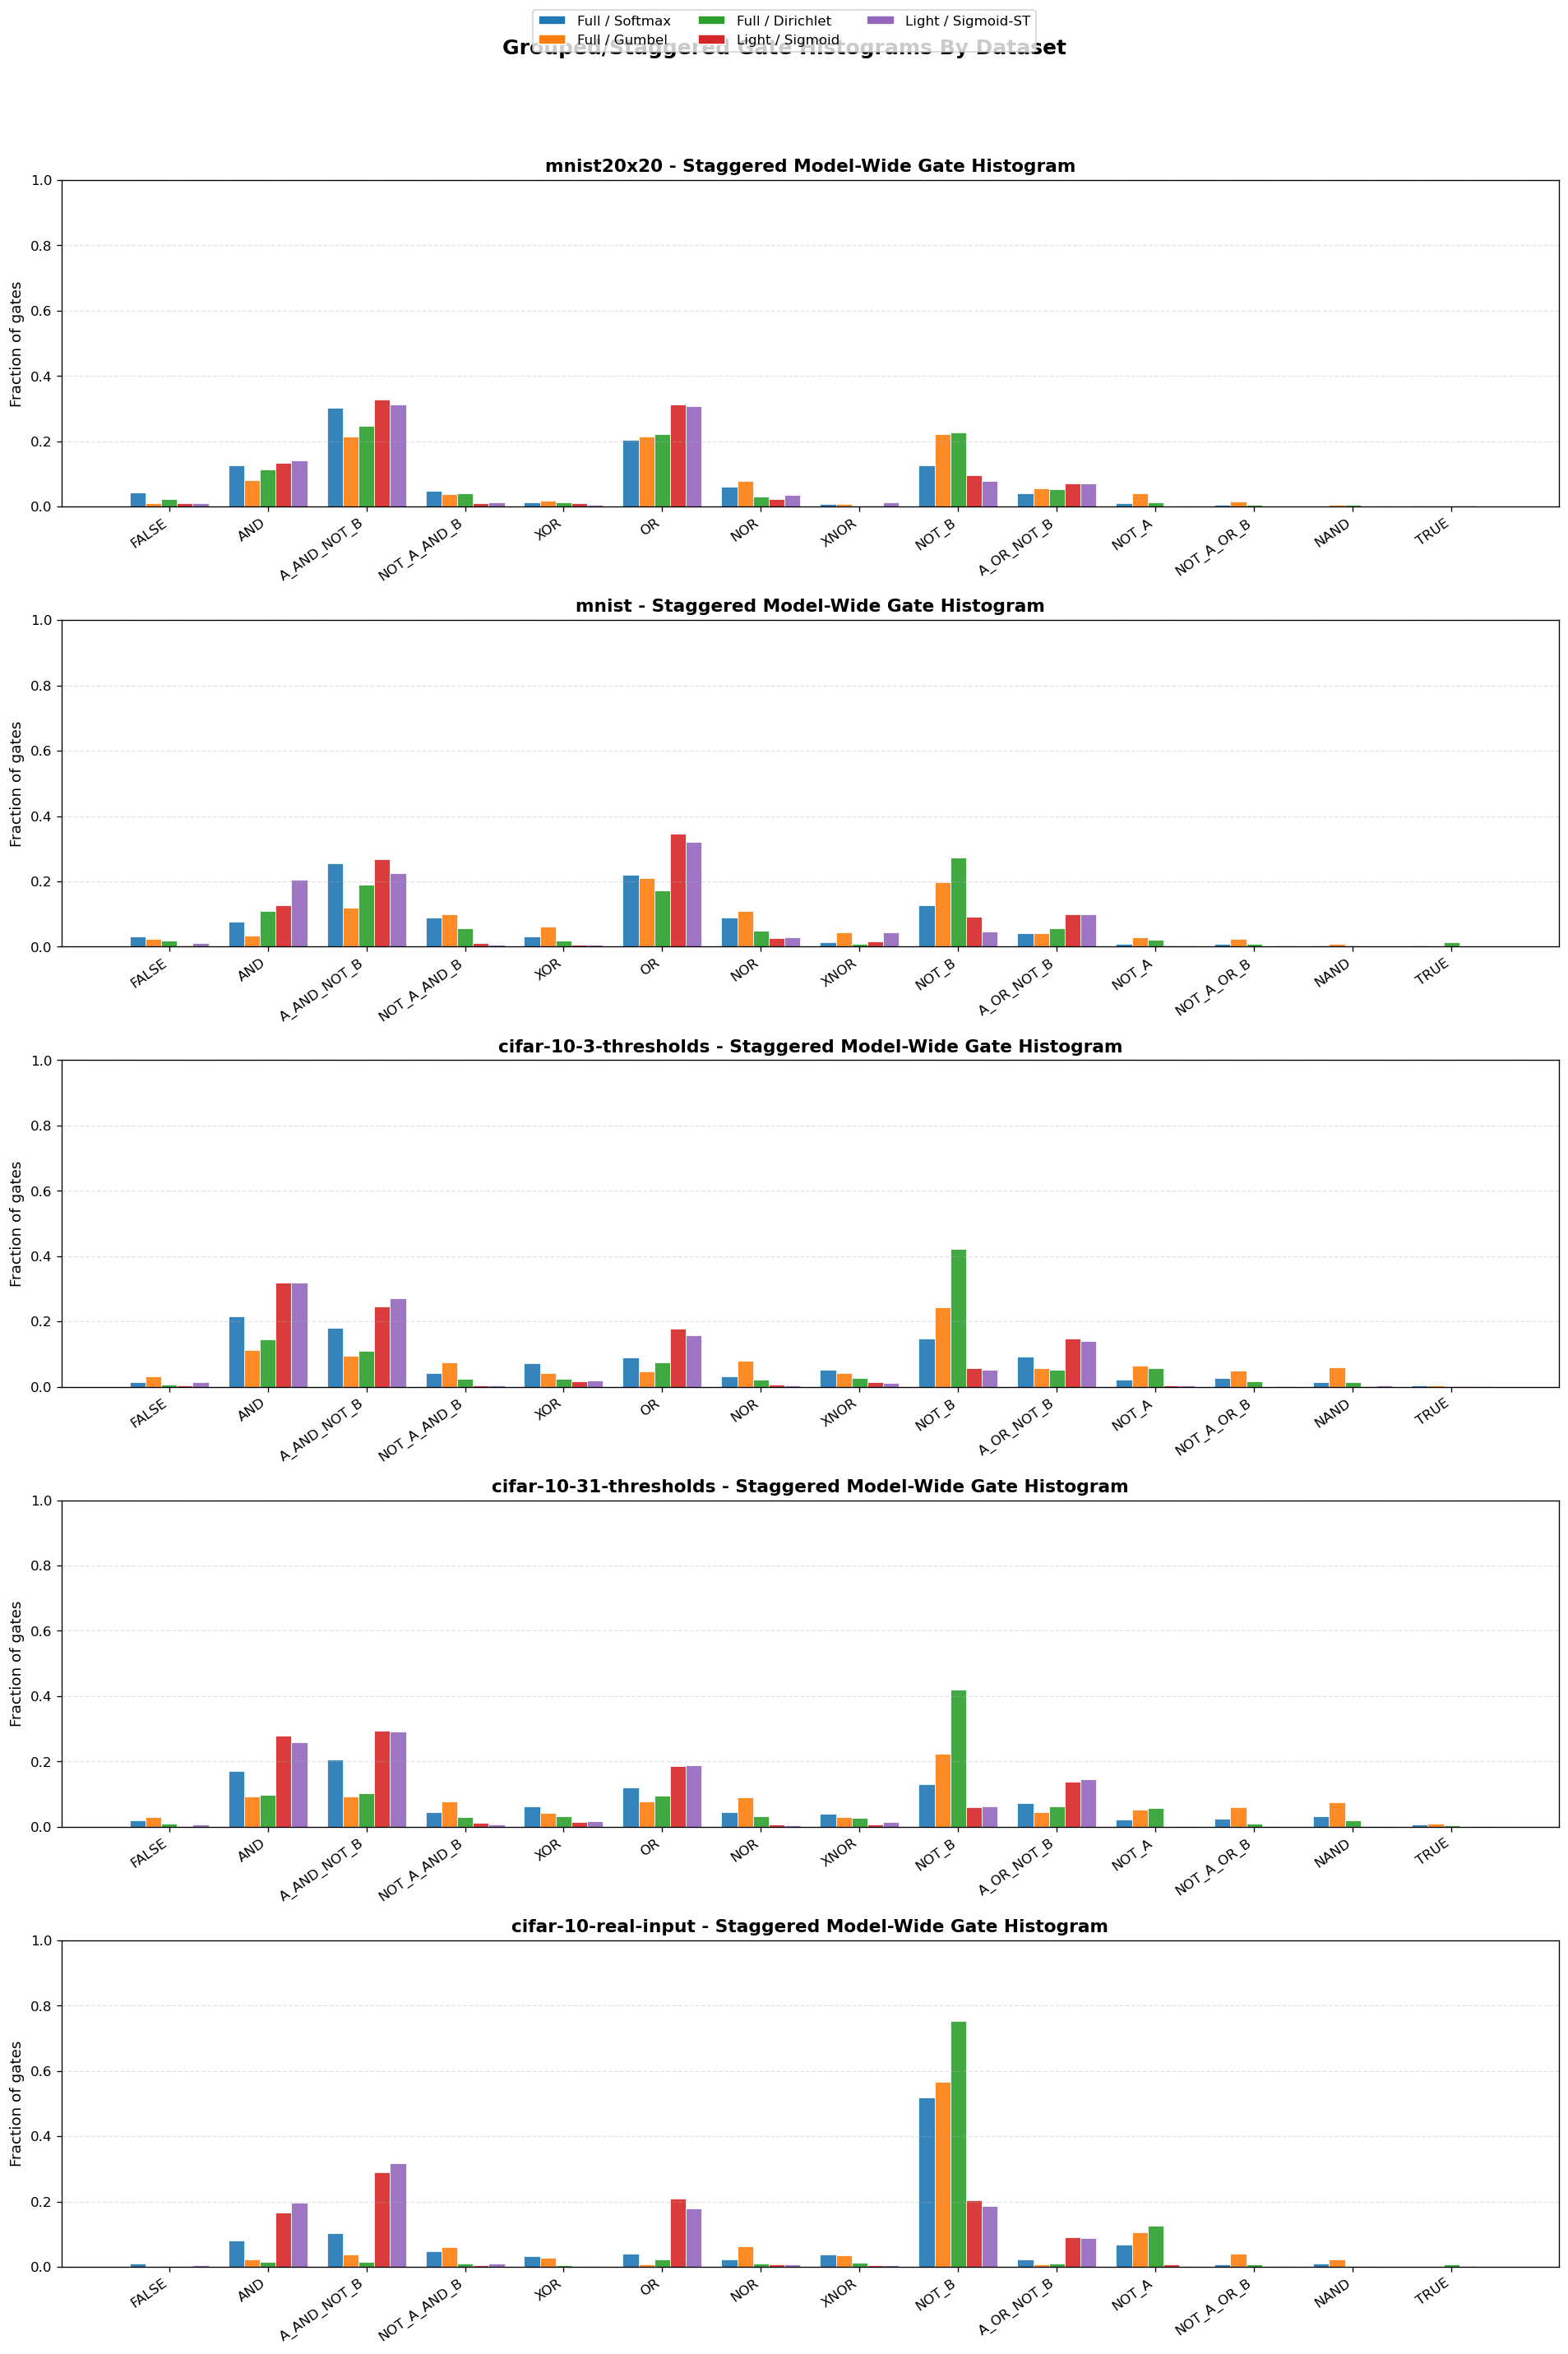

In [48]:
def plot_stacked_and_staggered_gate_histograms(
    checkpoint_dir: str | Path = "model_checkpoints",
    datasets: list[str] | None = None,
    normalize: bool = False,
    exclude_passthrough: bool = False,
    output_dir: str | Path | None = None,
    show: bool = True,
    stagger_gap: float = 0.12,   # vertical gap between staggered traces
    fill_alpha: float = 0.35,
    line_width: float = 1.8,
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from pathlib import Path

    runs_by_dataset = collect_model_wide_gate_counts(
        checkpoint_dir=checkpoint_dir,
        exclude_passthrough=exclude_passthrough,
    )

    if datasets is None:
        datasets = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
        datasets.extend(sorted(set(runs_by_dataset) - set(datasets)))

    gate_indices = list(range(len(GATE_NAMES)))
    if exclude_passthrough:
        gate_indices = [idx for idx in gate_indices if idx not in (3, 5)]

    gate_names = [GATE_NAMES[idx] for idx in gate_indices]
    x_vals = np.asarray(gate_indices, dtype=float)

    # integer-category histogram bins centered on each gate id
    bins = np.arange(min(gate_indices) - 0.5, max(gate_indices) + 1.5, 1.0)

    n = len(datasets)
    fig, axes = plt.subplots(
        n, 2,
        figsize=(18, 5.5 * n),
        dpi=120,
        squeeze=False,
        gridspec_kw={"width_ratios": [1, 1.15]},
    )

    def _get_model_values(run):
        vals = run["gate_fractions"] if normalize else run["gate_counts"]
        return np.asarray(vals)[gate_indices].astype(float)

    def _hist_inputs_from_counts(values):
        """
        Build a categorical histogram input for matplotlib.hist:
        x = gate ids
        weights = gate counts or fractions
        """
        return x_vals, values

    for row_idx, dataset in enumerate(datasets):
        ax_stack = axes[row_idx, 0]
        ax_stagger = axes[row_idx, 1]

        runs = {run["model_key"]: run for run in runs_by_dataset.get(dataset, [])}

        # keep model order fixed
        model_keys_present = [mk for mk in MODEL_ORDER if mk in runs]
        if not model_keys_present:
            ax_stack.set_visible(False)
            ax_stagger.set_visible(False)
            continue

        # -----------------------------
        # LEFT: stacked histogram
        # -----------------------------
        x_list = []
        w_list = []
        color_list = []
        label_list = []

        for model_key in model_keys_present:
            values = _get_model_values(runs[model_key])
            x_i, w_i = _hist_inputs_from_counts(values)
            x_list.append(x_i)
            w_list.append(w_i)
            color_list.append(MODEL_COLORS[model_key])
            label_list.append(MODEL_LABELS[model_key])

        ax_stack.hist(
            x_list,
            bins=bins,
            weights=w_list,
            histtype="barstacked",
            color=color_list,
            label=label_list,
            alpha=0.9,
            edgecolor="white",
            linewidth=0.7,
        )

        ax_stack.set_xticks(x_vals)
        ax_stack.set_xticklabels(gate_names, rotation=35, ha="right")
        ax_stack.set_title(
            f"{dataset} - Stacked Gate Histogram",
            fontsize=13,
            fontweight="bold",
        )
        ax_stack.set_ylabel("Fraction of gates" if normalize else "Gate count", fontsize=11)
        ax_stack.grid(True, axis="y", linestyle="--", alpha=0.35)

        # -----------------------------
        # RIGHT: staggered / FACS-style histogram
        # -----------------------------
        baseline = 0.0
        max_top = 0.0

        # reverse so the first model in MODEL_ORDER ends up visually on top
        for z, model_key in enumerate(reversed(model_keys_present)):
            values = _get_model_values(runs[model_key])

            # precompute categorical histogram
            hist_counts, edges = np.histogram(
                x_vals,
                bins=bins,
                weights=values,
                density=False,
            )

            # convert histogram to step coordinates
            y = hist_counts.astype(float)

            # optional normalization for visual comparability in staggered mode
            # without this, one large-count model can dominate the view
            if not normalize and y.max() > 0:
                y_plot = y / y.max()
            else:
                y_plot = y.copy()

            # FACS-style offset baseline:
            # same histogram shape, shifted upward each time
            y0 = np.full_like(y_plot, baseline, dtype=float)
            y1 = y_plot + baseline

            ax_stagger.stairs(
                y1,
                edges,
                baseline=baseline,
                color=MODEL_COLORS[model_key],
                linewidth=line_width,
                label=MODEL_LABELS[model_key],
                zorder=10 - z,
            )

            # fill_between on bin intervals for the filled FACS look
            for j in range(len(edges) - 1):
                ax_stagger.fill_between(
                    [edges[j], edges[j + 1]],
                    [y0[j], y0[j]],
                    [y1[j], y1[j]],
                    color=MODEL_COLORS[model_key],
                    alpha=fill_alpha,
                    step="post",
                    zorder=9 - z,
                )

            max_top = max(max_top, float(np.max(y1)))
            baseline += stagger_gap

        ax_stagger.set_xticks(x_vals)
        ax_stagger.set_xticklabels(gate_names, rotation=35, ha="right")
        ax_stagger.set_title(
            f"{dataset} - Staggered / FACS-Style Gate Histograms",
            fontsize=13,
            fontweight="bold",
        )
        ax_stagger.set_ylabel(
            "Relative profile + vertical offset" if not normalize else "Fraction + vertical offset",
            fontsize=11,
        )
        ax_stagger.set_ylim(0, max_top + stagger_gap * 1.25)
        ax_stagger.grid(True, axis="y", linestyle="--", alpha=0.2)

    # one shared legend across whole figure
    legend_handles = [
        Patch(
            facecolor=MODEL_COLORS[model_key],
            edgecolor="white",
            label=MODEL_LABELS[model_key],
        )
        for model_key in MODEL_ORDER
        if any(model_key in {run["model_key"] for run in runs_by_dataset.get(ds, [])} for ds in datasets)
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=min(5, max(1, len(legend_handles))),
        frameon=True,
        bbox_to_anchor=(0.5, 0.995),
    )

    fig.suptitle(
        "Stacked and Staggered Gate Histograms by Dataset",
        fontsize=15,
        fontweight="bold",
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        suffix = "fractional" if normalize else "counts"
        if exclude_passthrough:
            suffix += "__no_passthrough"
        out_path = output_dir / f"stacked_and_staggered_gate_histograms__{suffix}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    if show:
        plt.show()

    return fig, axes, runs_by_dataset

fig, axes, gate_runs = plot_staggered_gate_histograms(
    checkpoint_dir="model_checkpoints",
    normalize=True,
    exclude_passthrough=True,
    output_dir="checkpoint_plots",
    show=True,
)

saved /home/jared/git_local/Research/JAX_DLGN/checkpoint_plots/staggered_gate_histograms__fractional__no_passthrough.png


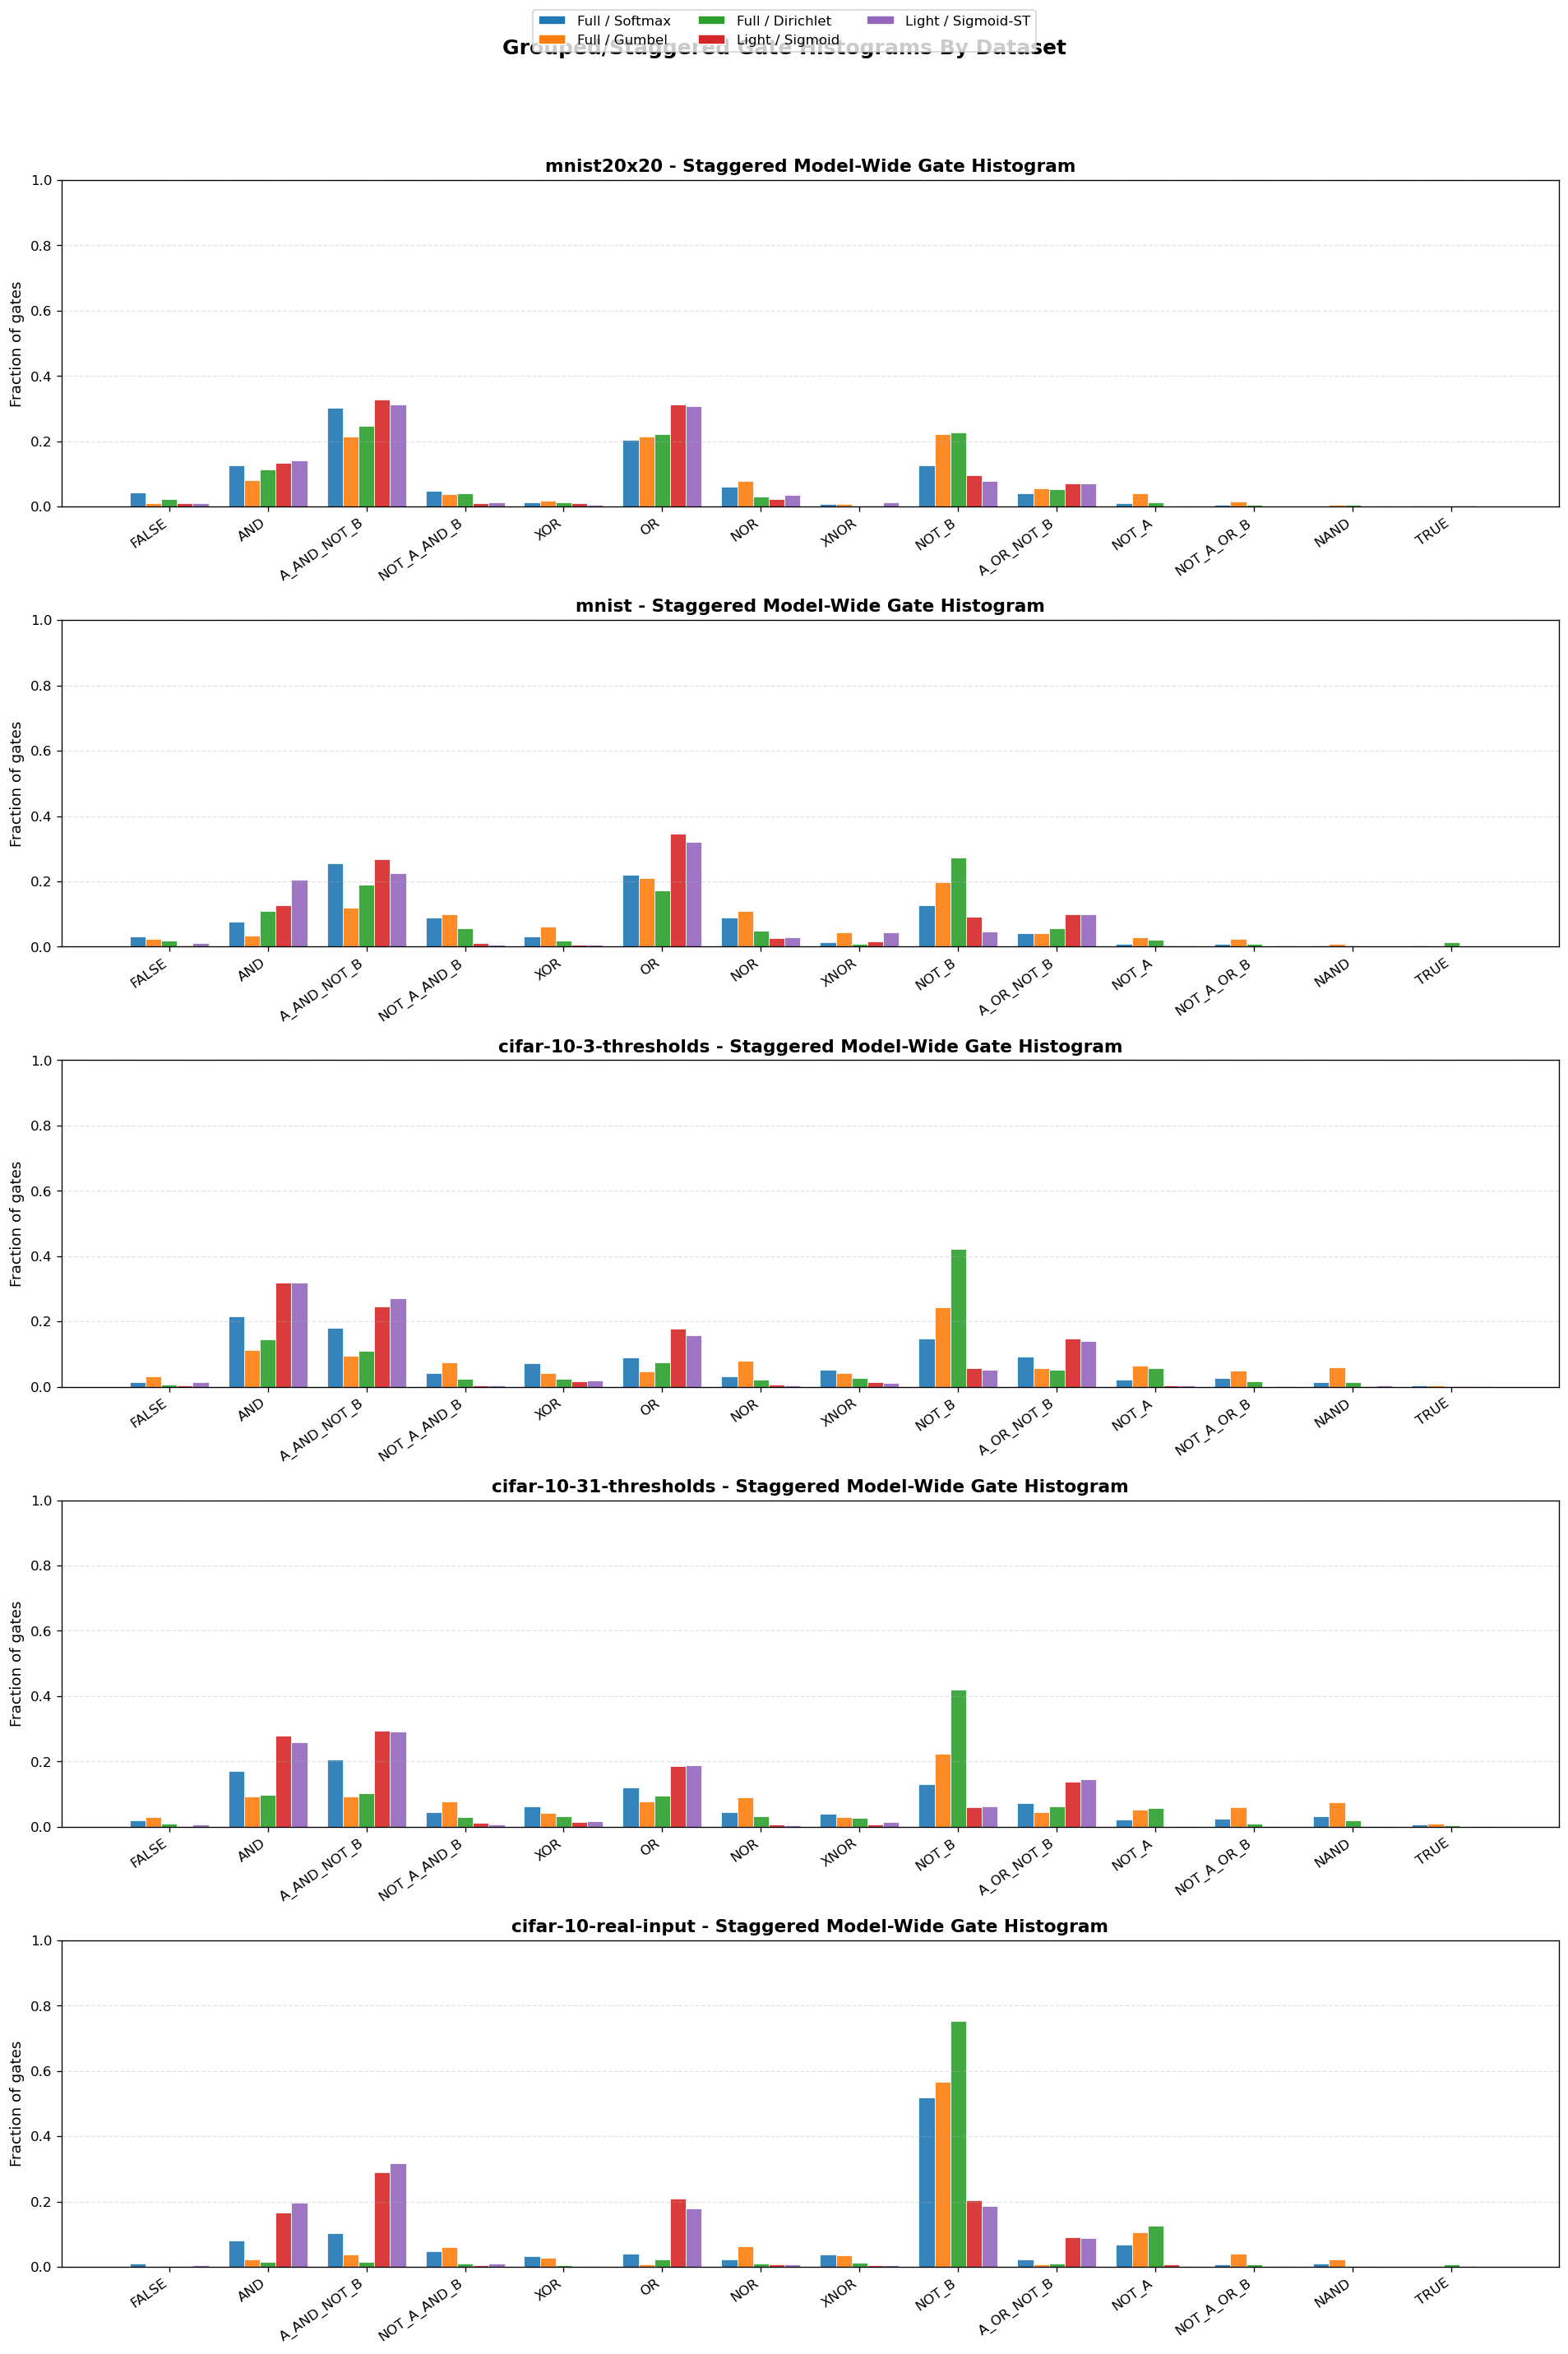

In [49]:
def plot_gate_ridgeline_histograms(
    checkpoint_dir: str | Path = "model_checkpoints",
    datasets: list[str] | None = None,
    normalize: bool = False,
    exclude_passthrough: bool = False,
    output_dir: str | Path | None = None,
    show: bool = True,
    ridge_gap: float = 1.15,          # vertical spacing between model ridges
    scale_each_ridge: bool = True,    # normalize each ridge to max=1 for shape comparison
    fill_alpha: float = 0.45,
    line_width: float = 1.5,
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from pathlib import Path

    runs_by_dataset = collect_model_wide_gate_counts(
        checkpoint_dir=checkpoint_dir,
        exclude_passthrough=exclude_passthrough,
    )

    if datasets is None:
        datasets = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
        datasets.extend(sorted(set(runs_by_dataset) - set(datasets)))

    gate_indices = list(range(len(GATE_NAMES)))
    if exclude_passthrough:
        gate_indices = [idx for idx in gate_indices if idx not in (3, 5)]

    gate_names = [GATE_NAMES[idx] for idx in gate_indices]
    x_vals = np.asarray(gate_indices, dtype=float)
    bins = np.arange(min(gate_indices) - 0.5, max(gate_indices) + 1.5, 1.0)

    n = len(datasets)
    fig, axes = plt.subplots(
        n, 1,
        figsize=(16, 3.5 * n + 1.0),
        dpi=120,
        squeeze=False,
    )
    axes = axes[:, 0]

    def _get_values(run):
        vals = run["gate_fractions"] if normalize else run["gate_counts"]
        return np.asarray(vals)[gate_indices].astype(float)

    for ax, dataset in zip(axes, datasets):
        runs = {run["model_key"]: run for run in runs_by_dataset.get(dataset, [])}
        model_keys_present = [mk for mk in MODEL_ORDER if mk in runs]

        if not model_keys_present:
            ax.set_visible(False)
            continue

        yticks = []
        yticklabels = []

        # draw bottom-to-top so legend order and visual order are stable
        for ridge_idx, model_key in enumerate(model_keys_present):
            run = runs[model_key]
            values = _get_values(run)

            # categorical histogram profile
            hist_counts, edges = np.histogram(
                x_vals,
                bins=bins,
                weights=values,
                density=False,
            )

            y = hist_counts.astype(float)

            # for raw counts, shape comparison is often clearer if each ridge is scaled
            if scale_each_ridge and y.max() > 0:
                y_plot = y / y.max()
            else:
                y_plot = y.copy()

            baseline = ridge_idx * ridge_gap

            ax.stairs(
                y_plot + baseline,
                edges=edges,
                baseline=baseline,
                fill=True,
                alpha=fill_alpha,
                color=MODEL_COLORS[model_key],
                linewidth=line_width,
            )
            ax.stairs(
                y_plot + baseline,
                edges=edges,
                baseline=None,
                fill=False,
                color=MODEL_COLORS[model_key],
                linewidth=line_width,
            )

            yticks.append(baseline + 0.45)
            yticklabels.append(MODEL_LABELS[model_key])

        ax.set_xticks(x_vals)
        ax.set_xticklabels(gate_names, rotation=35, ha="right")
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)

        ax.set_title(
            f"{dataset} - Ridgeline / Joy-Plot-Inspired Gate Profiles",
            fontsize=13,
            fontweight="bold",
        )
        ax.grid(True, axis="x", linestyle="--", alpha=0.20)
        ax.grid(True, axis="y", linestyle=":", alpha=0.15)

        ylabel = "Model"
        if normalize:
            xlabel = "Gate type (fractional profile)"
        elif scale_each_ridge:
            xlabel = "Gate type (shape-normalized profile)"
        else:
            xlabel = "Gate type (raw count profile)"

        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xlabel(xlabel, fontsize=11)

        top = (len(model_keys_present) - 1) * ridge_gap + 1.2
        ax.set_ylim(-0.1, top)

    legend_handles = [
        Patch(facecolor=MODEL_COLORS[mk], edgecolor="none", alpha=fill_alpha, label=MODEL_LABELS[mk])
        for mk in MODEL_ORDER
        if any(mk in {run["model_key"] for run in runs_by_dataset.get(ds, [])} for ds in datasets)
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=min(5, max(1, len(legend_handles))),
        frameon=True,
        bbox_to_anchor=(0.5, 0.995),
    )

    fig.suptitle(
        "Joy-Plot-Inspired Ridgeline Gate Histograms by Dataset",
        fontsize=15,
        fontweight="bold",
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        suffix = "fractional" if normalize else "counts"
        if scale_each_ridge and not normalize:
            suffix += "__shape_scaled"
        if exclude_passthrough:
            suffix += "__no_passthrough"
        out_path = output_dir / f"ridgeline_gate_histograms__{suffix}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    if show:
        plt.show()

    return fig, axes, runs_by_dataset

fig, axes, gate_runs = plot_staggered_gate_histograms(
    checkpoint_dir="model_checkpoints",
    normalize=True,
    exclude_passthrough=True,
    output_dir="checkpoint_plots",
    show=True,
)

saved /home/jared/git_local/Research/JAX_DLGN/checkpoint_plots/staggered_gate_histograms__fractional__no_passthrough.png


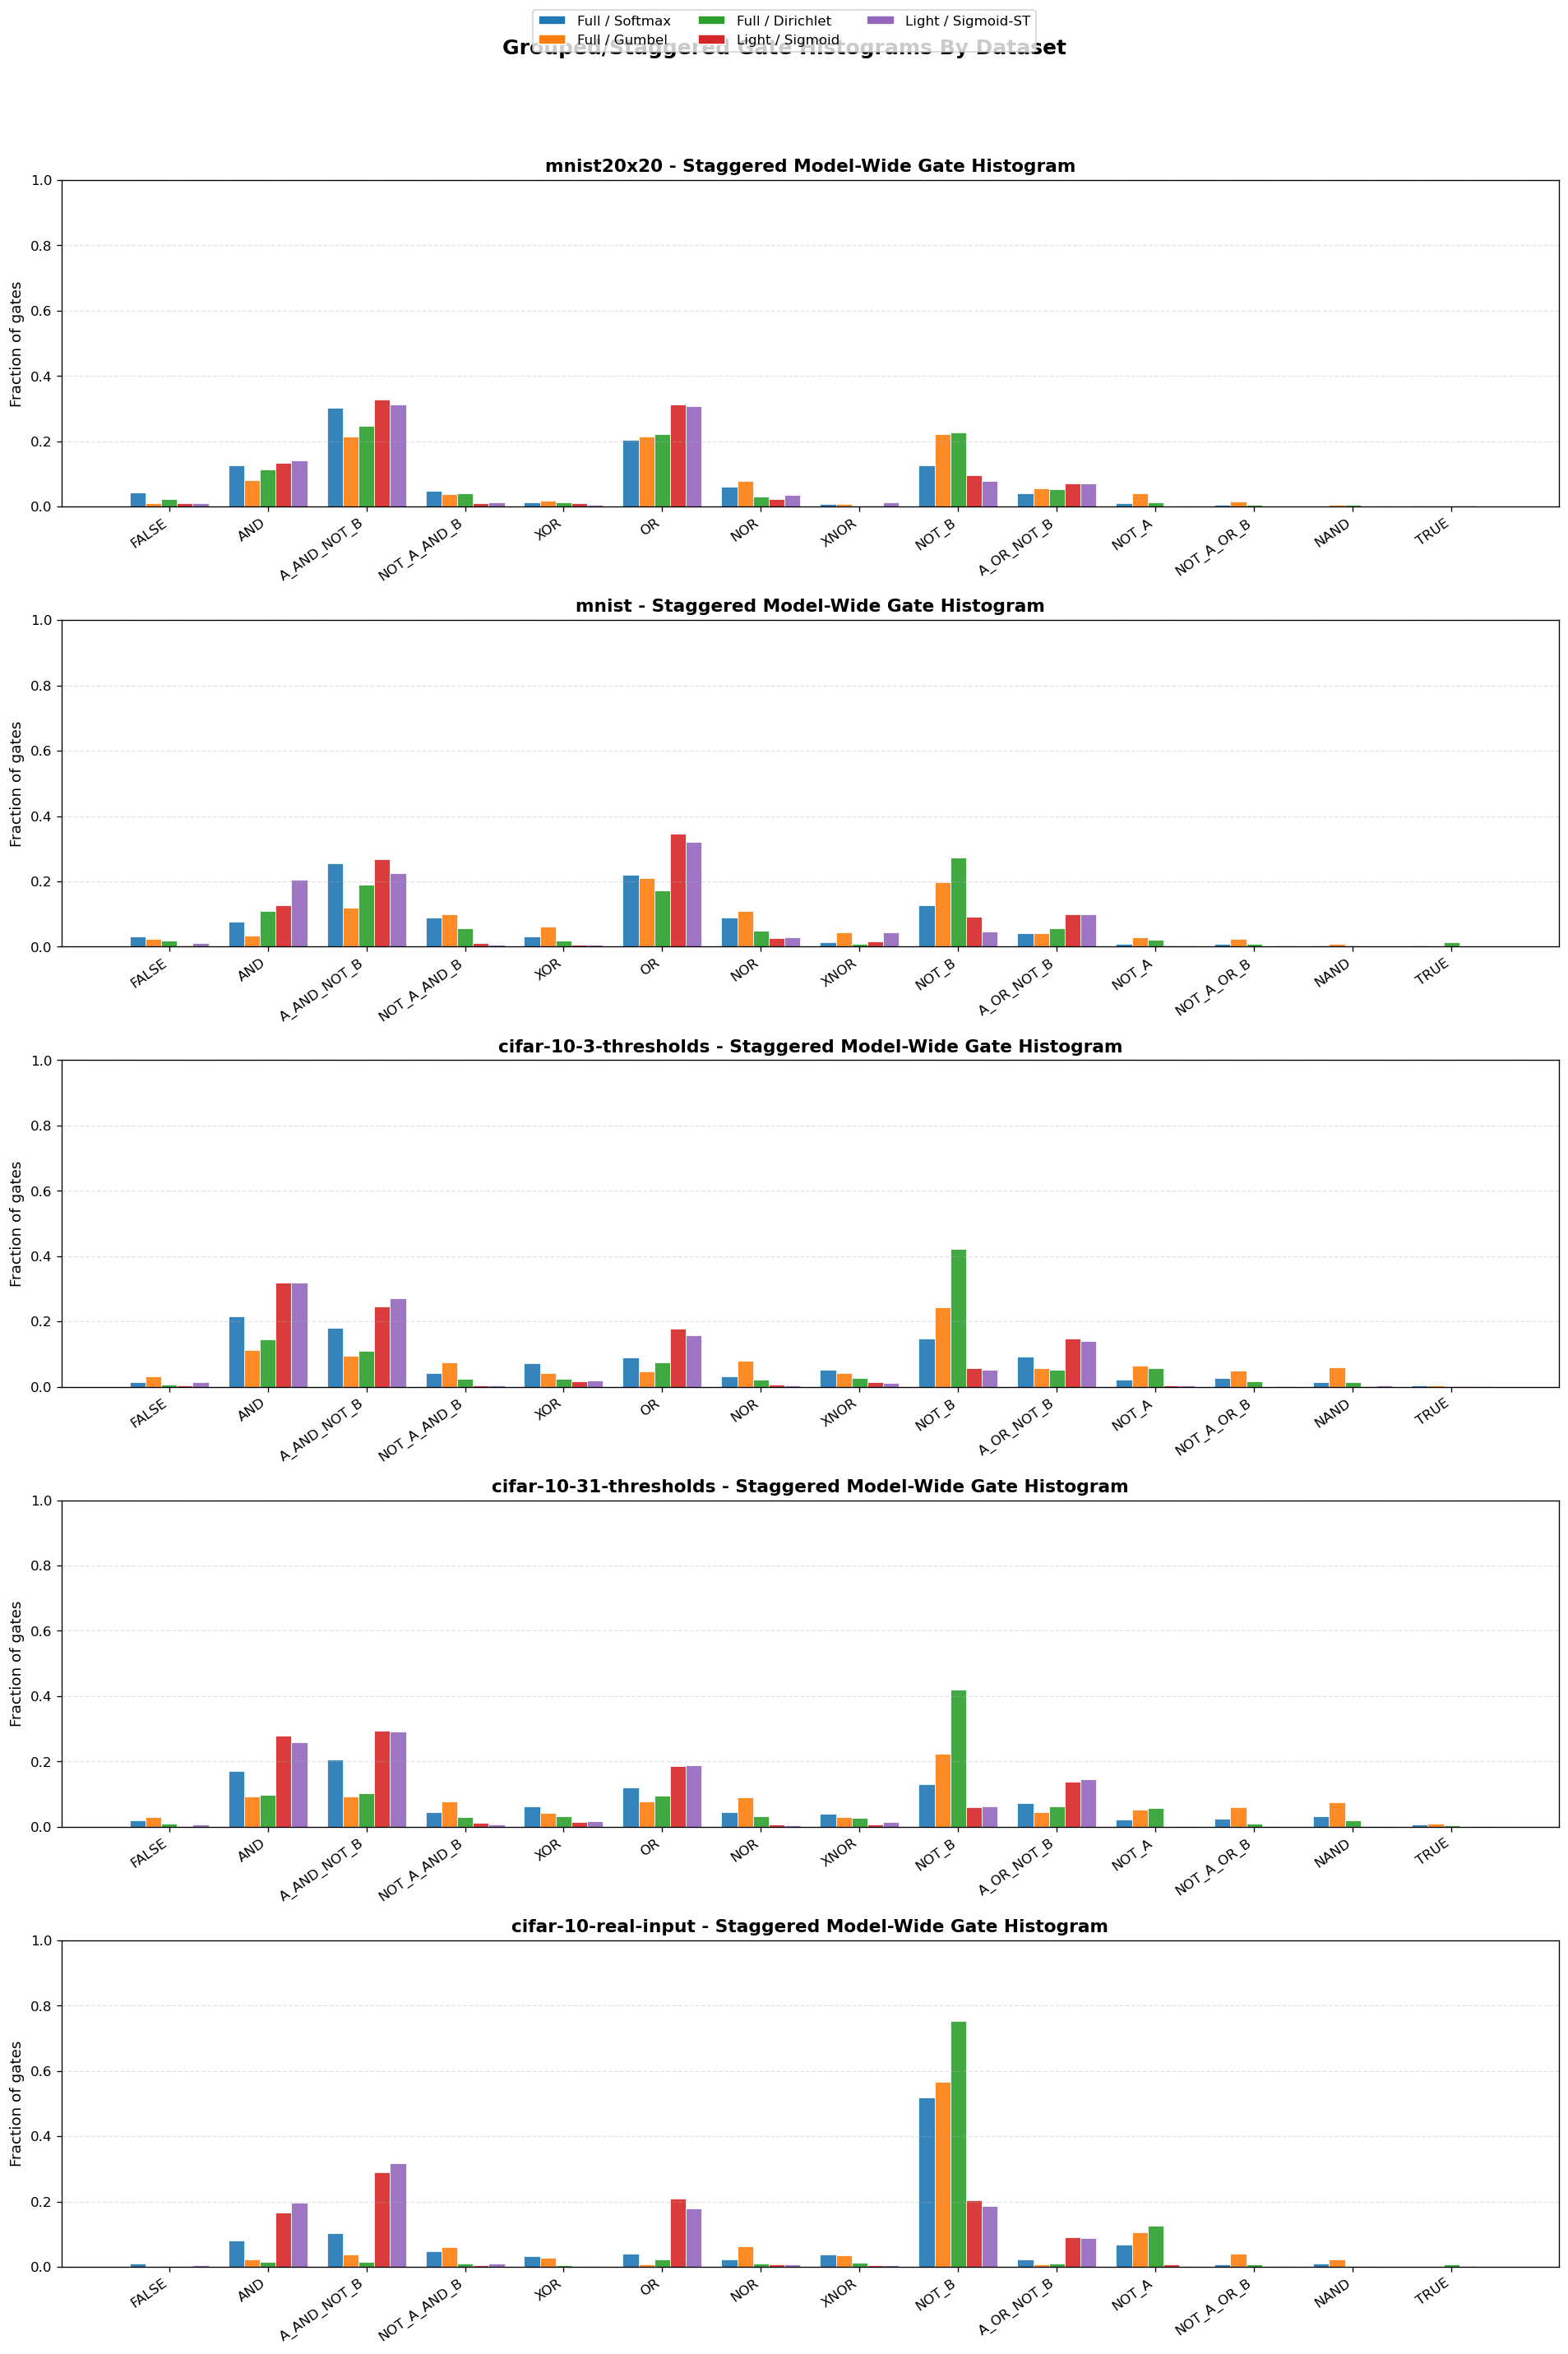

In [50]:
def plot_3d_isometric_gate_ridgelines(
    checkpoint_dir: str | Path = "model_checkpoints",
    datasets: list[str] | None = None,
    normalize: bool = False,
    exclude_passthrough: bool = False,
    output_dir: str | Path | None = None,
    show: bool = True,
    scale_each_model: bool = True,   # shape-normalize each model for readability
    elev: float = 28,
    azim: float = -58,
    ridge_depth: float = 0.72,       # thickness of each ridge slab in y
    fill_alpha: float = 0.55,
    line_width: float = 1.6,
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
    from pathlib import Path

    runs_by_dataset = collect_model_wide_gate_counts(
        checkpoint_dir=checkpoint_dir,
        exclude_passthrough=exclude_passthrough,
    )

    if datasets is None:
        datasets = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
        datasets.extend(sorted(set(runs_by_dataset) - set(datasets)))

    gate_indices = list(range(len(GATE_NAMES)))
    if exclude_passthrough:
        gate_indices = [idx for idx in gate_indices if idx not in (3, 5)]

    gate_names = [GATE_NAMES[idx] for idx in gate_indices]
    x = np.arange(len(gate_indices), dtype=float)

    n = len(datasets)
    fig = plt.figure(figsize=(18, 5.2 * n), dpi=120)
    axes = []

    def _get_values(run):
        vals = run["gate_fractions"] if normalize else run["gate_counts"]
        return np.asarray(vals)[gate_indices].astype(float)

    def _ridge_polygon_vertices(x_vals, z_vals, y_const):
        """
        Closed polygon in the x-z plane at fixed y.
        Starts at baseline, traces the profile, and returns to baseline.
        """
        verts = [(x_vals[0], y_const, 0.0)]
        verts.extend((xv, y_const, zv) for xv, zv in zip(x_vals, z_vals))
        verts.append((x_vals[-1], y_const, 0.0))
        return verts

    for i, dataset in enumerate(datasets, start=1):
        ax = fig.add_subplot(n, 1, i, projection="3d")
        axes.append(ax)

        runs = {run["model_key"]: run for run in runs_by_dataset.get(dataset, [])}
        model_keys_present = [mk for mk in MODEL_ORDER if mk in runs]

        if not model_keys_present:
            ax.set_visible(False)
            continue

        max_height = 0.0
        yticks = []
        yticklabels = []

        # draw back-to-front for slightly cleaner occlusion
        for y_idx, model_key in enumerate(reversed(model_keys_present)):
            run = runs[model_key]
            values = _get_values(run)

            z = values.copy()
            if scale_each_model and z.max() > 0:
                z_plot = z / z.max()
            else:
                z_plot = z

            y_center = float(y_idx)
            y_front = y_center - ridge_depth / 2.0
            y_back = y_center + ridge_depth / 2.0

            color = MODEL_COLORS[model_key]

            # top profile lines
            ax.plot(
                x, np.full_like(x, y_front), z_plot,
                color=color, linewidth=line_width
            )
            ax.plot(
                x, np.full_like(x, y_back), z_plot,
                color=color, linewidth=line_width * 0.9, alpha=0.9
            )

            # front filled curtain
            front_poly = Poly3DCollection(
                [_ridge_polygon_vertices(x, z_plot, y_front)],
                alpha=fill_alpha,
                facecolor=color,
                edgecolor=color,
                linewidth=line_width * 0.6,
            )
            ax.add_collection3d(front_poly)

            # back filled curtain
            back_poly = Poly3DCollection(
                [_ridge_polygon_vertices(x, z_plot, y_back)],
                alpha=fill_alpha * 0.55,
                facecolor=color,
                edgecolor=color,
                linewidth=line_width * 0.5,
            )
            ax.add_collection3d(back_poly)

            # side walls between front and back for each x-bin
            side_quads = []
            for j in range(len(x) - 1):
                quad = [
                    (x[j],     y_front, z_plot[j]),
                    (x[j + 1], y_front, z_plot[j + 1]),
                    (x[j + 1], y_back,  z_plot[j + 1]),
                    (x[j],     y_back,  z_plot[j]),
                ]
                side_quads.append(quad)

            if side_quads:
                side_poly = Poly3DCollection(
                    side_quads,
                    alpha=fill_alpha * 0.35,
                    facecolor=color,
                    edgecolor="none",
                )
                ax.add_collection3d(side_poly)

            # baseline lines
            ax.plot(x, np.full_like(x, y_front), np.zeros_like(x), color=color, linewidth=0.8, alpha=0.55)
            ax.plot(x, np.full_like(x, y_back), np.zeros_like(x), color=color, linewidth=0.8, alpha=0.35)

            yticks.append(y_center)
            yticklabels.append(MODEL_LABELS[model_key])
            max_height = max(max_height, float(np.max(z_plot)))

        ax.set_title(
            f"{dataset} - 3D Isometric Ridgeline Gate Profiles",
            fontsize=13,
            fontweight="bold",
            pad=16,
        )

        ax.set_xlim(x[0], x[-1])
        ax.set_ylim(-0.6, len(model_keys_present) - 0.4)
        ax.set_zlim(0.0, max(1.0 if scale_each_model else 0.0, max_height * 1.08))

        ax.set_xticks(x)
        ax.set_xticklabels(gate_names, rotation=30, ha="right")
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)
        ax.set_zlabel("Fraction" if normalize else ("Relative height" if scale_each_model else "Gate count"), labelpad=10)

        ax.view_init(elev=elev, azim=azim)

        # cleaner pane/grid styling
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.grid(True, alpha=0.18)

        # compress vertical exaggeration a bit for nicer isometric look
        try:
            ax.set_box_aspect((len(x) * 1.35, len(model_keys_present) * 1.0, max(2.2, max_height * 1.8)))
        except Exception:
            pass

    legend_handles = [
        Patch(facecolor=MODEL_COLORS[mk], edgecolor="none", alpha=fill_alpha, label=MODEL_LABELS[mk])
        for mk in MODEL_ORDER
        if any(mk in {run["model_key"] for run in runs_by_dataset.get(ds, [])} for ds in datasets)
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=min(5, max(1, len(legend_handles))),
        frameon=True,
        bbox_to_anchor=(0.5, 0.995),
    )

    fig.suptitle(
        "3D Isometric Ridgeline Gate Histograms by Dataset",
        fontsize=15,
        fontweight="bold",
        y=0.998,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.965))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        suffix = "fractional" if normalize else "counts"
        if scale_each_model and not normalize:
            suffix += "__shape_scaled"
        if exclude_passthrough:
            suffix += "__no_passthrough"
        out_path = output_dir / f"gate_ridgelines_3d_isometric__{suffix}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    if show:
        plt.show()

    return fig, axes, runs_by_dataset

fig, axes, gate_runs = plot_staggered_gate_histograms(
    checkpoint_dir="model_checkpoints",
    normalize=True,
    exclude_passthrough=True,
    output_dir="checkpoint_plots",
    show=True,
)

/tmp/ipykernel_115193/3145925300.py:568: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=(0, 0, 1, 0.95))


saved /home/jared/git_local/Research/JAX_DLGN/checkpoint_plots/gate_histograms_3d__fractional__no_passthrough.png


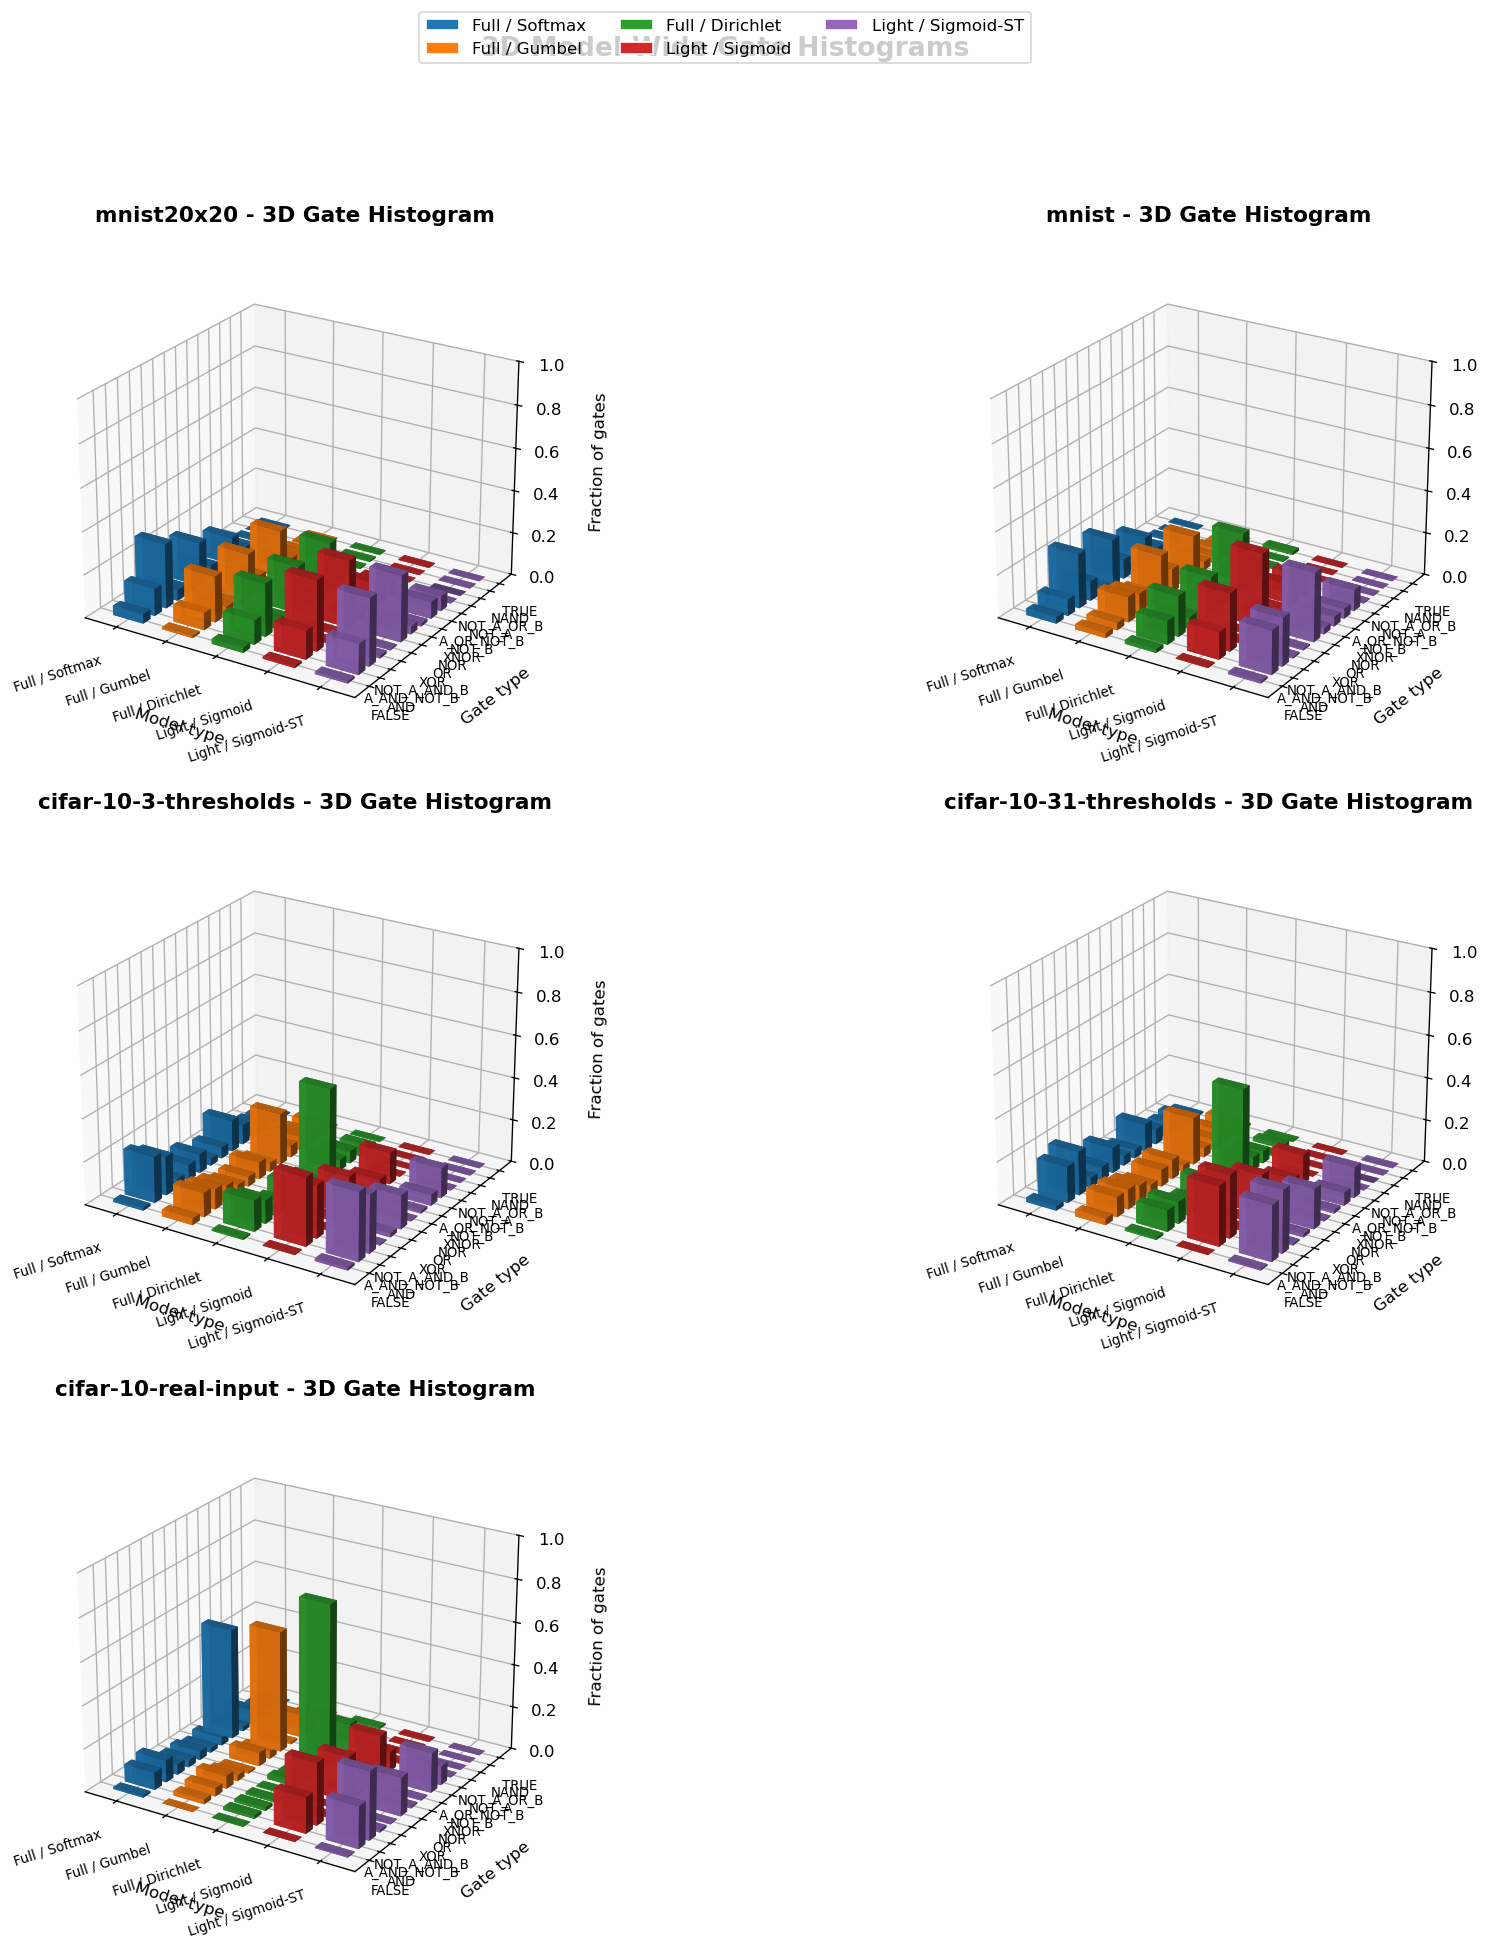

In [51]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import pickle

import numpy as np


DATASET_ORDER = [
    "mnist20x20",
    "mnist",
    "cifar-10-3-thresholds",
    "cifar-10-31-thresholds",
    "cifar-10-real-input",
]

MODEL_ORDER = [
    ("full", "softmax"),
    ("full", "gumbel"),
    ("full", "dirichlet"),
    ("light", "light_sigmoid"),
    ("light", "light_st"),
]

MODEL_LABELS = {
    ("full", "softmax"): "Full / Softmax",
    ("full", "gumbel"): "Full / Gumbel",
    ("full", "dirichlet"): "Full / Dirichlet",
    ("light", "light_sigmoid"): "Light / Sigmoid",
    ("light", "light_st"): "Light / Sigmoid-ST",
}

MODEL_COLORS = {
    ("full", "softmax"): "#1f77b4",
    ("full", "gumbel"): "#ff7f0e",
    ("full", "dirichlet"): "#2ca02c",
    ("light", "light_sigmoid"): "#d62728",
    ("light", "light_st"): "#9467bd",
}

GATE_NAMES = [
    "FALSE",
    "AND",
    "A_AND_NOT_B",
    "A",
    "NOT_A_AND_B",
    "B",
    "XOR",
    "OR",
    "NOR",
    "XNOR",
    "NOT_B",
    "A_OR_NOT_B",
    "NOT_A",
    "NOT_A_OR_B",
    "NAND",
    "TRUE",
]

TRUTH_TABLE_BIT_WEIGHTS = np.asarray([8, 4, 2, 1], dtype=np.int32)


def load_pickle_checkpoint(path: str | Path) -> dict:
    path = Path(path)
    with path.open("rb") as f:
        return pickle.load(f)


def _nan_array(values, length: int) -> np.ndarray:
    arr = np.full(length, np.nan, dtype=float)
    for idx, value in enumerate(values[:length]):
        if value is not None:
            arr[idx] = float(value)
    return arr


def _sample_history_on_eval_grid(payload: dict) -> dict:
    history = payload["history"]
    config = payload["config"]
    dataset_info = payload["dataset_info"]

    steps = list(history["steps"])
    train_soft = list(history["train_soft_loss"])
    train_hard = list(history["train_hard_loss"])
    valid_hard = list(history["valid_hard_acc"])
    test_hard = list(history["test_hard_acc"])

    if not steps:
        raise ValueError("Checkpoint history is empty")

    eval_every = int(config.get("eval_every", 100))
    last_step = int(steps[-1])
    eval_indices = [
        idx
        for idx, step in enumerate(steps)
        if (int(step) % eval_every == 0) or (int(step) == last_step)
    ]

    aligned_len = min(
        len(eval_indices),
        len(valid_hard),
        len(test_hard),
    )
    if aligned_len == 0:
        raise ValueError("Could not align train/eval history for plotting")

    eval_indices = eval_indices[:aligned_len]
    eval_steps = np.asarray([int(steps[idx]) for idx in eval_indices], dtype=int)

    sampled_soft = np.asarray([float(train_soft[idx]) for idx in eval_indices], dtype=float)
    sampled_hard = np.asarray([float(train_hard[idx]) for idx in eval_indices], dtype=float)
    valid_hard = _nan_array(valid_hard, aligned_len)
    test_hard = _nan_array(test_hard, aligned_len)

    logic_family = str(dataset_info["logic_family"])
    architecture = str(config["architecture"])

    return {
        "dataset": str(dataset_info["dataset"]),
        "logic_family": logic_family,
        "architecture": architecture,
        "model_key": (logic_family, architecture),
        "label": MODEL_LABELS.get((logic_family, architecture), f"{logic_family} / {architecture}"),
        "color": MODEL_COLORS.get((logic_family, architecture), None),
        "eval_steps": eval_steps,
        "sampled_train_soft_loss": sampled_soft,
        "sampled_train_hard_loss": sampled_hard,
        "valid_hard_acc": valid_hard,
        "test_hard_acc": test_hard,
        "path": str(payload.get("_source_path", "")),
    }


def collect_runs(checkpoint_dir: str | Path = "model_checkpoints") -> dict[str, list[dict]]:
    checkpoint_dir = Path(checkpoint_dir)
    if not checkpoint_dir.exists():
        raise FileNotFoundError(f"Checkpoint directory does not exist: {checkpoint_dir}")

    runs_by_dataset: dict[str, list[dict]] = defaultdict(list)

    for path in sorted(checkpoint_dir.glob("*.pkl")):
        if path.name == "monkey_patch_sweep_results.jsonl":
            continue

        payload = load_pickle_checkpoint(path)
        payload["_source_path"] = str(path)
        run = _sample_history_on_eval_grid(payload)
        runs_by_dataset[run["dataset"]].append(run)

    for dataset, runs in runs_by_dataset.items():
        runs.sort(key=lambda run: MODEL_ORDER.index(run["model_key"]) if run["model_key"] in MODEL_ORDER else 999)

    return runs_by_dataset


def _sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def _hard_gate_ids_from_layer(layer_params: np.ndarray, logic_family: str) -> np.ndarray:
    layer_params = np.asarray(layer_params)
    if layer_params.ndim != 2:
        raise ValueError(f"Expected rank-2 layer params, got shape {layer_params.shape}")

    if logic_family == "full":
        if layer_params.shape[1] != 16:
            raise ValueError(f"Expected full-gate layer shape (_, 16), got {layer_params.shape}")
        return np.asarray(np.argmax(layer_params, axis=-1), dtype=np.int32)

    if logic_family == "light":
        if layer_params.shape[1] != 4:
            raise ValueError(f"Expected light-gate layer shape (_, 4), got {layer_params.shape}")
        hard_bits = (_sigmoid(layer_params) >= 0.5).astype(np.int32)
        return np.asarray(np.sum(hard_bits * TRUTH_TABLE_BIT_WEIGHTS, axis=-1), dtype=np.int32)

    raise ValueError(f"Unknown logic_family: {logic_family!r}")


def collect_model_wide_gate_counts(
    checkpoint_dir: str | Path = "model_checkpoints",
    exclude_passthrough: bool = False,
) -> dict[str, list[dict]]:
    checkpoint_dir = Path(checkpoint_dir)
    if not checkpoint_dir.exists():
        raise FileNotFoundError(f"Checkpoint directory does not exist: {checkpoint_dir}")

    runs_by_dataset: dict[str, list[dict]] = defaultdict(list)

    for path in sorted(checkpoint_dir.glob("*.pkl")):
        payload = load_pickle_checkpoint(path)
        params = payload.get("params")
        if params is None and "state" in payload:
            params = getattr(payload["state"], "params", None)
        if params is None:
            continue

        dataset_info = payload.get("dataset_info", {})
        config = payload.get("config", {})
        dataset = str(dataset_info.get("dataset", config.get("dataset")))
        logic_family = str(dataset_info.get("logic_family", config.get("logic_family", "full")))
        architecture = str(config.get("architecture", "unknown"))
        model_key = (logic_family, architecture)

        all_gate_ids = []
        for layer_params in params:
            gate_ids = _hard_gate_ids_from_layer(np.asarray(layer_params), logic_family)
            all_gate_ids.append(gate_ids.reshape(-1))

        if not all_gate_ids:
            continue

        flat_gate_ids = np.concatenate(all_gate_ids, axis=0)
        if exclude_passthrough:
            flat_gate_ids = flat_gate_ids[(flat_gate_ids != 3) & (flat_gate_ids != 5)]

        gate_counts = np.bincount(flat_gate_ids, minlength=len(GATE_NAMES)).astype(float)
        total_gates = float(gate_counts.sum())

        runs_by_dataset[dataset].append({
            "dataset": dataset,
            "logic_family": logic_family,
            "architecture": architecture,
            "model_key": model_key,
            "label": MODEL_LABELS.get(model_key, f"{logic_family} / {architecture}"),
            "color": MODEL_COLORS.get(model_key),
            "gate_counts": gate_counts,
            "gate_fractions": np.zeros_like(gate_counts) if total_gates == 0 else gate_counts / total_gates,
            "total_gates": total_gates,
            "path": str(path),
        })

    for dataset, runs in runs_by_dataset.items():
        runs.sort(key=lambda run: MODEL_ORDER.index(run["model_key"]) if run["model_key"] in MODEL_ORDER else 999)

    return runs_by_dataset


def _add_model_and_style_legends(ax, handles_for_models, primary_label: str, secondary_label: str):
    from matplotlib.lines import Line2D

    metric_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label=primary_label),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label=secondary_label),
    ]
    legend_models = ax.legend(
        handles=handles_for_models,
        loc="best",
        fontsize=9,
        frameon=True,
    )
    ax.add_artist(legend_models)
    ax.legend(handles=metric_handles, loc="lower right", fontsize=9, frameon=True)


def plot_dataset_results(dataset: str, runs: list[dict], output_dir: str | Path | None = None):
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=120)
    ax_loss, ax_acc = axes

    model_handles = []
    for run in runs:
        color = run["color"]
        label = run["label"]
        steps = run["eval_steps"]

        ax_loss.plot(
            steps,
            run["sampled_train_soft_loss"],
            color=color,
            linestyle="-",
            linewidth=2.2,
            alpha=0.95,
        )
        ax_loss.plot(
            steps,
            run["sampled_train_hard_loss"],
            color=color,
            linestyle="--",
            linewidth=2.2,
            alpha=0.95,
        )

        ax_acc.plot(
            steps,
            run["valid_hard_acc"],
            color=color,
            linestyle="-",
            linewidth=2.2,
            alpha=0.95,
        )
        ax_acc.plot(
            steps,
            run["test_hard_acc"],
            color=color,
            linestyle="--",
            linewidth=2.2,
            alpha=0.95,
        )

        model_handles.append(Line2D([0], [0], color=color, linewidth=2.5, label=label))

    ax_loss.set_title(f"{dataset} - Losses On Eval Grid", fontsize=13, fontweight="bold")
    ax_loss.set_xlabel("Training Step", fontsize=11)
    ax_loss.set_ylabel("Loss", fontsize=11)
    ax_loss.grid(True, linestyle="--", alpha=0.4)

    ax_acc.set_title(f"{dataset} - Hard Accuracy", fontsize=13, fontweight="bold")
    ax_acc.set_xlabel("Training Step", fontsize=11)
    ax_acc.set_ylabel("Accuracy", fontsize=11)
    ax_acc.set_ylim(0.0, 1.0)
    ax_acc.grid(True, linestyle="--", alpha=0.4)

    _add_model_and_style_legends(
        ax_loss,
        model_handles,
        primary_label="Train soft loss",
        secondary_label="Train hard loss",
    )

    acc_style_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="Validation hard acc"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Test hard acc"),
    ]
    legend_models = ax_acc.legend(
        handles=model_handles,
        loc="best",
        fontsize=9,
        frameon=True,
    )
    ax_acc.add_artist(legend_models)
    ax_acc.legend(handles=acc_style_handles, loc="lower right", fontsize=9, frameon=True)

    fig.suptitle(f"Checkpoint Sweep Comparison: {dataset}", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        out_path = output_dir / f"{dataset.replace('/', '_')}__comparison.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    return fig, axes


def plot_all_datasets(
    checkpoint_dir: str | Path = "model_checkpoints",
    output_dir: str | Path | None = None,
    show: bool = True,
):
    import matplotlib.pyplot as plt

    runs_by_dataset = collect_runs(checkpoint_dir)
    figures = []

    dataset_names = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
    dataset_names.extend(sorted(set(runs_by_dataset) - set(dataset_names)))

    for dataset in dataset_names:
        fig, axes = plot_dataset_results(dataset, runs_by_dataset[dataset], output_dir=output_dir)
        figures.append((dataset, fig, axes))

    if show:
        plt.show()

    return figures, runs_by_dataset


def plot_stacked_gate_histograms(
    checkpoint_dir: str | Path = "model_checkpoints",
    datasets: list[str] | None = None,
    normalize: bool = False,
    exclude_passthrough: bool = False,
    output_dir: str | Path | None = None,
    show: bool = True,
):
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    runs_by_dataset = collect_model_wide_gate_counts(
        checkpoint_dir=checkpoint_dir,
        exclude_passthrough=exclude_passthrough,
    )

    if datasets is None:
        datasets = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
        datasets.extend(sorted(set(runs_by_dataset) - set(datasets)))

    gate_indices = list(range(len(GATE_NAMES)))
    if exclude_passthrough:
        gate_indices = [idx for idx in gate_indices if idx not in (3, 5)]

    n = len(datasets)
    fig, axes = plt.subplots(n, 1, figsize=(13, 4.5 * n), dpi=120, squeeze=False)
    axes = axes[:, 0]

    cmap = plt.get_cmap("tab20")
    gate_colors = {
        gate_idx: cmap(i % 20)
        for i, gate_idx in enumerate(gate_indices)
    }

    for ax, dataset in zip(axes, datasets):
        runs = {run["model_key"]: run for run in runs_by_dataset.get(dataset, [])}
        x = np.arange(len(MODEL_ORDER))

        matrix = np.zeros((len(MODEL_ORDER), len(gate_indices)), dtype=float)
        for model_idx, model_key in enumerate(MODEL_ORDER):
            run = runs.get(model_key)
            if run is None:
                continue
            values = run["gate_fractions"] if normalize else run["gate_counts"]
            matrix[model_idx, :] = values[gate_indices]

        bottom = np.zeros(len(MODEL_ORDER), dtype=float)
        for gate_column, gate_idx in enumerate(gate_indices):
            heights = matrix[:, gate_column]
            ax.bar(
                x,
                heights,
                bottom=bottom,
                width=0.78,
                color=gate_colors[gate_idx],
                edgecolor="white",
                linewidth=0.4,
                label=GATE_NAMES[gate_idx],
            )
            bottom += heights

        ax.set_xticks(x)
        ax.set_xticklabels(
            [MODEL_LABELS[model_key] for model_key in MODEL_ORDER],
            rotation=18,
            ha="right",
        )
        ax.set_title(f"{dataset} - Model-Wide Gate Usage", fontsize=13, fontweight="bold")
        ax.set_ylabel("Fraction of gates" if normalize else "Gate count", fontsize=11)
        ax.grid(True, axis="y", linestyle="--", alpha=0.35)
        if normalize:
            ax.set_ylim(0.0, 1.0)

    legend_handles = [
        Patch(facecolor=gate_colors[gate_idx], edgecolor="white", label=GATE_NAMES[gate_idx])
        for gate_idx in gate_indices
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=4,
        frameon=True,
        bbox_to_anchor=(0.5, 0.995),
    )
    fig.suptitle("Stacked Model-Wide Gate Histograms", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.94))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        suffix = "fractional" if normalize else "counts"
        if exclude_passthrough:
            suffix += "__no_passthrough"
        out_path = output_dir / f"stacked_gate_histograms__{suffix}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    if show:
        plt.show()

    return fig, axes, runs_by_dataset


def plot_3d_gate_histograms(
    checkpoint_dir: str | Path = "model_checkpoints",
    datasets: list[str] | None = None,
    normalize: bool = False,
    exclude_passthrough: bool = False,
    output_dir: str | Path | None = None,
    show: bool = True,
    elev: float = 24.0,
    azim: float = -58.0,
):
    import math
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    runs_by_dataset = collect_model_wide_gate_counts(
        checkpoint_dir=checkpoint_dir,
        exclude_passthrough=exclude_passthrough,
    )

    if datasets is None:
        datasets = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
        datasets.extend(sorted(set(runs_by_dataset) - set(datasets)))

    gate_indices = list(range(len(GATE_NAMES)))
    if exclude_passthrough:
        gate_indices = [idx for idx in gate_indices if idx not in (3, 5)]

    n = len(datasets)
    ncols = 1 if n == 1 else 2
    nrows = math.ceil(n / ncols)
    fig = plt.figure(figsize=(18, 6 * nrows), dpi=120)

    dx = 0.62
    dy = 0.62

    for subplot_idx, dataset in enumerate(datasets, start=1):
        ax = fig.add_subplot(nrows, ncols, subplot_idx, projection="3d")
        runs = {run["model_key"]: run for run in runs_by_dataset.get(dataset, [])}

        for model_idx, model_key in enumerate(MODEL_ORDER):
            run = runs.get(model_key)
            if run is None:
                continue

            values = run["gate_fractions"] if normalize else run["gate_counts"]
            heights = np.asarray(values[gate_indices], dtype=float)

            x_positions = np.full(len(gate_indices), model_idx, dtype=float)
            y_positions = np.arange(len(gate_indices), dtype=float)
            z_positions = np.zeros(len(gate_indices), dtype=float)

            ax.bar3d(
                x_positions,
                y_positions,
                z_positions,
                dx,
                dy,
                heights,
                color=MODEL_COLORS[model_key],
                alpha=0.88,
                shade=True,
            )

        ax.set_title(f"{dataset} - 3D Gate Histogram", fontsize=13, fontweight="bold", pad=18)
        ax.set_xlabel("Model type", labelpad=10)
        ax.set_ylabel("Gate type", labelpad=12)
        ax.set_zlabel("Fraction of gates" if normalize else "Gate count", labelpad=10)
        ax.set_xticks(np.arange(len(MODEL_ORDER)) + dx / 2)
        ax.set_xticklabels(
            [MODEL_LABELS[model_key] for model_key in MODEL_ORDER],
            rotation=18,
            ha="right",
            fontsize=8,
        )
        ax.set_yticks(np.arange(len(gate_indices)) + dy / 2)
        ax.set_yticklabels([GATE_NAMES[idx] for idx in gate_indices], fontsize=8)
        if normalize:
            ax.set_zlim(0.0, 1.0)
        ax.view_init(elev=elev, azim=azim)

    legend_handles = [
        Patch(facecolor=MODEL_COLORS[model_key], edgecolor="white", label=MODEL_LABELS[model_key])
        for model_key in MODEL_ORDER
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, 0.995),
    )
    fig.suptitle("3D Model-Wide Gate Histograms", fontsize=16, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        suffix = "fractional" if normalize else "counts"
        if exclude_passthrough:
            suffix += "__no_passthrough"
        out_path = output_dir / f"gate_histograms_3d__{suffix}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    if show:
        plt.show()

    return fig, runs_by_dataset


fig, gate_runs = plot_3d_gate_histograms(
    checkpoint_dir="model_checkpoints",
    normalize=True,
    exclude_passthrough=True,
    output_dir="checkpoint_plots",
    show=True,
)

In [52]:
# https://stackoverflow.com/questions/77302431/how-to-draw-3d-histograms-in-plotly #I WANT THIS

In [8]:
import copy
import json as pyjson
import math
import time
import traceback
from pathlib import Path


MONKEY_BASE_CONFIG = {
    'dataset': 'toy_xor',
    'seed': 0,
    'batch_size': 128,
    'valid_set_size': 0.1,
    'num_workers': 0,
    'num_steps': 1200,
    'eval_every': 100,
    'learning_rate': 0.03,
    'weight_decay': 1e-4,
    'clip_value': 100.0,
    'connections': 'random',
    'logic_family': 'full',
    'architecture': 'softmax',
    'gumb_tau': 1.0,
    'dirichlet_concentration': 12.0,
    'sum_tau': 10.0,
    'num_neurons': 8,
    'num_layers': 3,
    'toy_num_bits': 6,
    'data_roots': {
        'block': './blocks_dataset',
        'uci': './data-uci',
        'mnist': './data-mnist',
        'cifar': './data-cifar',
    },
}


def _install_real_input_cifar_monkey_patch():
    base_loader = globals().get('_base_load_dataset_for_monkey_patch', load_dataset)
    globals()['_base_load_dataset_for_monkey_patch'] = base_loader

    def load_dataset_monkey_patched(config: dict):
        dataset = config['dataset']
        if dataset != 'cifar-10-real-input':
            return base_loader(config)

        batch_size = config['batch_size']
        valid_set_size = config.get('valid_set_size', 0.0)
        seed = config['seed']
        num_workers = config.get('num_workers', 0)
        data_roots = config.get(
            'data_roots',
            {
                'block': './blocks_dataset',
                'uci': './data-uci',
                'mnist': './data-mnist',
                'cifar': './data-cifar',
            },
        )

        torchvision = _require_module('torchvision', 'torchvision')
        transforms = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Lambda(lambda x: x.numpy().astype(np.float32)),
        ])
        train_set = torchvision.datasets.CIFAR10(
            data_roots['cifar'],
            train=True,
            download=True,
            transform=transforms,
        )
        test_set = torchvision.datasets.CIFAR10(
            data_roots['cifar'],
            train=False,
            download=True,
            transform=transforms,
        )
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    globals()['load_dataset'] = load_dataset_monkey_patched


def _dataset_neurons(dataset: str) -> int:
    return 12000 if dataset == 'mnist20x20' else 12000


def _logic_architectures(logic_family: str) -> list[str]:
    if logic_family == 'full':
        return ['softmax', 'gumbel', 'dirichlet']
    if logic_family == 'light':
        return ['light_sigmoid', 'light_st']
    raise ValueError(f'Unknown logic_family: {logic_family!r}')


def build_monkey_sweep_configs(base_config: dict) -> list[dict]:
    datasets = [
        'mnist20x20',
        'mnist',
        'cifar-10-3-thresholds',
        'cifar-10-31-thresholds',
        'cifar-10-real-input',
    ]

    configs = []
    for dataset in datasets:
        for logic_family in ['full', 'light']:
            for architecture in _logic_architectures(logic_family):
                run_config = copy.deepcopy(base_config)
                run_config.update({
                    'dataset': dataset,
                    'batch_size': 1024,
                    'num_steps': 5000,
                    'logic_family': logic_family,
                    'architecture': architecture,
                    'num_neurons': _dataset_neurons(dataset),
                    'num_layers': 8,
                    'connections': 'random',
                })
                configs.append(run_config)
    return configs


def make_monkey_run_name(run_config: dict) -> str:
    return (
        f"{run_config['dataset']}"
        f"__{run_config['logic_family']}"
        f"__{run_config['architecture']}"
        f"__L{run_config['num_layers']}"
        f"__N{run_config['num_neurons']}"
        f"__BS{run_config['batch_size']}"
        f"__steps{run_config['num_steps']}"
        f"__seed{run_config['seed']}"
    )


def run_monkey_patch_sweep(
    base_config: dict | None = None,
    checkpoint_dir: str | Path = 'model_checkpoints',
    save_failures: bool = True,
):
    if base_config is None:
        base_config = MONKEY_BASE_CONFIG

    _install_real_input_cifar_monkey_patch()

    all_configs = build_monkey_sweep_configs(base_config)
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    summary_path = checkpoint_dir / 'monkey_patch_sweep_results.jsonl'
    results = []

    for run_index, run_config in enumerate(all_configs, start=1):
        run_name = make_monkey_run_name(run_config)
        run_header = f'[{run_index:02d}/{len(all_configs):02d}] {run_name}'
        print(f"\n=== {run_header} ===")
        print({
            'dataset': run_config['dataset'],
            'logic_family': run_config['logic_family'],
            'architecture': run_config['architecture'],
            'batch_size': run_config['batch_size'],
            'num_steps': run_config['num_steps'],
            'num_neurons': run_config['num_neurons'],
            'num_layers': run_config['num_layers'],
            'valid_set_size': run_config['valid_set_size'],
            'gumb_tau': run_config['gumb_tau'],
            'sum_tau': run_config['sum_tau'],
            'learning_rate': run_config['learning_rate'],
            'seed': run_config['seed'],
        })

        start_time = time.perf_counter()
        result_record = {
            'run_name': run_name,
            'status': 'started',
            'config': copy.deepcopy(run_config),
        }

        try:
            state, wires, history, dataset_info, validation_loader, test_loader = train_model(run_config)
            elapsed_seconds = time.perf_counter() - start_time

            test_metrics = evaluate_loader(
                state.params,
                wires,
                test_loader,
                run_config,
                dataset_info['class_count'],
            )
            valid_metrics = evaluate_loader(
                state.params,
                wires,
                validation_loader,
                run_config,
                dataset_info['class_count'],
            )

            ckpt_path = checkpoint_dir / f'{run_name}.pkl'
            save_checkpoint(
                ckpt_path,
                state,
                wires,
                run_config,
                history,
                dataset_info,
                extra={
                    'elapsed_seconds': elapsed_seconds,
                    'test_metrics': test_metrics,
                    'valid_metrics': valid_metrics,
                },
            )

            result_record.update({
                'status': 'ok',
                'elapsed_seconds': elapsed_seconds,
                'dataset_info': dataset_info,
                'valid_metrics': valid_metrics,
                'test_metrics': test_metrics,
                'checkpoint': str(ckpt_path),
                'last_train_soft_loss': None if not history['train_soft_loss'] else history['train_soft_loss'][-1],
                'last_train_hard_loss': None if not history['train_hard_loss'] else history['train_hard_loss'][-1],
            })
            print(
                f"completed elapsed={elapsed_seconds:.2f}s "
                f"valid={valid_metrics} test={test_metrics}"
            )
        except Exception as exc:
            elapsed_seconds = time.perf_counter() - start_time
            result_record.update({
                'status': 'error',
                'elapsed_seconds': elapsed_seconds,
                'error_type': type(exc).__name__,
                'error_message': str(exc),
                'traceback': traceback.format_exc(),
            })
            print(f'run failed after {elapsed_seconds:.2f}s: {type(exc).__name__}: {exc}')

            if save_failures:
                failure_path = checkpoint_dir / f'{run_name}__FAILED.json'
                failure_path.write_text(pyjson.dumps(result_record, indent=2))
                result_record['failure_record'] = str(failure_path)
        finally:
            results.append(result_record)
            with summary_path.open('a', encoding='utf-8') as f:
                f.write(pyjson.dumps(result_record) + '\n')
            jax.clear_caches()
            print('jax caches cleared')

    return results


# Execute when ready:
monkey_results = run_monkey_patch_sweep()


=== [01/25] mnist20x20__full__softmax__L8__N12000__BS1024__steps5000__seed0 ===
{'dataset': 'mnist20x20', 'logic_family': 'full', 'architecture': 'softmax', 'batch_size': 1024, 'num_steps': 5000, 'num_neurons': 12000, 'num_layers': 8, 'valid_set_size': 0.1, 'gumb_tau': 1.0, 'sum_tau': 10.0, 'learning_rate': 0.03, 'seed': 0}
step=00000 soft_loss=2.906081 hard_loss=2.912616 valid_hard_acc=0.0778 test_hard_acc=0.0764
step=00100 soft_loss=0.488996 hard_loss=2.906295 valid_hard_acc=0.0778 test_hard_acc=0.0764
step=00200 soft_loss=0.249510 hard_loss=1.319451 valid_hard_acc=0.5405 test_hard_acc=0.5442
step=00300 soft_loss=0.208704 hard_loss=0.573450 valid_hard_acc=0.8100 test_hard_acc=0.8180
step=00400 soft_loss=0.135197 hard_loss=0.328537 valid_hard_acc=0.8847 test_hard_acc=0.8935
step=00500 soft_loss=0.170584 hard_loss=0.272959 valid_hard_acc=0.9273 test_hard_acc=0.9242
step=00600 soft_loss=0.112664 hard_loss=0.162058 valid_hard_acc=0.9452 test_hard_acc=0.9490
step=00700 soft_loss=0.092804

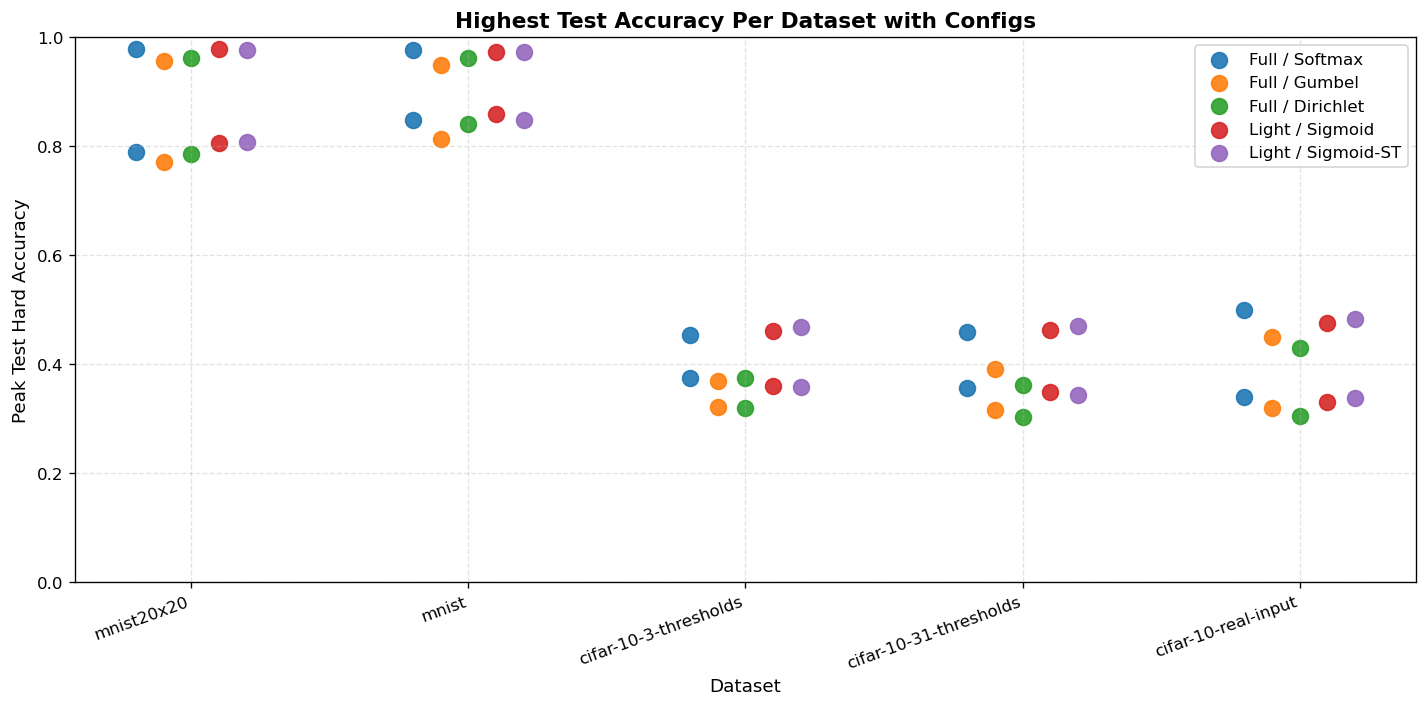

[{'dataset': 'cifar-10-3-thresholds',
  'logic_family': 'full',
  'architecture': 'dirichlet',
  'model_key': ('full', 'dirichlet'),
  'label': 'Full / Dirichlet',
  'peak_test_hard_acc': 0.3738,
  'checkpoint': 'model_checkpoints/cifar-10-3-thresholds__full__dirichlet__L8__N12000__BS1024__steps5000__seed0.pkl'},
 {'dataset': 'cifar-10-3-thresholds',
  'logic_family': 'full',
  'architecture': 'dirichlet',
  'model_key': ('full', 'dirichlet'),
  'label': 'Full / Dirichlet',
  'peak_test_hard_acc': 0.3181,
  'checkpoint': 'model_checkpoints/cifar-10-3-thresholds__full__dirichlet__L8__N800__BS256__steps1000__seed0.pkl'},
 {'dataset': 'cifar-10-3-thresholds',
  'logic_family': 'full',
  'architecture': 'gumbel',
  'model_key': ('full', 'gumbel'),
  'label': 'Full / Gumbel',
  'peak_test_hard_acc': 0.3682,
  'checkpoint': 'model_checkpoints/cifar-10-3-thresholds__full__gumbel__L8__N12000__BS1024__steps5000__seed0.pkl'},
 {'dataset': 'cifar-10-3-thresholds',
  'logic_family': 'full',
  'arc

In [11]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

DATASET_ORDER = [
    "mnist20x20",
    "mnist",
    "cifar-10-3-thresholds",
    "cifar-10-31-thresholds",
    "cifar-10-real-input",
]

MODEL_ORDER = [
    ("full", "softmax"),
    ("full", "gumbel"),
    ("full", "dirichlet"),
    ("light", "light_sigmoid"),
    ("light", "light_st"),
]

MODEL_LABELS = {
    ("full", "softmax"): "Full / Softmax",
    ("full", "gumbel"): "Full / Gumbel",
    ("full", "dirichlet"): "Full / Dirichlet",
    ("light", "light_sigmoid"): "Light / Sigmoid",
    ("light", "light_st"): "Light / Sigmoid-ST",
}

MODEL_COLORS = {
    ("full", "softmax"): "#1f77b4",
    ("full", "gumbel"): "#ff7f0e",
    ("full", "dirichlet"): "#2ca02c",
    ("light", "light_sigmoid"): "#d62728",
    ("light", "light_st"): "#9467bd",
}


def load_checkpoint(path):
    with Path(path).open("rb") as f:
        return pickle.load(f)


def collect_peak_test_acc(checkpoint_dir="model_checkpoints"):
    checkpoint_dir = Path(checkpoint_dir)
    rows = []

    for path in sorted(checkpoint_dir.glob("*.pkl")):
        payload = load_checkpoint(path)
        history = payload["history"]
        config = payload["config"]
        dataset_info = payload["dataset_info"]

        test_hard_acc = [x for x in history["test_hard_acc"] if x is not None]
        if not test_hard_acc:
            continue

        logic_family = str(dataset_info["logic_family"])
        architecture = str(config["architecture"])
        model_key = (logic_family, architecture)

        rows.append({
            "dataset": str(dataset_info["dataset"]),
            "logic_family": logic_family,
            "architecture": architecture,
            "model_key": model_key,
            "label": MODEL_LABELS.get(model_key, f"{logic_family} / {architecture}"),
            "peak_test_hard_acc": float(max(test_hard_acc)),
            "checkpoint": str(path),
        })

    return rows


def plot_peak_test_acc_scatter(checkpoint_dir="model_checkpoints"):
    rows = collect_peak_test_acc(checkpoint_dir)

    fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

    x_positions = np.arange(len(DATASET_ORDER))
    dataset_to_x = {dataset: i for i, dataset in enumerate(DATASET_ORDER)}

    jitter_offsets = {
        ("full", "softmax"): -0.20,
        ("full", "gumbel"): -0.10,
        ("full", "dirichlet"): 0.00,
        ("light", "light_sigmoid"): 0.10,
        ("light", "light_st"): 0.20,
    }

    for model_key in MODEL_ORDER:
        model_rows = [r for r in rows if r["model_key"] == model_key]
        if not model_rows:
            continue

        xs = [dataset_to_x[r["dataset"]] + jitter_offsets[model_key] for r in model_rows]
        ys = [r["peak_test_hard_acc"] for r in model_rows]

        ax.scatter(
            xs,
            ys,
            s=90,
            color=MODEL_COLORS[model_key],
            alpha=0.9,
            label=MODEL_LABELS[model_key],
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(DATASET_ORDER, rotation=20, ha="right")
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("Peak Test Hard Accuracy", fontsize=11)
    ax.set_xlabel("Dataset", fontsize=11)
    ax.set_title("Highest Test Accuracy Per Dataset with Configs", fontsize=13, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()

    return rows

plot_peak_test_acc_scatter()

/tmp/ipykernel_146822/3145925300.py:568: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=(0, 0, 1, 0.95))


saved /home/jared/git_local/Research/JAX_DLGN/checkpoint_plots/gate_histograms_3d__fractional__no_passthrough.png


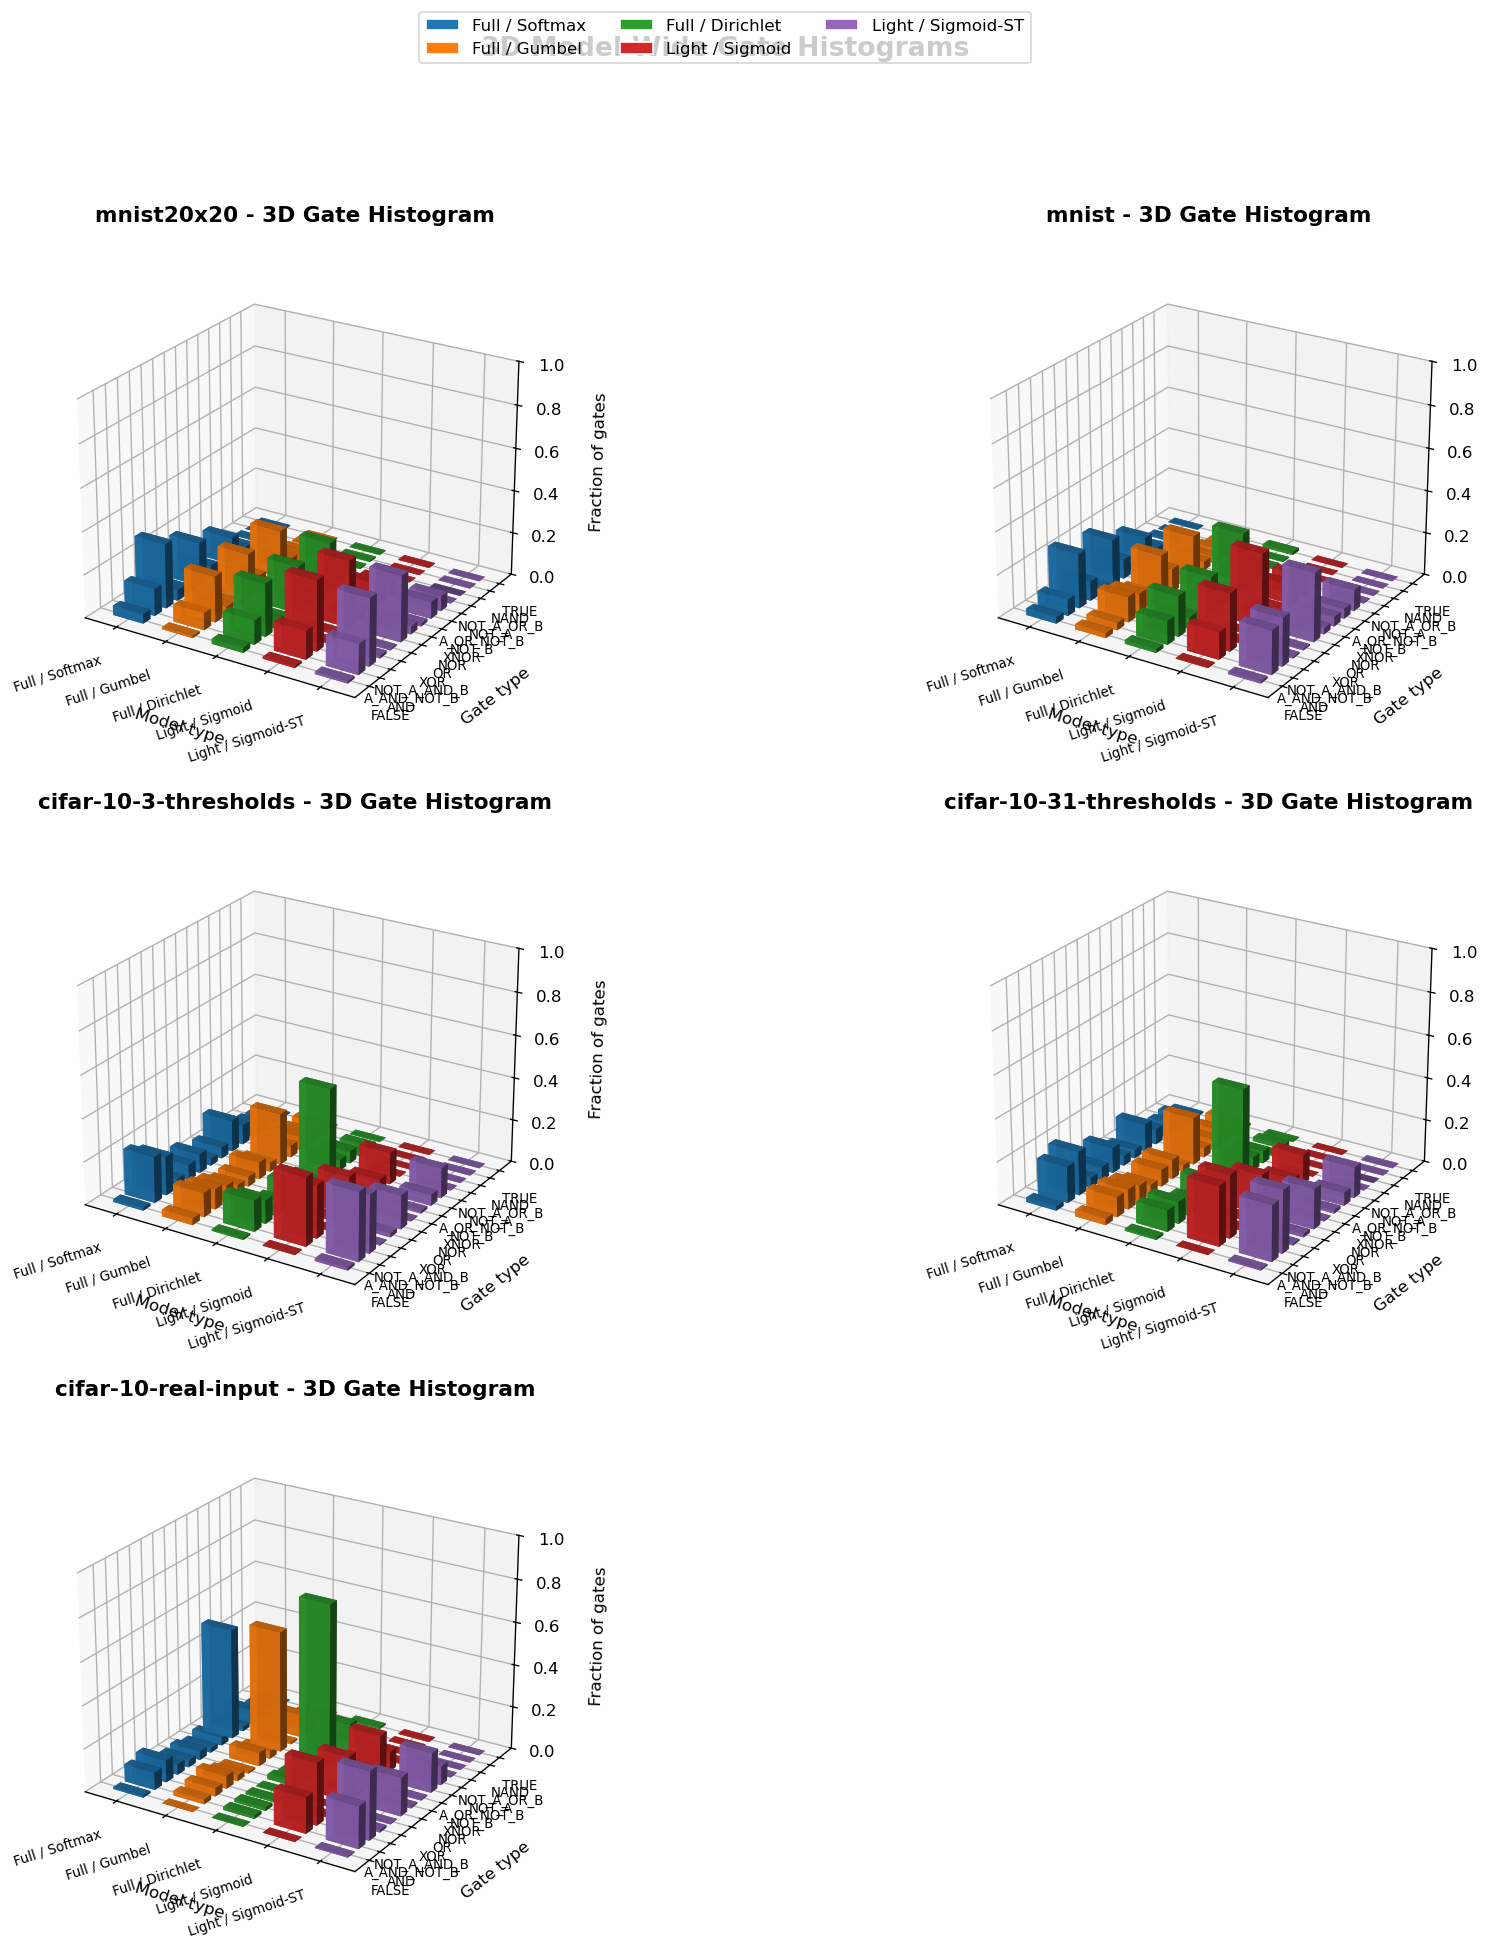

In [12]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import pickle

import numpy as np


DATASET_ORDER = [
    "mnist20x20",
    "mnist",
    "cifar-10-3-thresholds",
    "cifar-10-31-thresholds",
    "cifar-10-real-input",
]

MODEL_ORDER = [
    ("full", "softmax"),
    ("full", "gumbel"),
    ("full", "dirichlet"),
    ("light", "light_sigmoid"),
    ("light", "light_st"),
]

MODEL_LABELS = {
    ("full", "softmax"): "Full / Softmax",
    ("full", "gumbel"): "Full / Gumbel",
    ("full", "dirichlet"): "Full / Dirichlet",
    ("light", "light_sigmoid"): "Light / Sigmoid",
    ("light", "light_st"): "Light / Sigmoid-ST",
}

MODEL_COLORS = {
    ("full", "softmax"): "#1f77b4",
    ("full", "gumbel"): "#ff7f0e",
    ("full", "dirichlet"): "#2ca02c",
    ("light", "light_sigmoid"): "#d62728",
    ("light", "light_st"): "#9467bd",
}

GATE_NAMES = [
    "FALSE",
    "AND",
    "A_AND_NOT_B",
    "A",
    "NOT_A_AND_B",
    "B",
    "XOR",
    "OR",
    "NOR",
    "XNOR",
    "NOT_B",
    "A_OR_NOT_B",
    "NOT_A",
    "NOT_A_OR_B",
    "NAND",
    "TRUE",
]

TRUTH_TABLE_BIT_WEIGHTS = np.asarray([8, 4, 2, 1], dtype=np.int32)


def load_pickle_checkpoint(path: str | Path) -> dict:
    path = Path(path)
    with path.open("rb") as f:
        return pickle.load(f)


def _nan_array(values, length: int) -> np.ndarray:
    arr = np.full(length, np.nan, dtype=float)
    for idx, value in enumerate(values[:length]):
        if value is not None:
            arr[idx] = float(value)
    return arr


def _sample_history_on_eval_grid(payload: dict) -> dict:
    history = payload["history"]
    config = payload["config"]
    dataset_info = payload["dataset_info"]

    steps = list(history["steps"])
    train_soft = list(history["train_soft_loss"])
    train_hard = list(history["train_hard_loss"])
    valid_hard = list(history["valid_hard_acc"])
    test_hard = list(history["test_hard_acc"])

    if not steps:
        raise ValueError("Checkpoint history is empty")

    eval_every = int(config.get("eval_every", 100))
    last_step = int(steps[-1])
    eval_indices = [
        idx
        for idx, step in enumerate(steps)
        if (int(step) % eval_every == 0) or (int(step) == last_step)
    ]

    aligned_len = min(
        len(eval_indices),
        len(valid_hard),
        len(test_hard),
    )
    if aligned_len == 0:
        raise ValueError("Could not align train/eval history for plotting")

    eval_indices = eval_indices[:aligned_len]
    eval_steps = np.asarray([int(steps[idx]) for idx in eval_indices], dtype=int)

    sampled_soft = np.asarray([float(train_soft[idx]) for idx in eval_indices], dtype=float)
    sampled_hard = np.asarray([float(train_hard[idx]) for idx in eval_indices], dtype=float)
    valid_hard = _nan_array(valid_hard, aligned_len)
    test_hard = _nan_array(test_hard, aligned_len)

    logic_family = str(dataset_info["logic_family"])
    architecture = str(config["architecture"])

    return {
        "dataset": str(dataset_info["dataset"]),
        "logic_family": logic_family,
        "architecture": architecture,
        "model_key": (logic_family, architecture),
        "label": MODEL_LABELS.get((logic_family, architecture), f"{logic_family} / {architecture}"),
        "color": MODEL_COLORS.get((logic_family, architecture), None),
        "eval_steps": eval_steps,
        "sampled_train_soft_loss": sampled_soft,
        "sampled_train_hard_loss": sampled_hard,
        "valid_hard_acc": valid_hard,
        "test_hard_acc": test_hard,
        "path": str(payload.get("_source_path", "")),
    }


def collect_runs(checkpoint_dir: str | Path = "model_checkpoints") -> dict[str, list[dict]]:
    checkpoint_dir = Path(checkpoint_dir)
    if not checkpoint_dir.exists():
        raise FileNotFoundError(f"Checkpoint directory does not exist: {checkpoint_dir}")

    runs_by_dataset: dict[str, list[dict]] = defaultdict(list)

    for path in sorted(checkpoint_dir.glob("*.pkl")):
        if path.name == "monkey_patch_sweep_results.jsonl":
            continue

        payload = load_pickle_checkpoint(path)
        payload["_source_path"] = str(path)
        run = _sample_history_on_eval_grid(payload)
        runs_by_dataset[run["dataset"]].append(run)

    for dataset, runs in runs_by_dataset.items():
        runs.sort(key=lambda run: MODEL_ORDER.index(run["model_key"]) if run["model_key"] in MODEL_ORDER else 999)

    return runs_by_dataset


def _sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def _hard_gate_ids_from_layer(layer_params: np.ndarray, logic_family: str) -> np.ndarray:
    layer_params = np.asarray(layer_params)
    if layer_params.ndim != 2:
        raise ValueError(f"Expected rank-2 layer params, got shape {layer_params.shape}")

    if logic_family == "full":
        if layer_params.shape[1] != 16:
            raise ValueError(f"Expected full-gate layer shape (_, 16), got {layer_params.shape}")
        return np.asarray(np.argmax(layer_params, axis=-1), dtype=np.int32)

    if logic_family == "light":
        if layer_params.shape[1] != 4:
            raise ValueError(f"Expected light-gate layer shape (_, 4), got {layer_params.shape}")
        hard_bits = (_sigmoid(layer_params) >= 0.5).astype(np.int32)
        return np.asarray(np.sum(hard_bits * TRUTH_TABLE_BIT_WEIGHTS, axis=-1), dtype=np.int32)

    raise ValueError(f"Unknown logic_family: {logic_family!r}")


def collect_model_wide_gate_counts(
    checkpoint_dir: str | Path = "model_checkpoints",
    exclude_passthrough: bool = False,
) -> dict[str, list[dict]]:
    checkpoint_dir = Path(checkpoint_dir)
    if not checkpoint_dir.exists():
        raise FileNotFoundError(f"Checkpoint directory does not exist: {checkpoint_dir}")

    runs_by_dataset: dict[str, list[dict]] = defaultdict(list)

    for path in sorted(checkpoint_dir.glob("*.pkl")):
        payload = load_pickle_checkpoint(path)
        params = payload.get("params")
        if params is None and "state" in payload:
            params = getattr(payload["state"], "params", None)
        if params is None:
            continue

        dataset_info = payload.get("dataset_info", {})
        config = payload.get("config", {})
        dataset = str(dataset_info.get("dataset", config.get("dataset")))
        logic_family = str(dataset_info.get("logic_family", config.get("logic_family", "full")))
        architecture = str(config.get("architecture", "unknown"))
        model_key = (logic_family, architecture)

        all_gate_ids = []
        for layer_params in params:
            gate_ids = _hard_gate_ids_from_layer(np.asarray(layer_params), logic_family)
            all_gate_ids.append(gate_ids.reshape(-1))

        if not all_gate_ids:
            continue

        flat_gate_ids = np.concatenate(all_gate_ids, axis=0)
        if exclude_passthrough:
            flat_gate_ids = flat_gate_ids[(flat_gate_ids != 3) & (flat_gate_ids != 5)]

        gate_counts = np.bincount(flat_gate_ids, minlength=len(GATE_NAMES)).astype(float)
        total_gates = float(gate_counts.sum())

        runs_by_dataset[dataset].append({
            "dataset": dataset,
            "logic_family": logic_family,
            "architecture": architecture,
            "model_key": model_key,
            "label": MODEL_LABELS.get(model_key, f"{logic_family} / {architecture}"),
            "color": MODEL_COLORS.get(model_key),
            "gate_counts": gate_counts,
            "gate_fractions": np.zeros_like(gate_counts) if total_gates == 0 else gate_counts / total_gates,
            "total_gates": total_gates,
            "path": str(path),
        })

    for dataset, runs in runs_by_dataset.items():
        runs.sort(key=lambda run: MODEL_ORDER.index(run["model_key"]) if run["model_key"] in MODEL_ORDER else 999)

    return runs_by_dataset


def _add_model_and_style_legends(ax, handles_for_models, primary_label: str, secondary_label: str):
    from matplotlib.lines import Line2D

    metric_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label=primary_label),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label=secondary_label),
    ]
    legend_models = ax.legend(
        handles=handles_for_models,
        loc="best",
        fontsize=9,
        frameon=True,
    )
    ax.add_artist(legend_models)
    ax.legend(handles=metric_handles, loc="lower right", fontsize=9, frameon=True)


def plot_dataset_results(dataset: str, runs: list[dict], output_dir: str | Path | None = None):
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=120)
    ax_loss, ax_acc = axes

    model_handles = []
    for run in runs:
        color = run["color"]
        label = run["label"]
        steps = run["eval_steps"]

        ax_loss.plot(
            steps,
            run["sampled_train_soft_loss"],
            color=color,
            linestyle="-",
            linewidth=2.2,
            alpha=0.95,
        )
        ax_loss.plot(
            steps,
            run["sampled_train_hard_loss"],
            color=color,
            linestyle="--",
            linewidth=2.2,
            alpha=0.95,
        )

        ax_acc.plot(
            steps,
            run["valid_hard_acc"],
            color=color,
            linestyle="-",
            linewidth=2.2,
            alpha=0.95,
        )
        ax_acc.plot(
            steps,
            run["test_hard_acc"],
            color=color,
            linestyle="--",
            linewidth=2.2,
            alpha=0.95,
        )

        model_handles.append(Line2D([0], [0], color=color, linewidth=2.5, label=label))

    ax_loss.set_title(f"{dataset} - Losses On Eval Grid", fontsize=13, fontweight="bold")
    ax_loss.set_xlabel("Training Step", fontsize=11)
    ax_loss.set_ylabel("Loss", fontsize=11)
    ax_loss.grid(True, linestyle="--", alpha=0.4)

    ax_acc.set_title(f"{dataset} - Hard Accuracy", fontsize=13, fontweight="bold")
    ax_acc.set_xlabel("Training Step", fontsize=11)
    ax_acc.set_ylabel("Accuracy", fontsize=11)
    ax_acc.set_ylim(0.0, 1.0)
    ax_acc.grid(True, linestyle="--", alpha=0.4)

    _add_model_and_style_legends(
        ax_loss,
        model_handles,
        primary_label="Train soft loss",
        secondary_label="Train hard loss",
    )

    acc_style_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="Validation hard acc"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Test hard acc"),
    ]
    legend_models = ax_acc.legend(
        handles=model_handles,
        loc="best",
        fontsize=9,
        frameon=True,
    )
    ax_acc.add_artist(legend_models)
    ax_acc.legend(handles=acc_style_handles, loc="lower right", fontsize=9, frameon=True)

    fig.suptitle(f"Checkpoint Sweep Comparison: {dataset}", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        out_path = output_dir / f"{dataset.replace('/', '_')}__comparison.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    return fig, axes


def plot_all_datasets(
    checkpoint_dir: str | Path = "model_checkpoints",
    output_dir: str | Path | None = None,
    show: bool = True,
):
    import matplotlib.pyplot as plt

    runs_by_dataset = collect_runs(checkpoint_dir)
    figures = []

    dataset_names = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
    dataset_names.extend(sorted(set(runs_by_dataset) - set(dataset_names)))

    for dataset in dataset_names:
        fig, axes = plot_dataset_results(dataset, runs_by_dataset[dataset], output_dir=output_dir)
        figures.append((dataset, fig, axes))

    if show:
        plt.show()

    return figures, runs_by_dataset


def plot_stacked_gate_histograms(
    checkpoint_dir: str | Path = "model_checkpoints",
    datasets: list[str] | None = None,
    normalize: bool = False,
    exclude_passthrough: bool = False,
    output_dir: str | Path | None = None,
    show: bool = True,
):
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    runs_by_dataset = collect_model_wide_gate_counts(
        checkpoint_dir=checkpoint_dir,
        exclude_passthrough=exclude_passthrough,
    )

    if datasets is None:
        datasets = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
        datasets.extend(sorted(set(runs_by_dataset) - set(datasets)))

    gate_indices = list(range(len(GATE_NAMES)))
    if exclude_passthrough:
        gate_indices = [idx for idx in gate_indices if idx not in (3, 5)]

    n = len(datasets)
    fig, axes = plt.subplots(n, 1, figsize=(13, 4.5 * n), dpi=120, squeeze=False)
    axes = axes[:, 0]

    cmap = plt.get_cmap("tab20")
    gate_colors = {
        gate_idx: cmap(i % 20)
        for i, gate_idx in enumerate(gate_indices)
    }

    for ax, dataset in zip(axes, datasets):
        runs = {run["model_key"]: run for run in runs_by_dataset.get(dataset, [])}
        x = np.arange(len(MODEL_ORDER))

        matrix = np.zeros((len(MODEL_ORDER), len(gate_indices)), dtype=float)
        for model_idx, model_key in enumerate(MODEL_ORDER):
            run = runs.get(model_key)
            if run is None:
                continue
            values = run["gate_fractions"] if normalize else run["gate_counts"]
            matrix[model_idx, :] = values[gate_indices]

        bottom = np.zeros(len(MODEL_ORDER), dtype=float)
        for gate_column, gate_idx in enumerate(gate_indices):
            heights = matrix[:, gate_column]
            ax.bar(
                x,
                heights,
                bottom=bottom,
                width=0.78,
                color=gate_colors[gate_idx],
                edgecolor="white",
                linewidth=0.4,
                label=GATE_NAMES[gate_idx],
            )
            bottom += heights

        ax.set_xticks(x)
        ax.set_xticklabels(
            [MODEL_LABELS[model_key] for model_key in MODEL_ORDER],
            rotation=18,
            ha="right",
        )
        ax.set_title(f"{dataset} - Model-Wide Gate Usage", fontsize=13, fontweight="bold")
        ax.set_ylabel("Fraction of gates" if normalize else "Gate count", fontsize=11)
        ax.grid(True, axis="y", linestyle="--", alpha=0.35)
        if normalize:
            ax.set_ylim(0.0, 1.0)

    legend_handles = [
        Patch(facecolor=gate_colors[gate_idx], edgecolor="white", label=GATE_NAMES[gate_idx])
        for gate_idx in gate_indices
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=4,
        frameon=True,
        bbox_to_anchor=(0.5, 0.995),
    )
    fig.suptitle("Stacked Model-Wide Gate Histograms", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.94))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        suffix = "fractional" if normalize else "counts"
        if exclude_passthrough:
            suffix += "__no_passthrough"
        out_path = output_dir / f"stacked_gate_histograms__{suffix}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    if show:
        plt.show()

    return fig, axes, runs_by_dataset


def plot_3d_gate_histograms(
    checkpoint_dir: str | Path = "model_checkpoints",
    datasets: list[str] | None = None,
    normalize: bool = False,
    exclude_passthrough: bool = False,
    output_dir: str | Path | None = None,
    show: bool = True,
    elev: float = 24.0,
    azim: float = -58.0,
):
    import math
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    runs_by_dataset = collect_model_wide_gate_counts(
        checkpoint_dir=checkpoint_dir,
        exclude_passthrough=exclude_passthrough,
    )

    if datasets is None:
        datasets = [dataset for dataset in DATASET_ORDER if dataset in runs_by_dataset]
        datasets.extend(sorted(set(runs_by_dataset) - set(datasets)))

    gate_indices = list(range(len(GATE_NAMES)))
    if exclude_passthrough:
        gate_indices = [idx for idx in gate_indices if idx not in (3, 5)]

    n = len(datasets)
    ncols = 1 if n == 1 else 2
    nrows = math.ceil(n / ncols)
    fig = plt.figure(figsize=(18, 6 * nrows), dpi=120)

    dx = 0.62
    dy = 0.62

    for subplot_idx, dataset in enumerate(datasets, start=1):
        ax = fig.add_subplot(nrows, ncols, subplot_idx, projection="3d")
        runs = {run["model_key"]: run for run in runs_by_dataset.get(dataset, [])}

        for model_idx, model_key in enumerate(MODEL_ORDER):
            run = runs.get(model_key)
            if run is None:
                continue

            values = run["gate_fractions"] if normalize else run["gate_counts"]
            heights = np.asarray(values[gate_indices], dtype=float)

            x_positions = np.full(len(gate_indices), model_idx, dtype=float)
            y_positions = np.arange(len(gate_indices), dtype=float)
            z_positions = np.zeros(len(gate_indices), dtype=float)

            ax.bar3d(
                x_positions,
                y_positions,
                z_positions,
                dx,
                dy,
                heights,
                color=MODEL_COLORS[model_key],
                alpha=0.88,
                shade=True,
            )

        ax.set_title(f"{dataset} - 3D Gate Histogram", fontsize=13, fontweight="bold", pad=18)
        ax.set_xlabel("Model type", labelpad=10)
        ax.set_ylabel("Gate type", labelpad=12)
        ax.set_zlabel("Fraction of gates" if normalize else "Gate count", labelpad=10)
        ax.set_xticks(np.arange(len(MODEL_ORDER)) + dx / 2)
        ax.set_xticklabels(
            [MODEL_LABELS[model_key] for model_key in MODEL_ORDER],
            rotation=18,
            ha="right",
            fontsize=8,
        )
        ax.set_yticks(np.arange(len(gate_indices)) + dy / 2)
        ax.set_yticklabels([GATE_NAMES[idx] for idx in gate_indices], fontsize=8)
        if normalize:
            ax.set_zlim(0.0, 1.0)
        ax.view_init(elev=elev, azim=azim)

    legend_handles = [
        Patch(facecolor=MODEL_COLORS[model_key], edgecolor="white", label=MODEL_LABELS[model_key])
        for model_key in MODEL_ORDER
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, 0.995),
    )
    fig.suptitle("3D Model-Wide Gate Histograms", fontsize=16, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        suffix = "fractional" if normalize else "counts"
        if exclude_passthrough:
            suffix += "__no_passthrough"
        out_path = output_dir / f"gate_histograms_3d__{suffix}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"saved {out_path.resolve()}")

    if show:
        plt.show()

    return fig, runs_by_dataset


fig, gate_runs = plot_3d_gate_histograms(
    checkpoint_dir="model_checkpoints",
    normalize=True,
    exclude_passthrough=True,
    output_dir="checkpoint_plots",
    show=True,
)

In [76]:
import verilog_generator
import sys


loaded = load_checkpoint("model_checkpoints/cifar-10-real-input__full__dirichlet__L8__N12000__BS1024__steps5000__seed0.pkl")

from pathlib import Path 
checkpoint_dir = Path('model_checkpoints')
    
results = {}
file_names = [p.name for p in checkpoint_dir.iterdir() if p.is_file()]

for name in file_names:
    if name[0:5] == 'mnist' or "steps1000" in name:
        continue
    if name == 'monkey_patch_sweep_results.jsonl':
        continue
    if '10-31' not in name:
        continue
    
    file_path = checkpoint_dir / name
    checkpoint_payload = load_checkpoint(file_path)
    print(name)    
    size_wires = 0
    print(type(checkpoint_payload['wires'][0][0][0]))
    for x in checkpoint_payload['wires']:
        size_wires += sys.getsizeof(x)
        for y in x:
            size_wires += sys.getsizeof(y)
            for z in y:
                size_wires += sys.getsizeof(z)

    size_params = 0
    print(type(checkpoint_payload['params'][0][0][0]))
    for x in checkpoint_payload['params']:
        size_params += sys.getsizeof(x)
        for y in x:
            size_params += sys.getsizeof(y)
            for z in y:
                size_params += sys.getsizeof(z)
                # for a in z:
                #     size_params += sys.getsizeof(a)
    print(size_wires, size_params)
    print(size_wires/(1<<30), size_params/(1<<30))
    # print(len(checkpoint_payload['history']['steps']))
    # print(checkpoint_payload['extra'], "\n")
    # print(checkpoint_payload['extra']['elapsed_seconds'], "\n")
    # print(len(checkpoint_payload['history']['train_soft_loss']))
    # print(len(checkpoint_payload['history']['train_hard_loss']))
    # print(len(checkpoint_payload['history']['valid_hard_acc']), checkpoint_payload['history']['valid_hard_acc'][-2], checkpoint_payload['history']['valid_hard_acc'][-1])
    # print(len(checkpoint_payload['history']['test_hard_acc']), checkpoint_payload['history']['test_hard_acc'][-2], checkpoint_payload['history']['valid_hard_acc'][-1])
    # print(checkpoint_payload['history']['valid_hard_acc'])
    # print(checkpoint_payload['history']['valid_hard_acc'])
    # print(checkpoint_payload['dataset_info'], '\n')

cifar-10-31-thresholds__light__light_st__L8__N12000__BS1024__steps5000__seed0.pkl
<class 'numpy.int32'>
<class 'numpy.float32'>
5378240 21505024
0.005008876323699951 0.020028114318847656
cifar-10-31-thresholds__full__gumbel__L8__N12000__BS1024__steps5000__seed0.pkl
<class 'numpy.int32'>
<class 'numpy.float32'>
5378240 53761024
0.005008876323699951 0.05006885528564453
cifar-10-31-thresholds__light__light_sigmoid__L8__N12000__BS1024__steps5000__seed0.pkl
<class 'numpy.int32'>
<class 'numpy.float32'>
5378240 21505024
0.005008876323699951 0.020028114318847656
cifar-10-31-thresholds__full__dirichlet__L8__N12000__BS1024__steps5000__seed0.pkl
<class 'numpy.int32'>
<class 'numpy.float32'>
5378240 53761024
0.005008876323699951 0.05006885528564453
cifar-10-31-thresholds__full__softmax__L8__N12000__BS1024__steps5000__seed0.pkl
<class 'numpy.int32'>
<class 'numpy.float32'>
5378240 53761024
0.005008876323699951 0.05006885528564453
